In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import plotly.graph_objects as go
import json

In [2]:
from src.datasets.datamodules import DataModule
from src.my_model.transformer import *

In [3]:
publication = False
# if publication:
#     plt.style.use('seaborn-whitegrid')
#     plt.rcParams['font.family'] = 'serif'
#     plt.rcParams['font.serif'] = ['Times New Roman']
#     plt.rcParams['font.size'] = 12
#     plt.rcParams['axes.titlesize'] = 12
#     plt.rcParams['axes.labelsize'] = 12
#     plt.rcParams['xtick.labelsize'] = 12
#     plt.rcParams['ytick.labelsize'] = 12
#     plt.rcParams['legend.fontsize'] = 12
#     plt.rcParams['figure.titlesize'] = 12
#     plt.rcParams['figure.figsize'] = (6, 4)
#     plt.rcParams['lines.linewidth'] = 1.5
#     plt.rcParams['lines.markersize'] = 6
#     plt.rcParams['axes.linewidth'] = 1.5
#     plt.rcParams['legend.frameon'] = False
#     plt.rcParams['legend.handlelength'] = 1.5
#     plt.rcParams['legend.handleheight'] = 0.5
#     plt.rcParams['legend.borderpad'] = 0.5
#     plt.rcParams['legend.borderaxespad'] = 0.5
#     plt.rcParams['legend.labelspacing'] = 0.5
#     plt.rcParams['legend.columnspacing'] = 1.0
#     plt.rcParams['legend.loc'] = 'best'
#     plt.rcParams['legend.framealpha'] = 0.5

In [4]:
config = {
    "min_hits": 3,
    "min_pt": 0.5,
    "max_pt": 10,
    "keep_secondaries": False,
    # "max_abs_eta": 1,
    "max_abs_eta": 3,
    # "max_abs_eta": 4,
}
config["sort_by_radius"] = True
config["cut_scattered"] = True
# config["z_symmetry"] = True

In [5]:
dataset_name = "TrackML_kaggle"
dataset_name = "TrackML_zenodo"
dataset_name = "TrackML_zenodo_full"
dataset_name = "Acts_muons"
if "TrackML" in dataset_name:
    dataset_type = "tml"
elif "Acts" in dataset_name:
    dataset_type = "acts"
if "TrackML" in dataset_name:
    if dataset_name == "TrackML_kaggle":
        dataset_dir = Path("Data/Tml/train_1")
    elif dataset_name == "TrackML_zenodo":
        dataset_dir = Path("Data/TrackML/training_part01")
    else:
        dataset_dir = Path("Data/TrackML/full_dataset")
elif "Acts" in dataset_name:
    if dataset_name == "Acts_muons":
        dataset_dir = Path("Data/Acts/Muons")

In [6]:
if dataset_name == "Acts_muons":
    config = {
        "min_hits": 7,
        "particle_types": [13, -13],
    }
    config["sort_by_radius"] = True
    config["truth_position"] = True

In [7]:
config["input_variables"] = ["tx", "ty", "tz"]
# config["input_variables"] = ["tr", "tphi", "tz"]
config["input_variables"] = ["tr", "dphi", "tz"]
# config["input_variables"] = ["tx", "ty", "tz", "pT_circle_estimate"]


config["output_variables"] = ['pT', 'pz']
config["output_variables"] = ["qopT", "pz"]
# config["output_variables"] = ["qpT", "pz"]

In [8]:
import pandas as pd

# Creating a structured dataframe for the models
model_data = [
    (["tx", "ty", "tz"], "TrackML_kaggle", ['pT', 'pz'], "Models/TrackML/version_155", None, "Models/TrackML/version_154"),
    (["tx", "ty", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_152", "Models/TrackML/version_199", "Models/TrackML/version_153"),
    (["tx", "ty", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_168", "Models/TrackML/version_195", "Models/TrackML/version_192"),
    (["tx", "ty", "tz"], "TrackML_zenodo", ['qpT', 'pz'], "Models/TrackML/version_206", None, "Models/TrackML/version_205"),
    (["tr", "tphi", "tz"], "TrackML_kaggle", ['pT', 'pz'], "Models/TrackML/version_160", None, "Models/TrackML/version_159"),
    (["tr", "tphi", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_162", None, "Models/TrackML/version_161"),
    # (["tr", "tphi", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_162", None, None),
    (["tr", "tphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_191", None, "Models/TrackML/version_177"),
    (["tr", "tphi", "tz"], "TrackML_zenodo", ['qpT', 'pz'], "Models/TrackML/version_203", None, "Models/TrackML/version_201"),
    (["tr", "dphi", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_193", "Models/TrackML/version_198", "Models/TrackML/version_196"),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_169", "Models/TrackML/version_194", "Models/TrackML/version_178"),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_279", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_483", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_492", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_497", None, None), # eta 1
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_487", None, None), # eta 1
    # # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_534", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_652", None, None), # eta 1 # z symmetry
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_533", None, None), # eta 3
    (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_648", None, None), # eta 1 # no z symmetry
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/TrackML/version_533", None, None),
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/TrackML/version_648", None, None), # eta 1 # no z symmetry
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/TrackML/version_652", None, None), # eta 1 # z symmetry
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_5", None, None),
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_4", None, None), # eta 1
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_26", None, None), # eta 3; min 7 hits
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_28", None, None), # eta 3; min 7 hits
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_63", None, None), # eta 3; min 7 hits
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_69", None, None), # eta 3; min 7 hits
    (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/ActsODD/version_72", None, None), # eta 3; min 7 hits
    # (["tr", "dphi", "tz"], "Acts_muons", ['qopT', 'pz'], "Models/TrackML/version_315", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_517", None, None), # eta 4
    # (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_518", None, None), # eta 4
    (["tr", "dphi", "tz"], "TrackML_zenodo", ['qpT', 'pz'], "Models/TrackML/version_204", None, "Models/TrackML/version_202"),
    # (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_249", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_315", None, None),
    # (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_392", None, None), # eta 1
    # (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_432", None, None), # eta 3
    # (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_460", None, None), # eta 1
    (["tr", "dphi", "tz"], "TrackML_zenodo_full", ['qopT', 'pz'], "Models/TrackML/version_533", None, None), # eta 3 # first file
    (["tx", "ty", "tz", "pT_circle_estimate"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_152", "Models/TrackML/version_199", "Models/TrackML/version_153"),
]

# Creating a DataFrame
model_df = pd.DataFrame(
    model_data,
    columns=[
        "input_variables",
        "dataset_name",
        "output_variables",
        "mse_dir",
        "mse_inv_dir",
        "qloss_dir",
    ],
)
model_df["input_variables"] = model_df["input_variables"].apply(tuple)
model_df["output_variables"] = model_df["output_variables"].apply(tuple)

In [9]:
# Function to retrieve available models based on input configuration, dataset name, and DataFrame
def get_available_models(model_df, config_input, dataset_name, config_output):
    config_input = tuple(config_input)
    config_output = tuple(config_output)

    filtered_df = model_df[
        (model_df["input_variables"] == config_input)
        & (model_df["dataset_name"] == dataset_name)
        & (model_df["output_variables"] == config_output)
    ]

    if not filtered_df.empty:
        model_dict = {
            "mse_dir": filtered_df.iloc[0]["mse_dir"],
            "mse_inv_dir": filtered_df.iloc[0]["mse_inv_dir"],
            "qloss_dir": filtered_df.iloc[0]["qloss_dir"],
        }
        return {
            k: v for k, v in model_dict.items() if v is not None
        }  # Remove None values
    else:
        return {}


available_models = get_available_models(
    model_df, config["input_variables"], dataset_name, config["output_variables"]
)
print(available_models)

{'mse_dir': 'Models/ActsODD/version_72'}


In [10]:
models_dir = {
    "MSE": Path(available_models["mse_dir"]),
}
if "qloss_dir" in available_models:
    models_dir["QLoss"] = Path(available_models["qloss_dir"])
if "mse_inv_dir" in available_models:
    models_dir["MSE_inv"] = Path(available_models["mse_inv_dir"])

In [11]:
# Define models. (Assumes that p_pred_mse_list and p_pred_qloss_list are defined externally.)
models = {
    "MSE": {
        "color": "skyblue",
        "cmap": "Blues",
        "label": "MSE",
        "marker": "o",
    },
}
if "QLoss" in models_dir:
    models["QLoss"] = {
        "color": "coral",
        "cmap": "Reds",
        "label": "Quantile Loss",
        "marker": "^",
    }

In [12]:
variable_labels = {
    "tx": r"x_{truth}",
    "ty": r"y_{truth}",
    "tz": r"z_{truth}",
    "tr": r"r_{truth}",
    "tphi": r"\varphi_{truth}",
    "dphi": r"\Delta\varphi",
    "pT": "p_T",
    # "qopT": r"\frac{q}{p_T}",
    "qopT": "q/p_T",
    "qpT": "q*p_T",
    "pz": "p_z",
    "pT_circle_estimate": "p_T (circle estimate)",
}

# variable_filenames is a reverse mapping of variable_labels
variable_filenames = {v: k for k, v in variable_labels.items()}

variable_units = {
    "tx": "mm",
    "ty": "mm",
    "tz": "mm",
    "tr": "mm",
    "tphi": "rad",
    "dphi": "rad",
    "pT": "GeV",
    "qopT": "1/GeV",
    "qpT": "GeV",
    "pz": "GeV",
}

In [13]:
title_suffix = ""

# if publication:
#     title_suffix += r"$\mathrm{(TrackML)}$"
# else:
#     title_suffix += r"$\mathrm{(TrackML , \textit{zenodo})}$"
#     # title_suffix += r"$\mathrm{(Acts)}$"
#     # title_suffix += r"$\mathrm{(Acts \, \textit{zenodo})}$"
#     # title_suffix += r"$\mathrm{(Acts \, \textit{zenodo \, full})}$"

if not publication:
    # Add input and output variables to the title suffix
    title_suffix += (
        f" ((${'$, $'.join([variable_labels[var] for var in config['input_variables']])}$)"
    )
    title_suffix += r" $ \to $ "
    title_suffix += (
        f"(${'$, $'.join([variable_labels[var] for var in config['output_variables']])}$))"
    )

In [14]:
output_dir = Path("Results/TrackML/")
if dataset_type == "acts" or True:
    output_dir = Path("Results/ActsODD/")

input_variables = "".join(config["input_variables"]).replace("t", "")

output_variables = "_".join(config["output_variables"])

experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_{dataset_name}"
# experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_{dataset_name}_full_dataset"
# experiment_name += "_batch_size_2048"
# experiment_name += "_eta_4"
experiment_name += "_eta_3"
# experiment_name += "_trained_eta_1"
# experiment_name += "_trained_eta_3"
# experiment_name += "_trained_TrackML"
# experiment_name += "_trained_TrackML_first"
# experiment_name += "_z_symmetry"
experiment_name += "_trained_ODD_full"
# experiment_name += "_e_32_h_8"
experiment_name += "_e_128_h_2"
# experiment_name += "_trained_7_hits"
# experiment_name += "_huber"
# experiment_name += "_huber_resolution_e_32_h_2"
# experiment_name += "_huber_resolution_huber_e_32_h_2"
# experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_no_scat_{dataset_name}_e_128_h_2_no_droupout"

output_dir = output_dir / experiment_name

# Create the output directory if it does not exist
output_dir.mkdir(exist_ok=True, parents=True)

In [15]:
# Instantiate the DataModule num_workers=16)
# dataset_wrapper = DataModule(dataset_type="tml", dataset_dir="Data/Tml/trackml_100_events_splits") # 20 000 particles
dataset_wrapper = DataModule(
    dataset_type=dataset_type,
    dataset_dir=dataset_dir,
    use_wrapper=False,
    kwargs=config,
)  # 1 404 273 particles

dataset_wrapper.setup(stage="test")
tl = dataset_wrapper.test_dataloader()
# 1 min 41.4 s

────────────────────────────────────────────────── Acts Dataset ───────────────────────────────────────────────────

In [16]:
from src.analysis.utils import (
    get_model_checkpoint_path,
    get_config,
    validate_model_config,
    var_to_pT,
    compute_likelyhood,
    compute_track_resolution,
    get_smallest_confidence_interval,
)

In [17]:
mse_config = get_config(models_dir["MSE"])
validate_model_config(mse_config, config, dataset_dir=dataset_dir, criterion="mse", allow_other_datasets=dataset_name == "TrackML_zenodo_full")
if "QLoss" in models_dir:
    qloss_config = get_config(models_dir["QLoss"])
    validate_model_config(
        qloss_config, config, dataset_dir=dataset_dir, criterion="qloss-0.5"
    )

AssertionError: Dataset dir is ../../actsODD/loading_profiling_output/ instead of Data/Acts/Muons

In [18]:
# Load models
for model in models_dir:
    if model not in models:
        print(f"Skipping {model} model (not defined in models)")
        continue
    print(f"Loading {model} model")
    ml_model_path = get_model_checkpoint_path(models_dir[model])[0]
    # _instantiator is a function that is called to instantiate the model
    # Here the models have been trained using cli raising an error if _instantiator is not None
    ml_model = TrackFormer.load_from_checkpoint(
        checkpoint_path=ml_model_path, _instantiator=None, metric="sign",
    )
    ml_model.eval().to("cpu")
    ml_model_ = torch.load(ml_model_path, map_location="cpu")
    print(list(ml_model_['callbacks'].values())[0])

    # ml_model_ = torch.load(Path("/".join(str(ml_model_path).split("/")[:-1]) + "/last-v1.ckpt"), map_location="cpu")
    # print(list(ml_model_['callbacks'].values())[0])
    # print(ml_model_)
    models[model]["model"] = ml_model

Loading MSE model
Found 1 checkpoints in Models/ActsODD/version_72/checkpoints
{'monitor': 'val_loss', 'best_model_score': tensor(0.0199), 'best_model_path': 'Models/ActsODD/lightning_logs/version_72/checkpoints/model-epoch=989-val_loss=1.992e-02.ckpt', 'current_score': tensor(0.0199), 'dirpath': 'Models/ActsODD/lightning_logs/version_72/checkpoints', 'best_k_models': {'Models/ActsODD/lightning_logs/version_72/checkpoints/model-epoch=989-val_loss=1.992e-02.ckpt': tensor(0.0199)}, 'kth_best_model_path': 'Models/ActsODD/lightning_logs/version_72/checkpoints/model-epoch=989-val_loss=1.992e-02.ckpt', 'kth_value': tensor(0.0199), 'last_model_path': 'Models/ActsODD/lightning_logs/version_72/checkpoints/last.ckpt'}


/tmp/ipykernel_82808/2478400923.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ml_model_ = torch.load(ml_model_path, map_location="cpu")


In [19]:
# Full dataset test: 17 min 09 s (23 804 batches)
# Full dataset eta 4 test: 52 min 34 s (85 627 batches)
# Full dataset eta 3 test: > 30 min 34 s (> 21 000 batches)
p_true_list = []
n_hits_list = []
input_list = []

bad_tracks_q = []
bad_tracks_mse = []
bad_tracks_mse_pT = []
bad_tracks_mse_pT_sign = []
worst_tracks_mse_pT = []

abs_relative_error_model_max = {model: 0 for model in models}
abs_relative_error_model_max_pT = {model: 0 for model in models}

for model in models:
    models[model]["data_list"] = []

with torch.no_grad():
    for i, (input, mask, target) in enumerate(tqdm(tl)):
        if dataset_name == "Acts_muons" and i > 7000:
            break

        # Transformers
        p_true = target
        p_true_list.extend(p_true.tolist())
        n_hits_list.extend(mask.sum(dim=1).tolist())
        input_list.extend(input.tolist())

        for model in models:
            ml_model = models[model]["model"]
            p_pred_model = ml_model(input, mask=mask)
            models[model]["data_list"].extend(p_pred_model.tolist())

            error_model = p_pred_model - p_true
            relative_error_model = error_model / p_true
            abs_relative_error_model = np.abs(relative_error_model)

            # print(ml_model.metric(p_pred_model, p_true))

            if model != "MSE":
                continue

            if (abs_relative_error_model > 10).any():
                mask_ = (abs_relative_error_model > 10).any(axis=1)
                selected = input[mask_][0]

                relative_error_values = relative_error_model[mask_].tolist()
                p_values = p_true[mask_].tolist()
                bad_tracks_mse.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

            # Do only for pT
            # if config["output_variables"][0] != "pT":
            #     continue

            abs_relative_error_model_max[model] = max(abs_relative_error_model[:, 0].max(), abs_relative_error_model_max[model])

            if abs_relative_error_model[:, 0].max() == abs_relative_error_model_max[model]:
                mask_ = abs_relative_error_model[:, 0] == abs_relative_error_model_max[model]
                selected = input[mask_][0]

                relative_error_values = relative_error_model[mask_].tolist()
                p_values = p_true[mask_].tolist()
                worst_tracks_mse_pT.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

            if abs_relative_error_model[:, 0].max() > 1:
                mask_ = abs_relative_error_model[:, 0] > 1
                selected = input[mask_][0]

                relative_error_values = relative_error_model[mask_].tolist()
                p_values = p_true[mask_].tolist()
                bad_tracks_mse_pT.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

            if (np.sign(p_pred_model[:, 0]) != np.sign(p_true[:, 0])).any():
                mask_ = np.sign(p_pred_model[:, 0]) != np.sign(p_true[:, 0])
                selected = input[mask_][0]

                relative_error_values = relative_error_model[mask_].tolist()
                p_values = p_true[mask_].tolist()
                bad_tracks_mse_pT_sign.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

0it [00:00, ?it/s]

In [20]:
if 'pT_circle_estimate' in config["input_variables"]:
    from src.my_model.benchmarks import CircleFit

    p_true_list = []
    n_hits_list = []

    bad_tracks_q = []
    bad_tracks_mse = []
    bad_tracks_mse_pT = []
    bad_tracks_mse_pT_sign = []

    circle_pt_list = []

    abs_relative_error_model_max = {model: 0 for model in models}
    abs_relative_error_model_max_pT = {model: 0 for model in models}

    for model in models:
        models[model]["data_list"] = []

    with torch.no_grad():
        for i, (input, mask, target) in enumerate(tqdm(tl)):

            # Transformers
            p_true = target
            p_true_list.extend(p_true.tolist())
            n_hits_list.extend(mask.sum(dim=1).tolist())

            # PT estimate is the last variable of the input
            pt_estimate = input[:, :, -1]
            input = input[:, :, :-1]
            # print(f"{input.shape = }")
            # print(f"{pt_estimate.shape = }")
            # pt_estimate = input[:, -1]
            # input = torch.tensor(input[:, :-1], dtype=torch.float32)

            for model in models:
                ml_model = models[model]["model"]
                p_pred_model = ml_model(input, mask=mask)
                models[model]["data_list"].extend(p_pred_model.tolist())

                error_model = p_pred_model - p_true
                relative_error_model = error_model / p_true
                abs_relative_error_model = np.abs(relative_error_model)

                # print(ml_model.metric(p_pred_model, p_true))

                if model != "MSE":
                    continue

                if (abs_relative_error_model > 10).any():
                    mask_ = (abs_relative_error_model > 10).any(axis=1)
                    selected = input[mask_][0]

                    relative_error_values = relative_error_model[mask_].tolist()
                    p_values = p_true[mask_].tolist()
                    bad_tracks_mse.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

                # Do only for pT
                # if config["output_variables"][0] != "pT":
                #     continue

                abs_relative_error_model_max[model] = max(abs_relative_error_model[:, 0].max(), abs_relative_error_model_max[model])

                if abs_relative_error_model[:, 0].max() > 1:
                    mask_ = abs_relative_error_model[:, 0] > 1
                    selected = input[mask_][0]

                    relative_error_values = relative_error_model[mask_].tolist()
                    p_values = p_true[mask_].tolist()
                    bad_tracks_mse_pT.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

                if (np.sign(p_pred_model[:, 0]) != np.sign(p_true[:, 0])).any():
                    mask_ = np.sign(p_pred_model[:, 0]) != np.sign(p_true[:, 0])
                    selected = input[mask_][0]

                    relative_error_values = relative_error_model[mask_].tolist()
                    p_values = p_true[mask_].tolist()
                    bad_tracks_mse_pT_sign.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))
            cf = CircleFit()
            print("second fit")
            # print(input)
            # print(input.shape)
            # print(input.dim())
            # Remove the masked points
            points = []
            for particle_index, particle in enumerate(input):
                particle_hit_mask = mask[particle_index]
                valid_particle_hits = particle[particle_hit_mask]
                points.append(valid_particle_hits)
                # points.append([hit for hit_index, hit in enumerate(particle) if mask[particle_index, hit_index]])


            # points = input
            r = cf.fit(points).tolist()
            pt_fit = np.array(r) * 1.0 * 2 * 299_792_458 / 1e9 / 1000
            pt_fit = pt_fit.tolist()
            circle_pt_list.extend(pt_fit)

            print(pt_estimate.tolist())
            print(pt_fit)





    # f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true{}"
    # f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true"
    # print(f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true")
    # print(cf.fit(thing.unsqueeze(0)))
    # print(cf.params)

In [21]:
# Skip the cell if not relevant:
if 'pT_circle_estimate' in config["input_variables"]:
    p_t_true = 1/np.abs(np.array(p_true_list)[:, 0])
    p_t_true = np.array(p_true_list)[:, 0]
    x = (np.array(circle_pt_list)-p_t_true)/p_t_true * 100
    symlog_bins = np.logspace(np.min(np.log10(np.abs(x))), np.max(np.log10(np.abs(x))), 100)
    symlog_bins = np.concatenate((-symlog_bins[::-1], [0], symlog_bins))
    plt.hist(x, bins=symlog_bins)
    # plt.hist(, bins=
    # print((np.array(circle_pt_list)-p_t_true)/p_t_true * 100)
    plt.xscale("symlog")
    plt.show()
    print(f"{np.mean(np.abs(x)) = }")
    print(f"{np.std(np.abs(x)) = }")
    print(f"{np.mean(x) = }")
    print(f"{np.std(x) = }")
    print(f"{np.median(x) = }")
    print(f"{np.min(np.abs(x)) = }")
    print(f"{np.max(np.abs(x)) = }")

In [22]:
# plot the CDF of the relative error
if 'pT_circle_estimate' in config["input_variables"]:
    x = np.sort(np.abs(x))
    y = np.arange(len(x)) / len(x)
    plt.plot(x, y)
    plt.xscale("log")
    plt.grid()
    # Add Y ticks for every 0.1
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.show()

In [23]:
print("Max relative error for pT")
for model in models:
    print(f"{model}: {abs_relative_error_model_max[model]}")

Max relative error for pT
MSE: 0.8549140095710754


In [24]:
import torch

def test_permutation_invariance(model, input_tensor, mask):

    max_difference_ = 0
    with torch.no_grad():
        for i, (input, mask, target) in enumerate(tqdm(tl)):
            # Get the original prediction
            original_prediction = model(input, mask=mask)

            # Shuffle the hits in the input tensor
            shuffled_input_tensor = input.clone()
            shuffled_mask = mask.clone()
            for i in range(shuffled_input_tensor.size(0)):
                # Set a shuffle variable to shuffle the hits
                shuffle_variable = torch.randperm(shuffled_input_tensor.size(1))
                shuffled_input_tensor[i] = shuffled_input_tensor[i][shuffle_variable]
                shuffled_mask[i] = mask[i][shuffle_variable]

            # Get the prediction after shuffling
            shuffled_prediction = model(shuffled_input_tensor, mask=shuffled_mask)

            # Compare the original and shuffled predictions
            difference = torch.abs(original_prediction - shuffled_prediction)
            max_difference = torch.max(difference).item()
            if max_difference > max_difference_:
                max_difference_ = max_difference

    print(f"Max difference between original and shuffled predictions: {max_difference_}")

    return max_difference_

# # Test the permutation invariance for the MSE model
# max_diff_mse = test_permutation_invariance(models["MSE"]["model"], input, mask)
# print(f"Max difference for MSE model: {max_diff_mse}")

# # Test the permutation invariance for the QLoss model
# if "QLoss" in models:
#     max_diff_qloss = test_permutation_invariance(models["QLoss"]["model"], input, mask)
#     print(f"Max difference for QLoss model: {max_diff_qloss}")

In [25]:
import torch

def test_variable_permutation_invariance(model):

    max_difference_ = 0
    with torch.no_grad():
        for i, (input, mask, target) in enumerate(tqdm(tl)):
            # Get the original prediction
            original_prediction = model(input, mask=mask)

            # Shuffle the hit variables in the input tensor
            shuffled_input_tensor = input.clone()
            for i in range(shuffled_input_tensor.size(0)):
                # Set a shuffle variable to shuffle the hit variables
                shuffle_variable = torch.randperm(shuffled_input_tensor.size(2))
                shuffled_input_tensor[i] = shuffled_input_tensor[i][:, shuffle_variable]

            # Get the prediction after shuffling
            shuffled_prediction = model(shuffled_input_tensor, mask=mask)

            # Compare the original and shuffled predictions
            difference = torch.abs(original_prediction - shuffled_prediction)
            max_difference = torch.max(difference).item()
            if max_difference > max_difference_:
                max_difference_ = max_difference

    print(f"Max difference between original and shuffled predictions: {max_difference_}")

    return max_difference_

# # Test the permutation invariance for the MSE model
# max_diff_mse = test_variable_permutation_invariance(models["MSE"]["model"])
# print(f"Max difference for MSE model: {max_diff_mse}")

# # Test the permutation invariance for the QLoss model
# if "QLoss" in models:
#     max_diff_qloss = test_permutation_invariance(models["QLoss"]["model"], input, mask)
#     print(f"Max difference for QLoss model: {max_diff_qloss}")

In [26]:
import numpy as np
from src.analysis.visualization import (
    view_trajectory,
    sync_plot_limits,
)

In [27]:
i = 3 # 3
print(bad_tracks_mse_pT[i][:][0])
view_trajectory(bad_tracks_mse_pT[i][1])

IndexError: list index out of range

In [28]:
i = -1
print(len(bad_tracks_mse_pT_sign))
print(bad_tracks_mse_pT_sign[i][:][0])
view_trajectory(bad_tracks_mse_pT_sign[i][1])

0


IndexError: list index out of range

In [29]:
for i in range(len(bad_tracks_mse_pT_sign)):
    # print(bad_tracks_mse_pT_sign[i][:][0][1])
    print(1/bad_tracks_mse_pT_sign[i][:][0][1][0], (bad_tracks_mse_pT_sign[i][:][1].sum(axis=1) != 0).sum())

In [31]:
i = 5
print(bad_tracks_mse[i][:][0])
view_trajectory(bad_tracks_mse[i][1])

([-0.03425264358520508, 10.632267951965332], [1.0, 0.0037329362239688635])


In [32]:
thing = bad_tracks_mse[i][1][(bad_tracks_mse[i][1] != 0).any(dim=1)][:, :2]

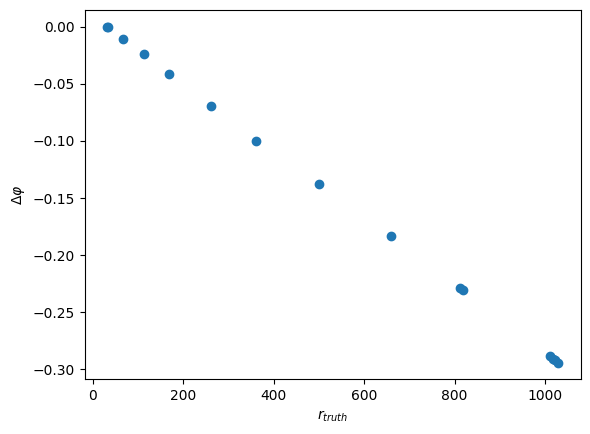

In [33]:
plt.scatter(thing[:, 0], thing[:, 1])
plt.xlabel(f"${variable_labels[config['input_variables'][0]]}$")
plt.ylabel(f"${variable_labels[config['input_variables'][1]]}$")
plt.show()

In [34]:
from src.my_model.benchmarks import CircleFit


cf = CircleFit()


# f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true{}"
# f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true"
print(f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true")
print(f"true: {1/bad_tracks_mse[i][:][0][1][0]}")
print(cf.fit(thing.unsqueeze(0)))
print(cf.params)

circle pred: 1912855.141 	 true
true: 1.0
tensor([1912855.1410], dtype=torch.float64)
[array([ 2.44251364e+00, -1.91285518e+06,  1.91285514e+06])]


/home/couthures/Bureau/TrackParameters/TrackFormer/src/my_model/benchmarks.py:51: UserWarning:

Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1729111943459/work/torch/csrc/utils/tensor_new.cpp:278.)



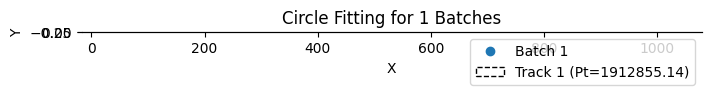

In [35]:
cf.plot()

In [36]:
bad_tracks_mse[i][0][1]

[1.0, 0.0037329362239688635]

In [37]:
# Reload the module
from importlib import reload
import src.analysis.visualization as visualization
reload(visualization)
from src.analysis.visualization import (
    plot_err_vs_n_hits,
    plot_pi_true_vs_pred,
    plot_pi_error_distributions,
    plot_pi_rel_resolutions,
    plot_2d_histogram,
    plot_pi_relative_error_distributions,
    plot_pi_error_distributions_p,
    plot_pi_relative_error_distributions_low_pt_1_2,
    plot_binned_confusion_matrix,
    plot_confusion_probability_matrix,
)

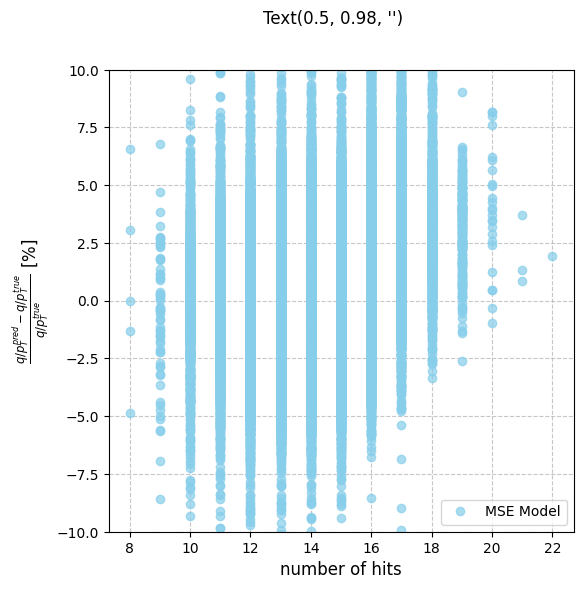

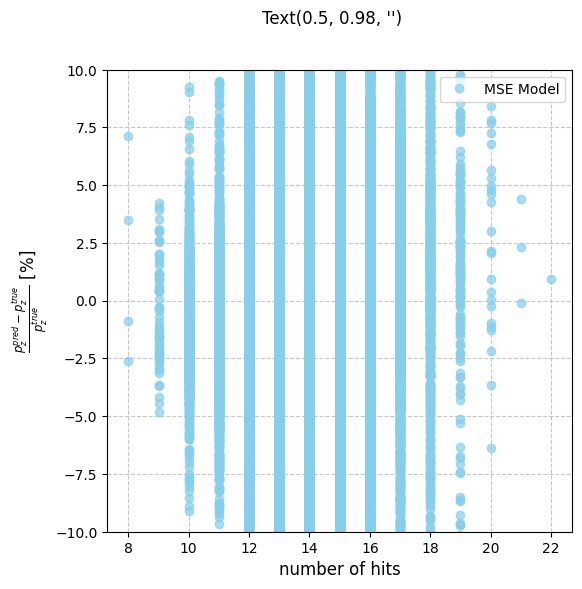

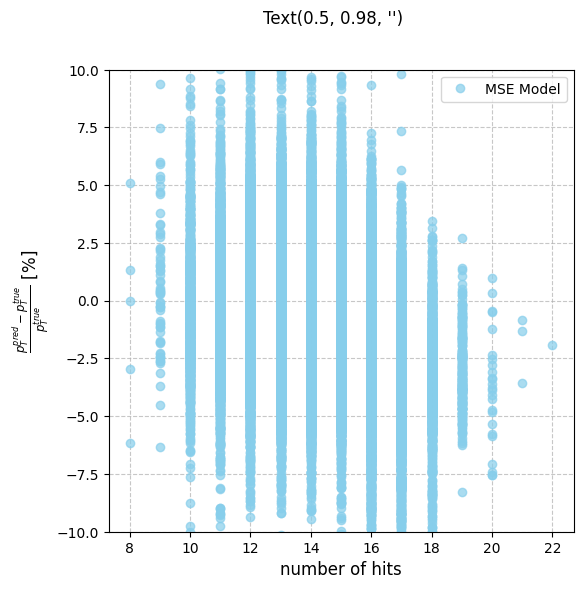

In [38]:
plot_err_vs_n_hits(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    n_hits_list=n_hits_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    # variable_labels,
    low_pt=False,
    publication=publication,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_err_vs_n_hits(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        n_hits_list=n_hits_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        publication=publication,
    )

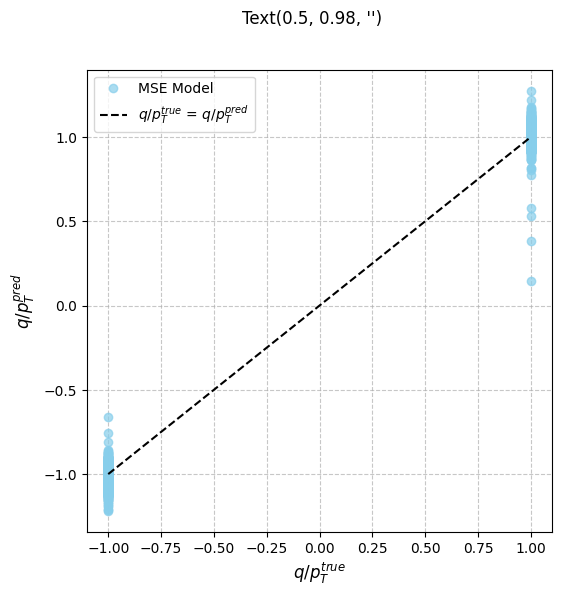

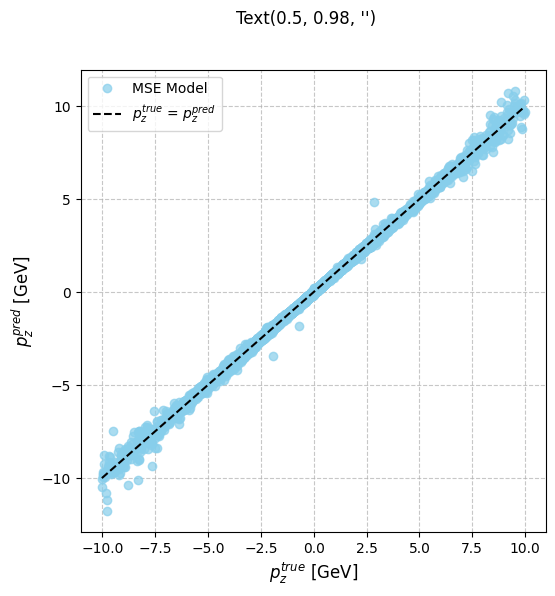

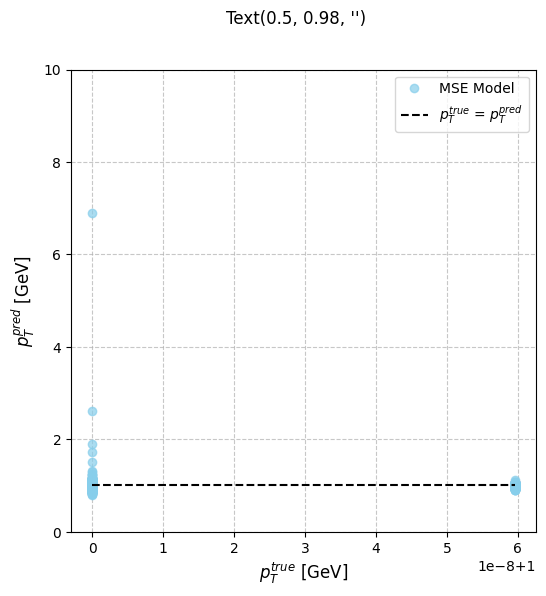

In [39]:
plot_pi_true_vs_pred(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    publication=publication,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_true_vs_pred(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        publication=publication,
    )

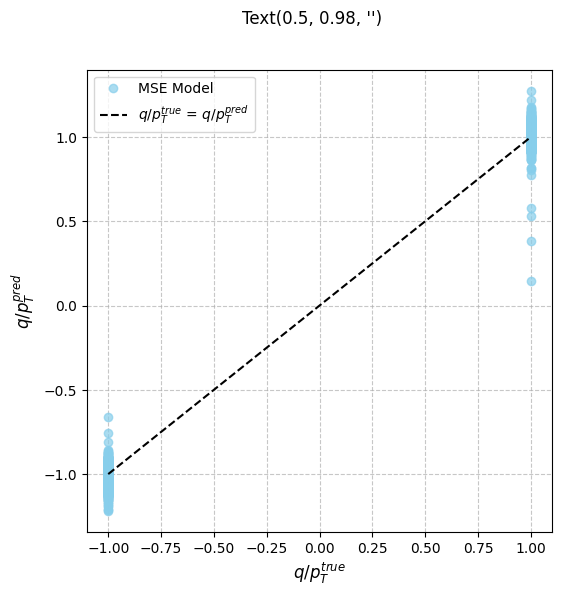

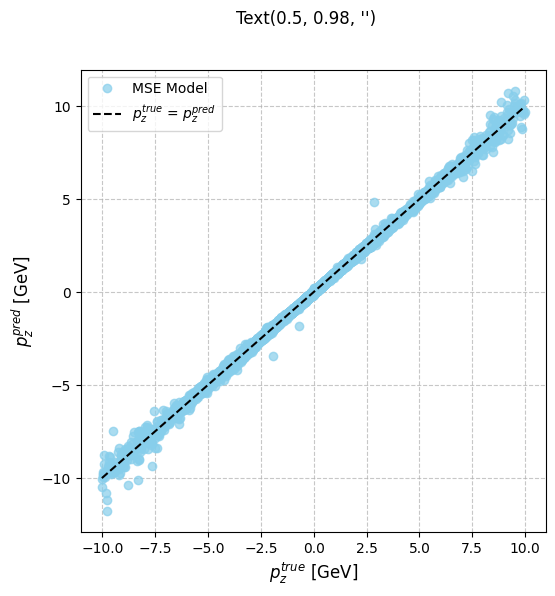

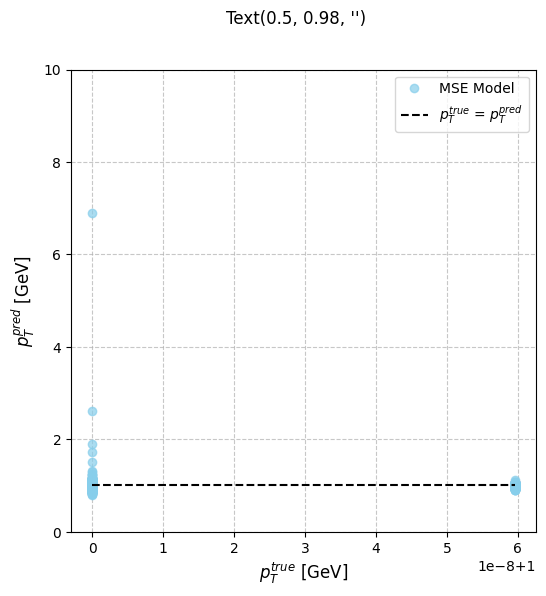

In [40]:
plot_pi_true_vs_pred(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    low_pt=True,
    publication=publication,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_true_vs_pred(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        low_pt=True,
        publication=publication,
    )

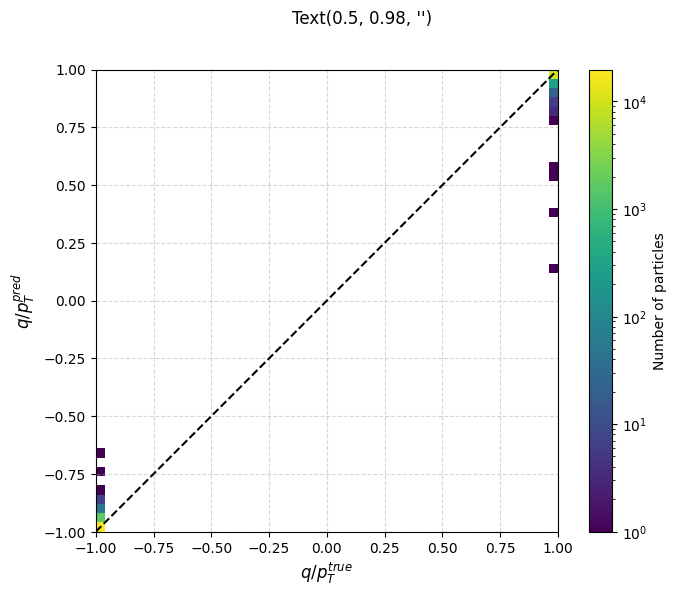

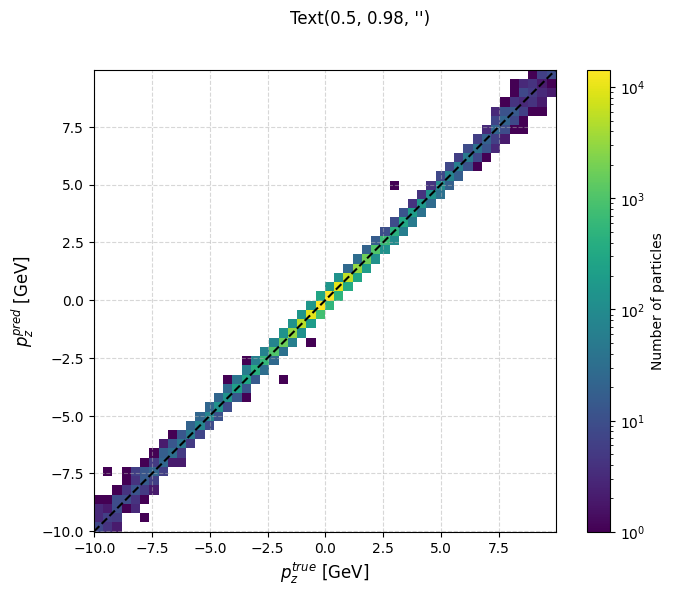

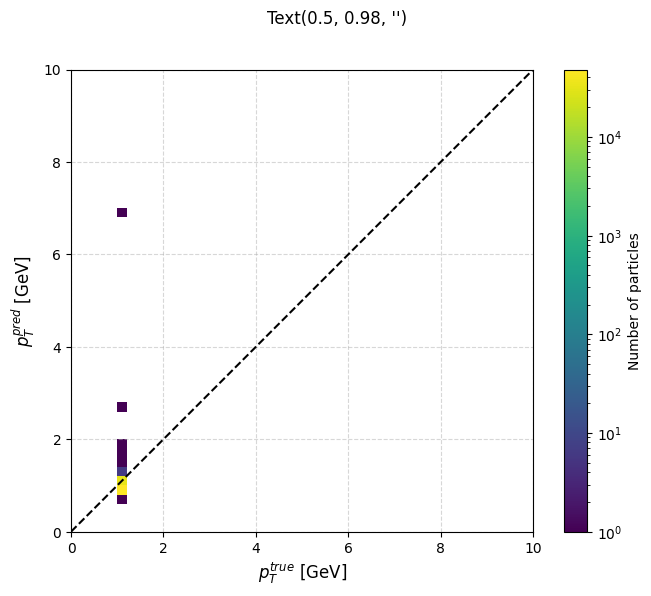

In [41]:
plot_binned_confusion_matrix(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    bins=50,
    log_density=True,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    publication=publication,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_binned_confusion_matrix(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        bins=50,
        log_density=True,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        publication=publication,
    )

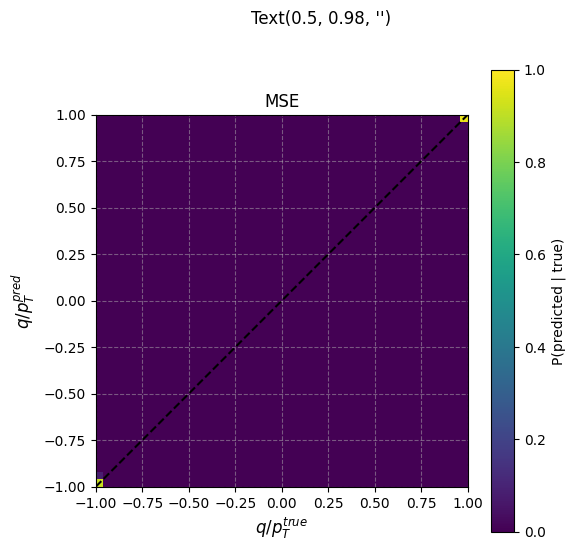

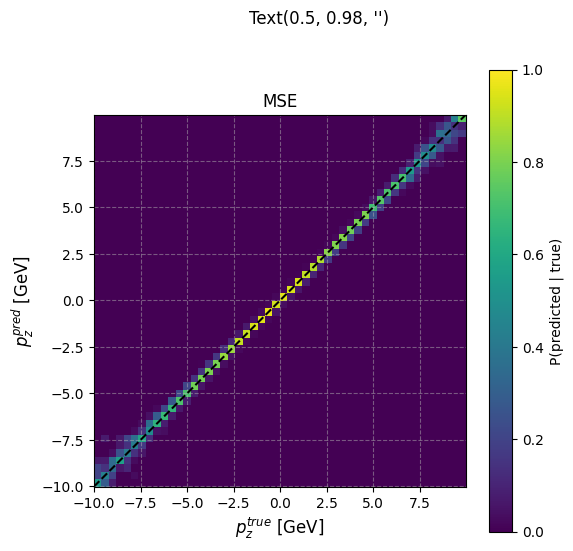

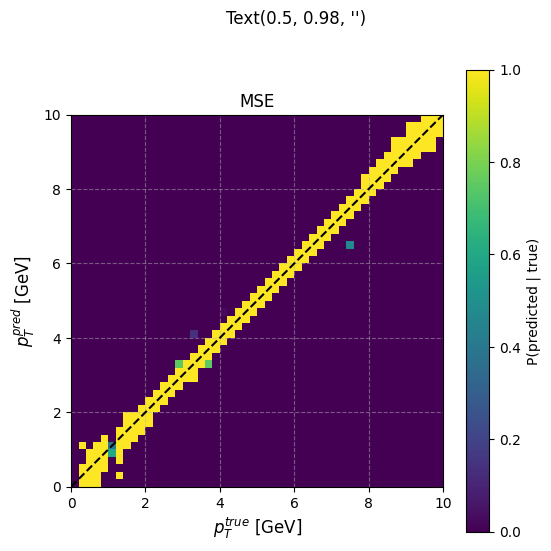

In [42]:
plot_confusion_probability_matrix(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    bins=50,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    publication=publication,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_confusion_probability_matrix(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        bins=50,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        publication=publication,
    )

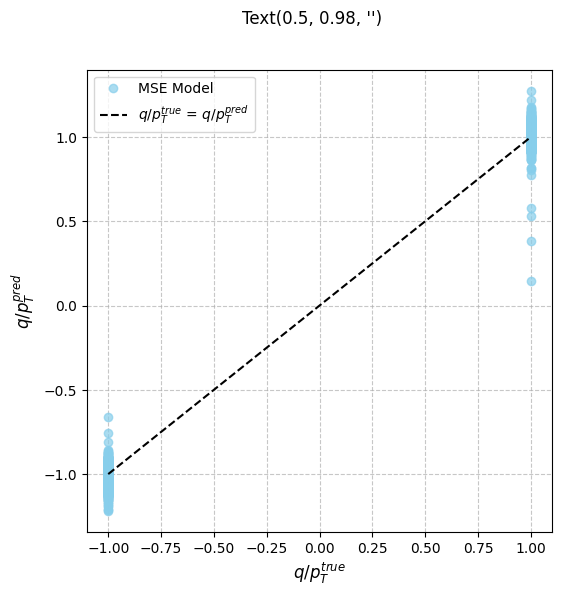

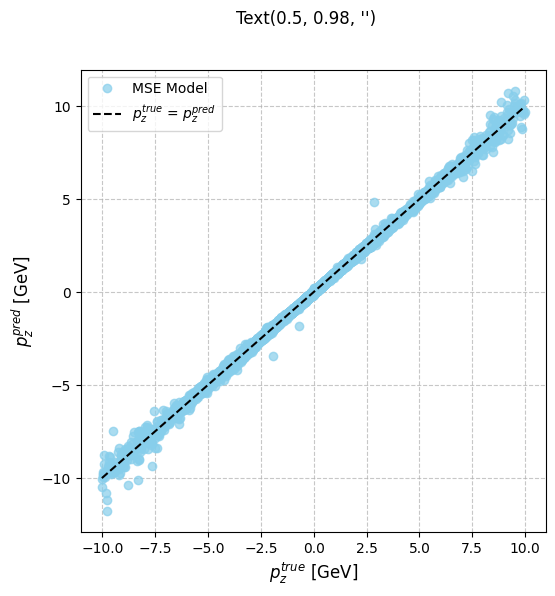

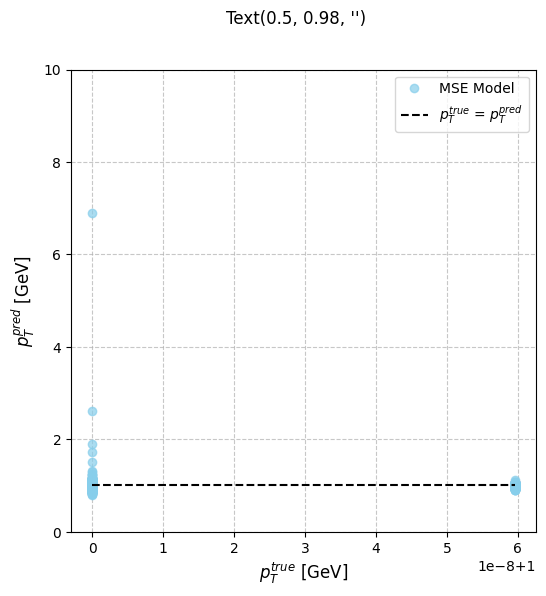

In [43]:
plot_pi_true_vs_pred(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    low_pt=True,
    publication=publication,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_true_vs_pred(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        low_pt=True,
        publication=publication,
    )

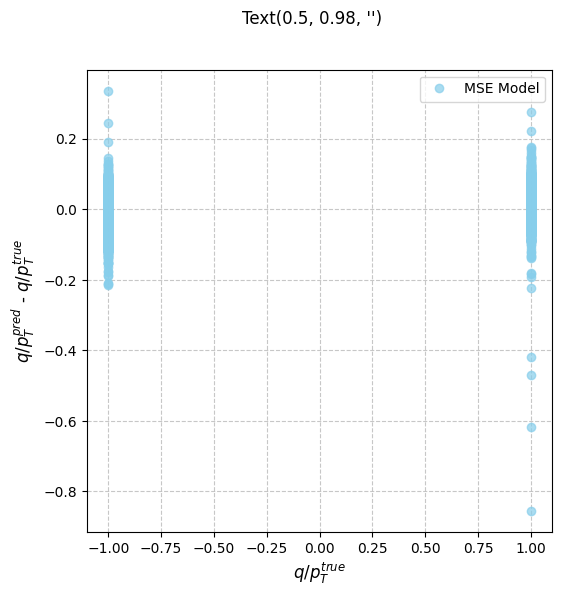

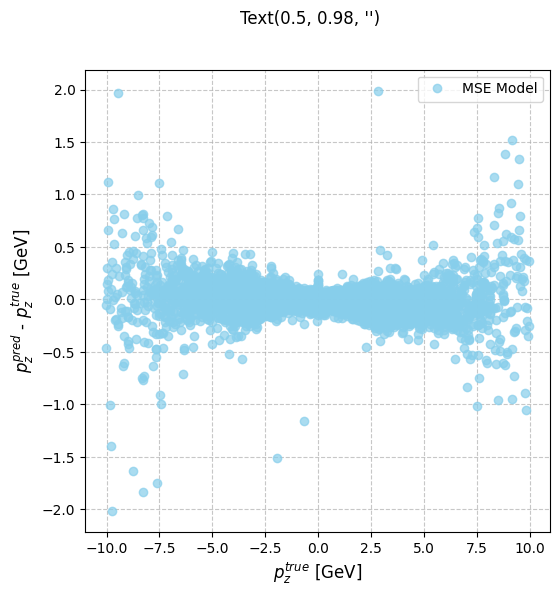

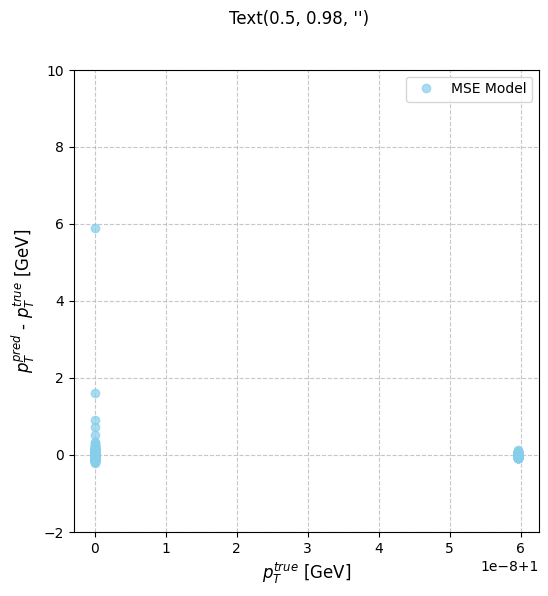

In [44]:
plot_pi_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    publication=publication,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_error_distributions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        publication=publication,
    )

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:

Mean of empty slice.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning:

invalid value encountered in scalar divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning:

Degrees of freedom <= 0 for slice

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning:

invalid value encountered in divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning:

invalid value encountered in scalar divide



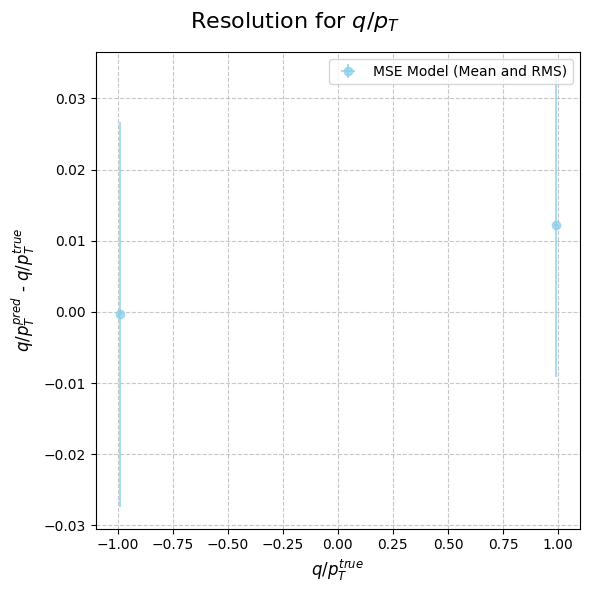

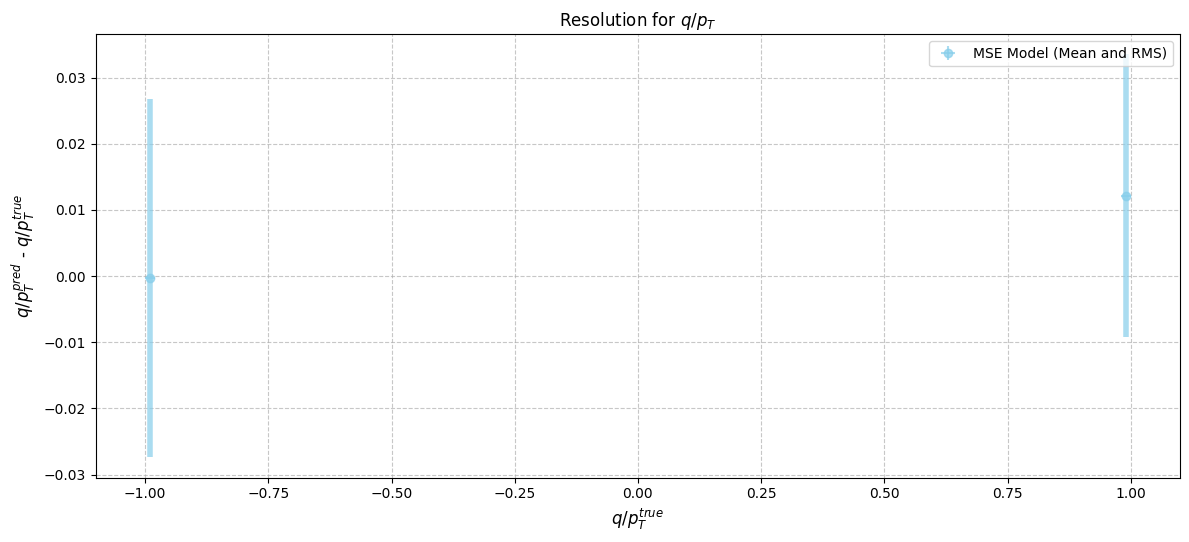

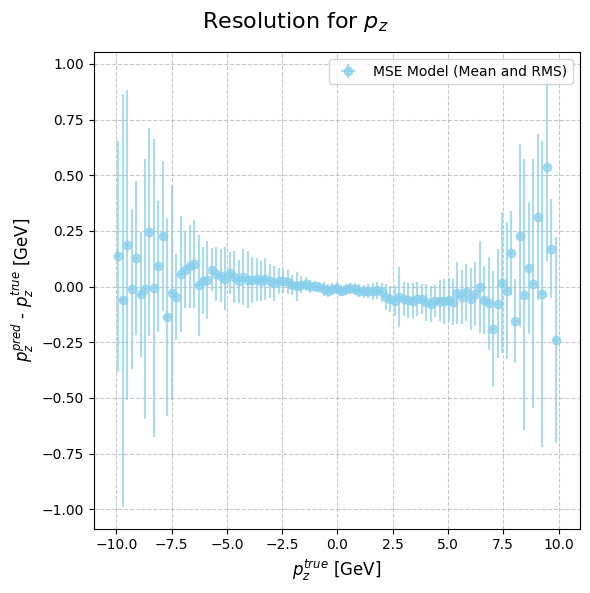

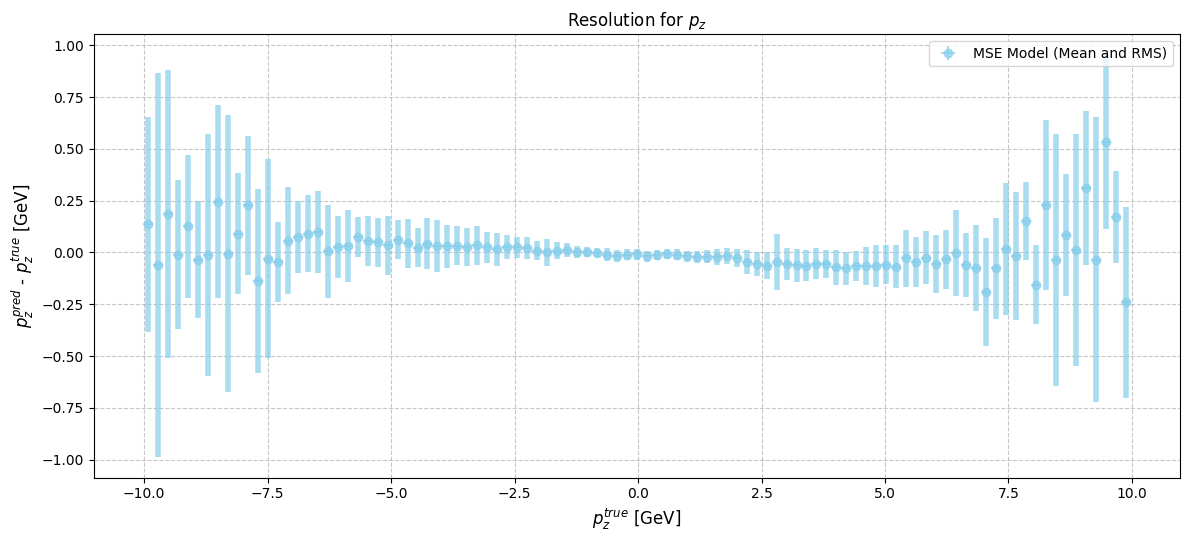

[ 0  1  2  4  6  8 10]


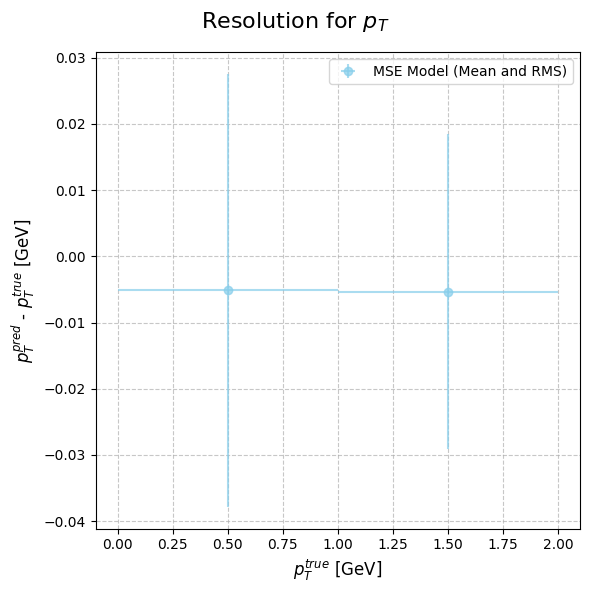

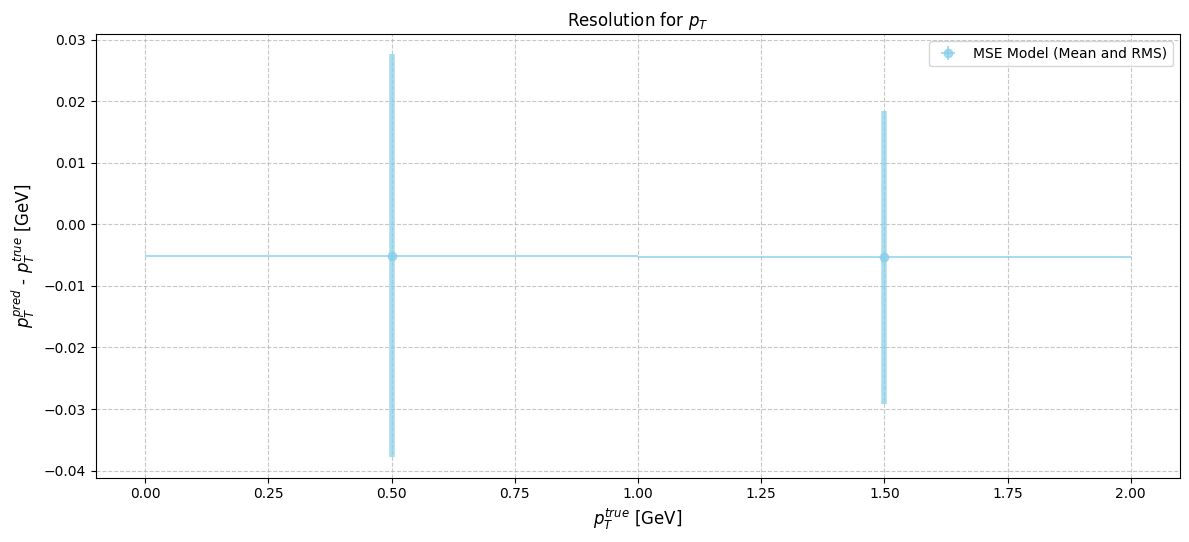

In [45]:
def plot_pi_resolutions(target_labels, pruning=False):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        if var == "p_T":
            pi_true_values = var_to_pT(
                values=pi_true_values, from_var=config["output_variables"][var_index]
            )

        title = f"Resolution for ${var}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        ylabel = f"{pred_label} - {true_label}" + (
            " [GeV]" if var.startswith("p") else ""
        )
        filename = f"resolution_{variable_filenames[var]}.png"
        if pruning:
            filename = filename.replace(".", "_pruning.")
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(6*len(models), 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(min(pi_true_values), max(pi_true_values), 100)
        if var == "p_T":
            bins = np.logspace(
                np.log10(min(pi_true_values)), np.log10(max(pi_true_values)), 15
            )
            bins = np.logspace(np.log10(min(pi_true_values)), np.log10(50), 10)
            bins = np.array([0, 1, 2, 4, 6, 8, 12, 16, 20, 24, 28, 34, 40, 50])
            bins = np.array([0, 1, 2, 4, 6, 8, 10])
            print(bins)

        # Loop over each model.
        model_data = {}
        for model_name, model_info in models.items():
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if var == "p_T":
                pi_pred_values = var_to_pT(
                    values=pi_pred_values,
                    from_var=config["output_variables"][var_index],
                )

            errors = pi_pred_values - pi_true_values
            model_data[model_name] = errors

        # Loop over each model.
        model_bins = {}
        for bin_index in range(len(bins)):
            if bin_index == 0:
                lower_bound = -np.inf
                continue
            else:
                lower_bound = bins[bin_index - 1]
            upper_bound = bins[bin_index]

            sel = (lower_bound < pi_true_values) & (pi_true_values <= upper_bound)
            for model_name, model_info in models.items():
                if not pruning:
                    errors_bin = model_data[model_name][sel]
                    model_bin_mean, model_bin_std = np.mean(errors_bin), np.std(errors_bin)
                else:
                    pi_pred_values = np.array(model_info["data_list"])[:, var_index]
                    if var == "p_T":
                        pi_pred_values = var_to_pT(
                            values=pi_pred_values,
                            from_var=config["output_variables"][var_index],
                        )

                    errors_bin_pruned, removed_outliers_bin = compute_track_resolution(
                        pi_true_values[sel], pi_pred_values[sel]
                    )

                    if len(pi_true_values[sel]) == 0:
                        outlier_ratio = np.inf
                    else:
                        outlier_ratio = len(removed_outliers_bin) / len(pi_true_values[sel])

                    print(f"Fraction of tracks identified as outliers by model {model_name}: {outlier_ratio:.4%} for bin {(lower_bound, upper_bound)}")

                    model_bin_mean, model_bin_std = np.mean(errors_bin_pruned), np.std(errors_bin_pruned)


                model_bins.setdefault(model_name, []).append(
                    (model_bin_mean, model_bin_std)
                )

        bin_centers = (bins[1:] + bins[:-1]) / 2

        # Loop over each model.
        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            bin_counts = np.array(model_bins[model_name])[..., 0]
            bin_std = np.array(model_bins[model_name])[..., 1]

            plt.subplot(1, len(models), model_index)

            plt.errorbar(
                bin_centers,
                bin_counts,
                yerr=bin_std,
                xerr=(bins[1:] - bins[:-1]) / 2,
                alpha=0.7,
                label=f"{model_info['label']} Model (Mean and RMS)",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()

        sync_plot_limits()
        
        if len(models) > 1:
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        else:
            plt.tight_layout()
        plt.savefig(filename, format="png")
        plt.show()

        # One figure
        filename = f"resolution_{variable_filenames[var]}_one_plot.png"
        if pruning:
            filename = filename.replace(".", "_pruning.")
        filename = output_dir / filename
        bin_sizes = bins[1:] - bins[:-1]
        plt.figure(figsize=(12, 6))

        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            bin_counts = np.array(model_bins[model_name])[..., 0]
            bin_std = np.array(model_bins[model_name])[..., 1]
            if model_index == 1:
                xerr = (bins[1:] - bins[:-1]) / 2
                x = bin_centers
            elif model_index == 2:
                shift = bin_sizes * 0.0
                xerr_low = bin_sizes / 2 + shift
                xerr_high = bin_sizes / 2 - shift
                xerr_high[xerr_high < 0] = 0
                xerr = [xerr_low, xerr_high]
                x = bin_centers + shift

            errorbar_obj = plt.errorbar(
                x,
                bin_counts,
                yerr=bin_std,
                xerr=xerr,
                alpha=0.7,
                label=f"{model_info['label']} Model (Mean and RMS)",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

            if model_index == 1:
                errorbar_obj[-1][1].set_linewidth(
                    4
                )  # errorbar_obj[-1][0] is the LineCollection objects of the errorbar lines
            elif model_index == 2:
                # Use dashed lines for y error bars
                # https://stackoverflow.com/questions/22995797/can-matplotlib-errorbars-have-a-linestyle-set
                errorbar_obj[-1][1].set_linestyle(
                    "--"
                )  # errorbar_obj[-1][0] is the LineCollection objects of the errorbar lines

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title(title)
        # Specify in the legend that vertical error bars are rms of the distribution
        plt.legend()
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_resolutions(target_labels=["p_T"])

Fraction of tracks identified as outliers by model MSE: 1.8284% for bin (-1.0, -0.9797979797979798)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.9797979797979798, -0.9595959595959596)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.9595959595959596, -0.9393939393939394)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.9393939393939394, -0.9191919191919192)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.9191919191919192, -0.898989898989899)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.898989898989899, -0.8787878787878788)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.8787878787878788, -0.8585858585858586)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.8585858585858586, -0.8383838383838383)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.8383838383838383, -0.8181818181818181)
Fracti

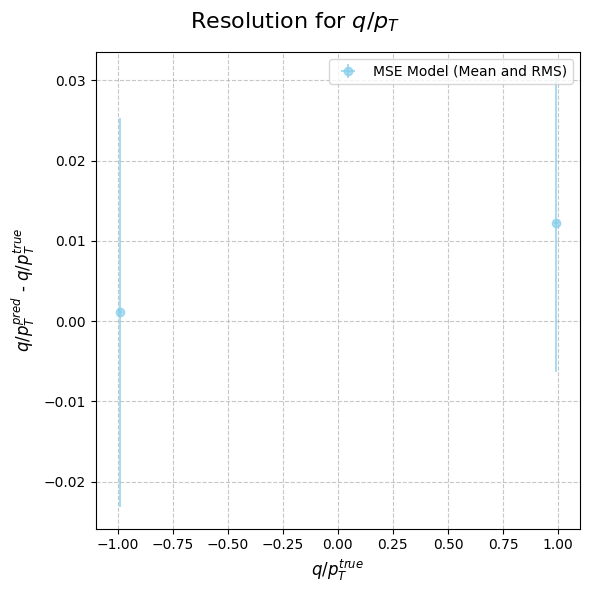

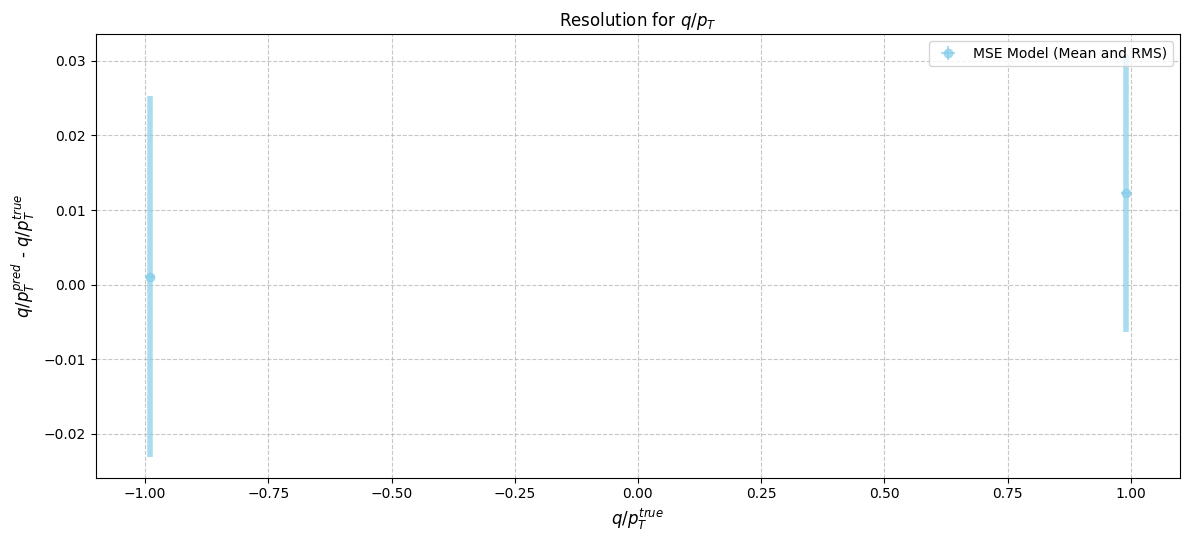

Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-10.017339706420898, -9.815418888824155)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-9.815418888824155, -9.613498071227411)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-9.613498071227411, -9.411577253630668)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-9.411577253630668, -9.209656436033923)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-9.209656436033923, -9.007735618437179)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-9.007735618437179, -8.805814800840436)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-8.805814800840436, -8.603893983243692)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-8.603893983243692, -8.401973165646949)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-8.401973165646949, -8

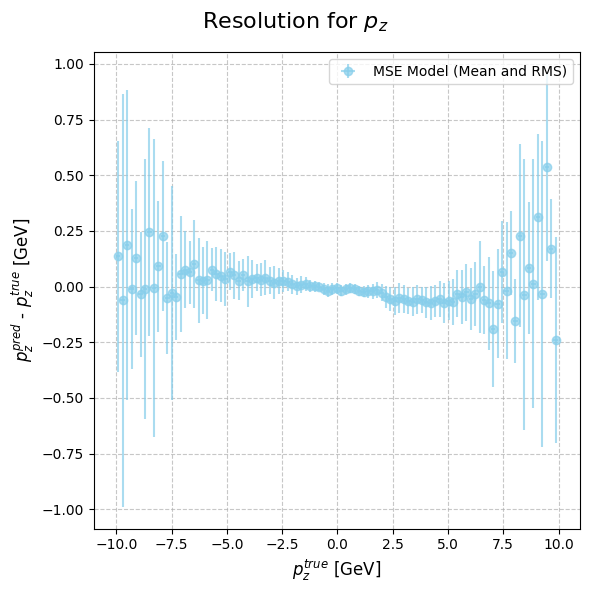

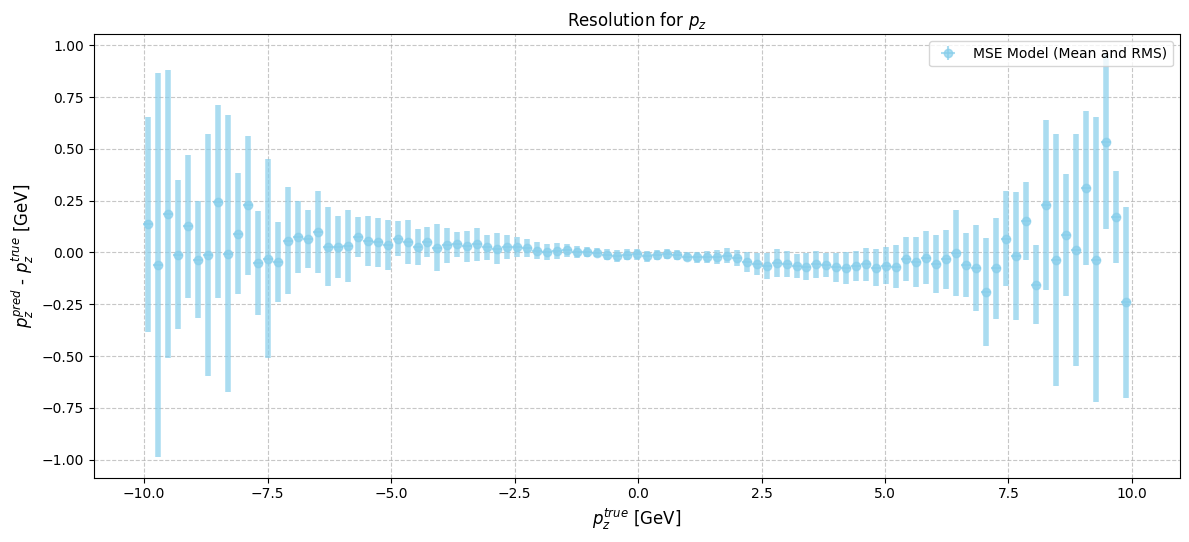

[ 0  1  2  4  6  8 10]
Fraction of tracks identified as outliers by model MSE: 1.2306% for bin (0, 1)
Fraction of tracks identified as outliers by model MSE: 1.0601% for bin (1, 2)
Fraction of tracks identified as outliers by model MSE: inf% for bin (2, 4)
Fraction of tracks identified as outliers by model MSE: inf% for bin (4, 6)
Fraction of tracks identified as outliers by model MSE: inf% for bin (6, 8)
Fraction of tracks identified as outliers by model MSE: inf% for bin (8, 10)


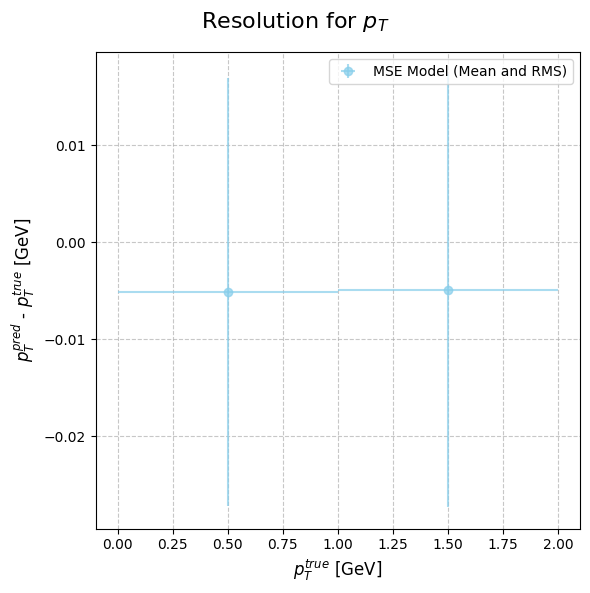

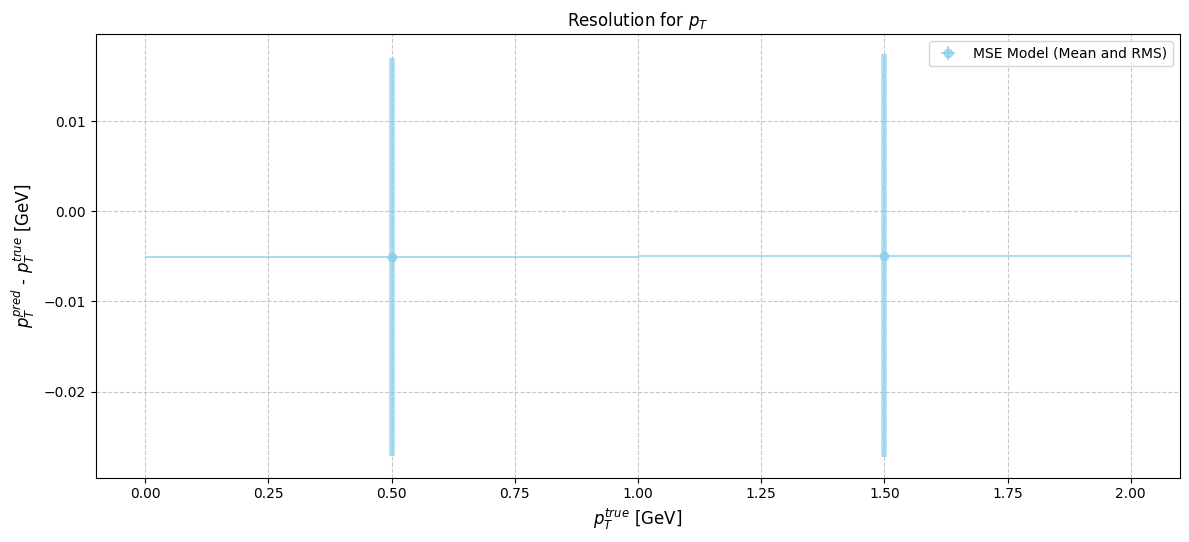

In [46]:
plot_pi_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    pruning=True,
    # publication=publication,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_resolutions(target_labels=["p_T"], pruning=True, 
                        # publication=publication
                        )

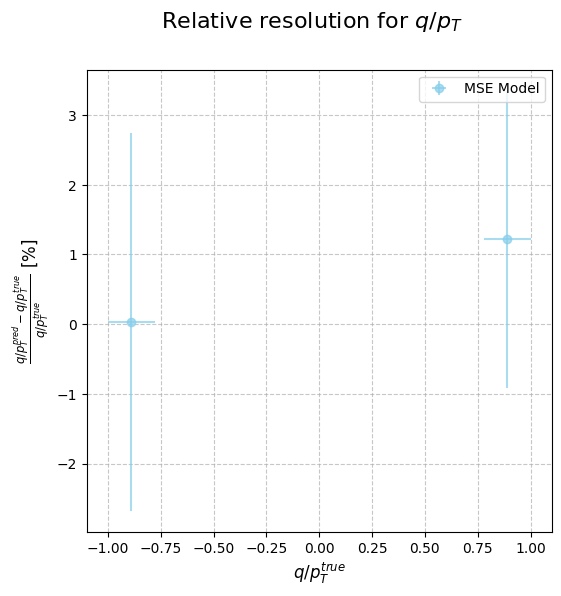

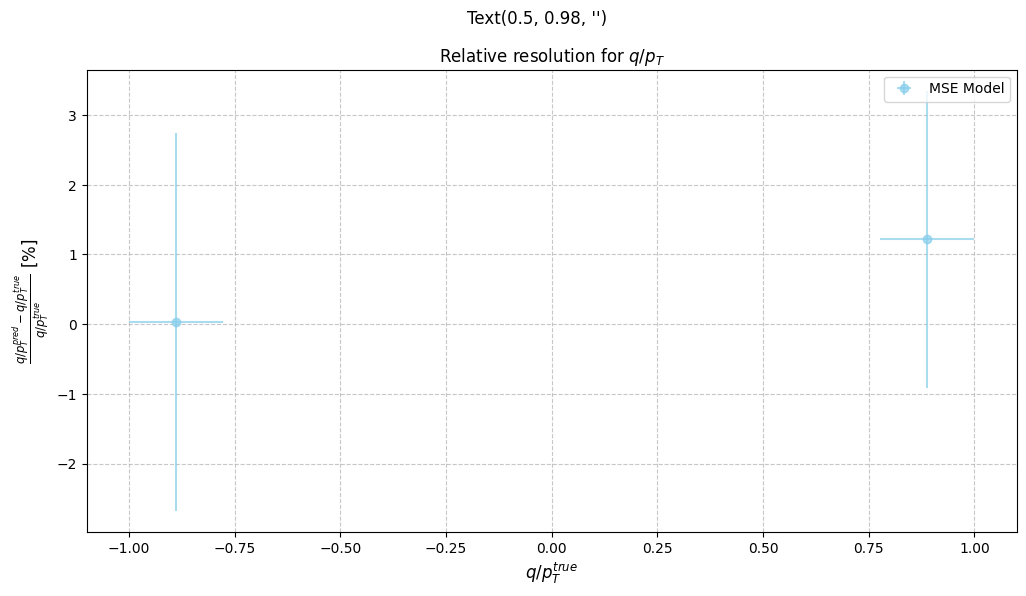

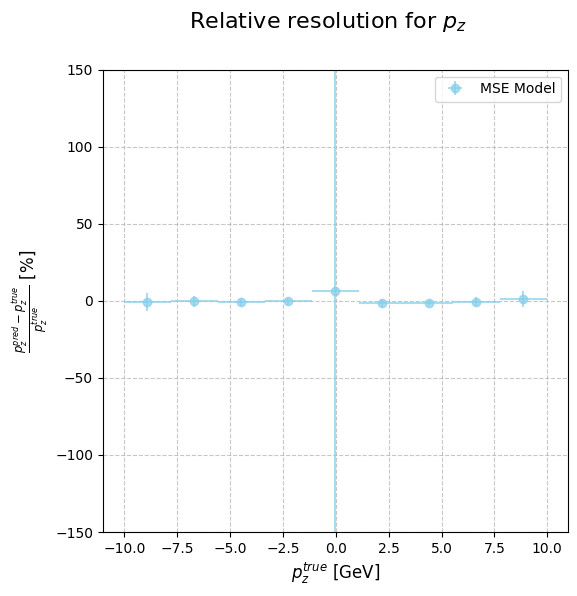

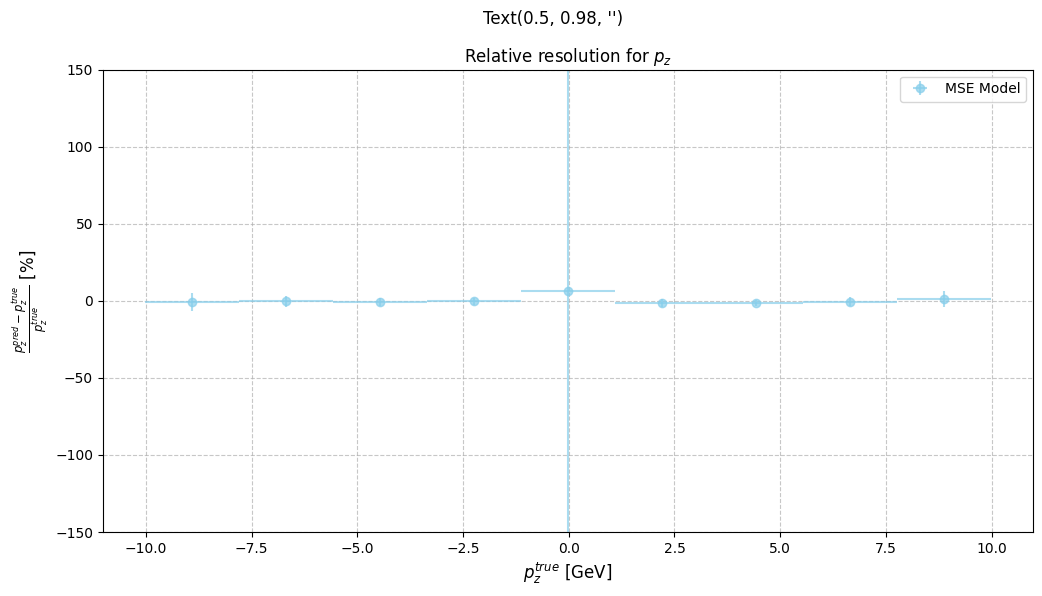

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:

Mean of empty slice.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning:

invalid value encountered in scalar divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning:

Degrees of freedom <= 0 for slice

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning:

invalid value encountered in divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning:

invalid value encountered in scalar divide



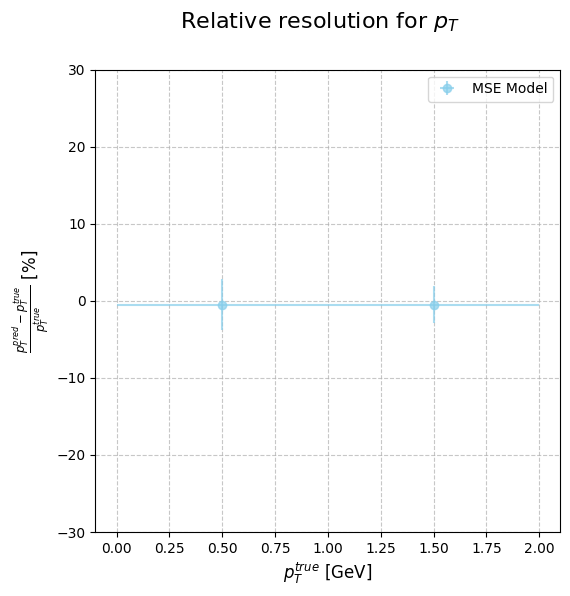

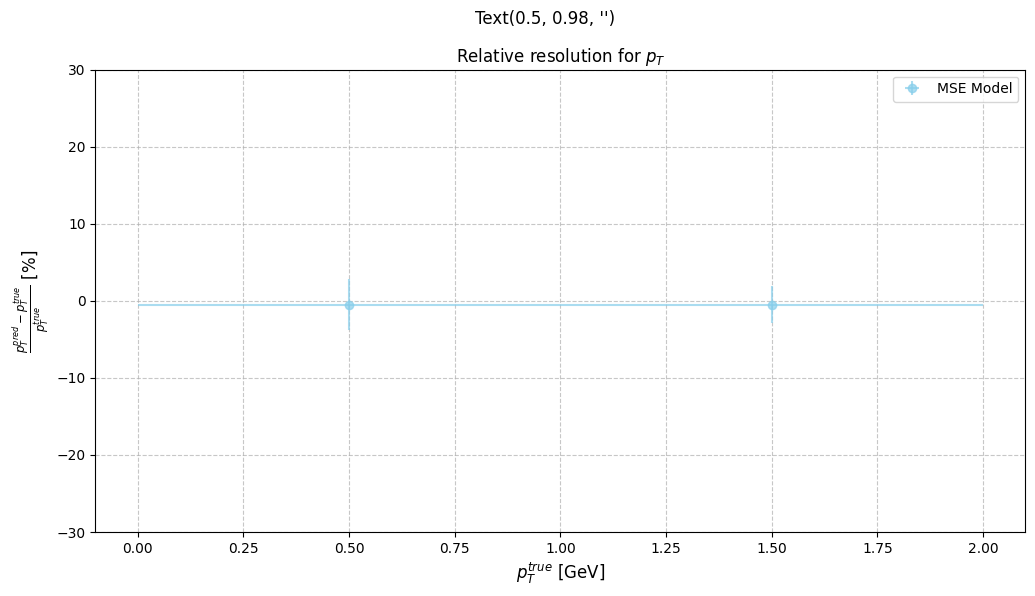

In [47]:
plot_pi_rel_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    pruning=False,
    low_pt=False,
    publication=publication,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_rel_resolutions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        pruning=False,
        low_pt=False,
        publication=publication,
    )

Fraction of tracks identified as outliers by model MSE: 1.8284% for bin (-1.0, -0.7777777777777778)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.7777777777777778, -0.5555555555555556)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.5555555555555556, -0.33333333333333337)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.33333333333333337, -0.11111111111111116)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-0.11111111111111116, 0.11111111111111116)
Fraction of tracks identified as outliers by model MSE: inf% for bin (0.11111111111111116, 0.33333333333333326)
Fraction of tracks identified as outliers by model MSE: inf% for bin (0.33333333333333326, 0.5555555555555554)
Fraction of tracks identified as outliers by model MSE: inf% for bin (0.5555555555555554, 0.7777777777777777)
Fraction of tracks identified as outliers by model MSE: 1.1795% for bin (0.7777777777777777, 1.0)


/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:

Mean of empty slice.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning:

invalid value encountered in scalar divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning:

Degrees of freedom <= 0 for slice

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning:

invalid value encountered in divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning:

invalid value encountered in scalar divide



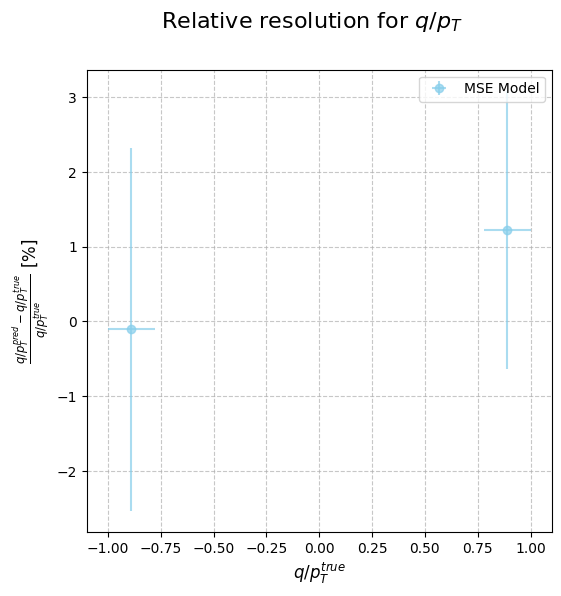

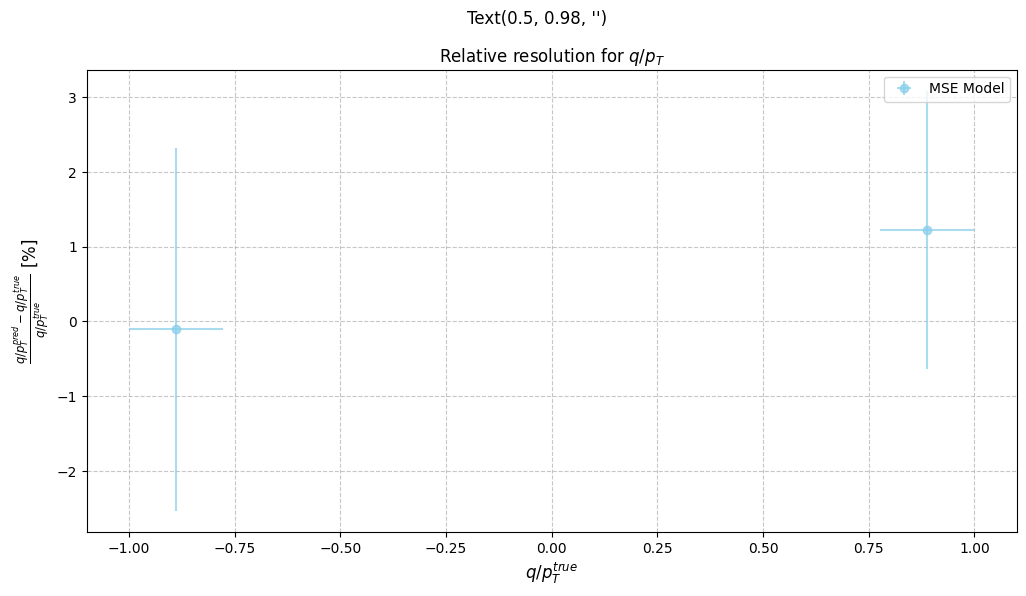

Fraction of tracks identified as outliers by model MSE: 4.0650% for bin (-10.017339706420898, -7.796210712856716)
Fraction of tracks identified as outliers by model MSE: 3.7543% for bin (-7.796210712856716, -5.575081719292535)
Fraction of tracks identified as outliers by model MSE: 3.4483% for bin (-5.575081719292535, -3.3539527257283535)
Fraction of tracks identified as outliers by model MSE: 1.1837% for bin (-3.3539527257283535, -1.1328237321641712)
Fraction of tracks identified as outliers by model MSE: 11.7030% for bin (-1.1328237321641712, 1.088305261400011)
Fraction of tracks identified as outliers by model MSE: 1.5686% for bin (1.088305261400011, 3.3094342549641915)
Fraction of tracks identified as outliers by model MSE: 2.2584% for bin (3.3094342549641915, 5.530563248528374)
Fraction of tracks identified as outliers by model MSE: 2.5478% for bin (5.530563248528374, 7.751692242092556)
Fraction of tracks identified as outliers by model MSE: 1.6260% for bin (7.751692242092556, 9.9

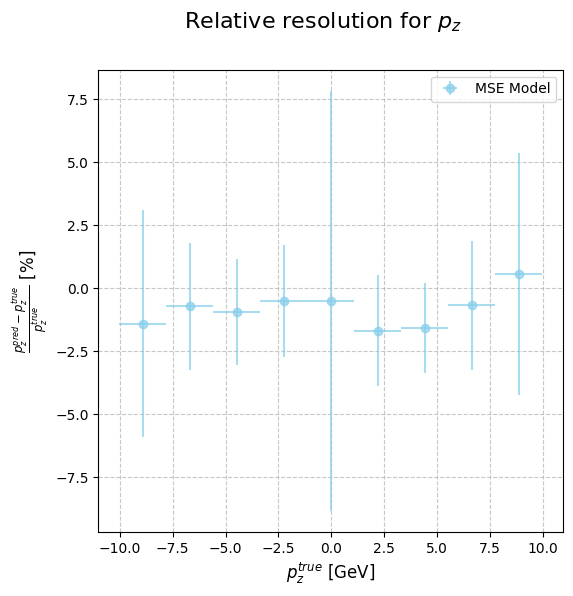

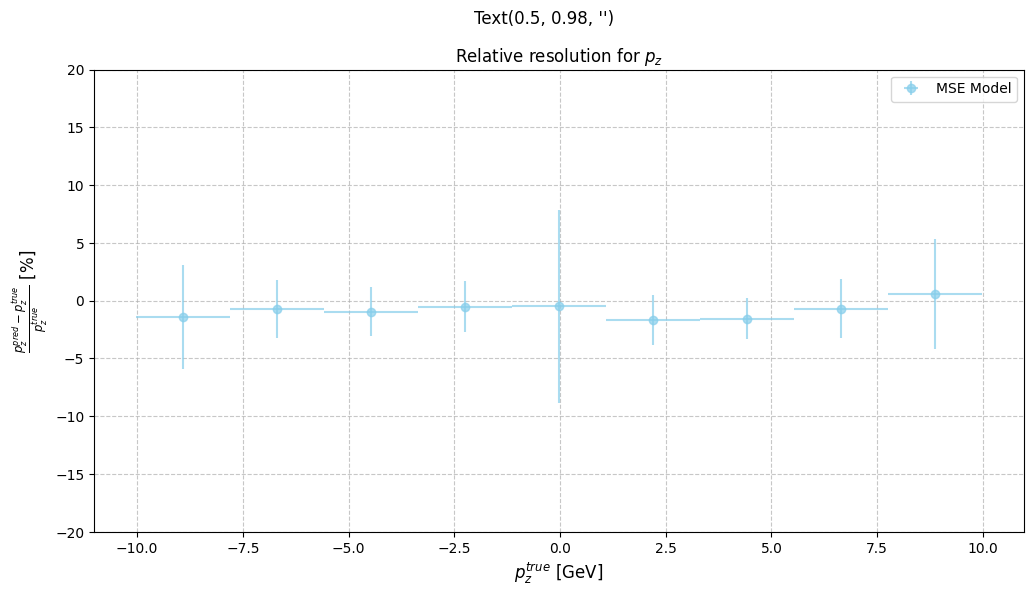

Fraction of tracks identified as outliers by model MSE: 1.2306% for bin (0, 1)
Fraction of tracks identified as outliers by model MSE: 1.0601% for bin (1, 2)
Fraction of tracks identified as outliers by model MSE: inf% for bin (2, 4)
Fraction of tracks identified as outliers by model MSE: inf% for bin (4, 6)
Fraction of tracks identified as outliers by model MSE: inf% for bin (6, 8)
Fraction of tracks identified as outliers by model MSE: inf% for bin (8, 10)


/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:

Mean of empty slice.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning:

invalid value encountered in scalar divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning:

Degrees of freedom <= 0 for slice

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning:

invalid value encountered in divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning:

invalid value encountered in scalar divide



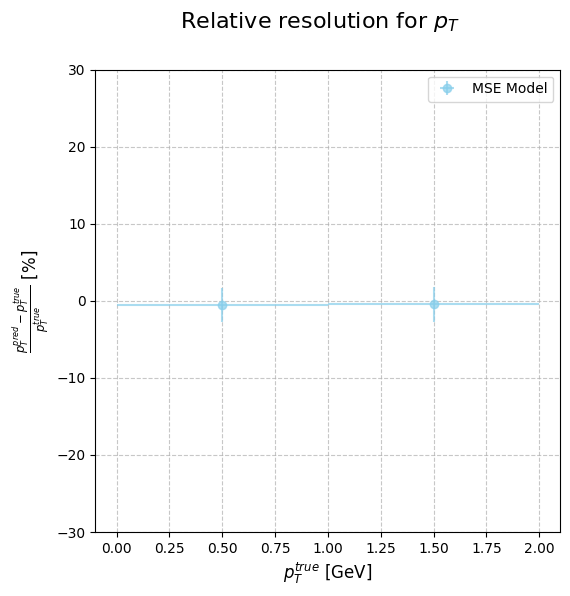

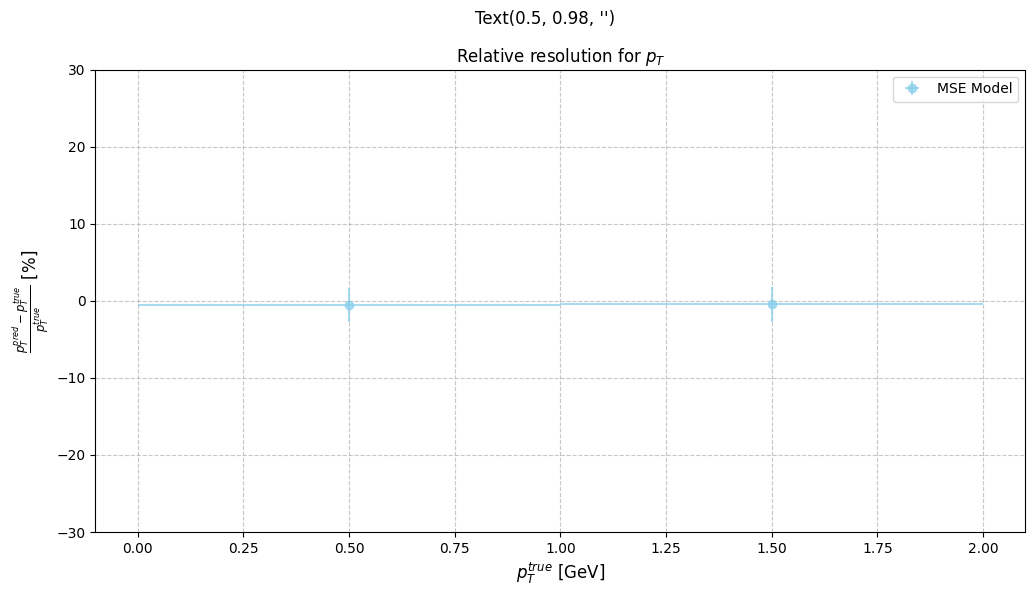

In [48]:
plot_pi_rel_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    pruning=True,
    low_pt=False,
    publication=publication,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_rel_resolutions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        pruning=True,
        low_pt=False,
        publication=publication,
    )

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:

Mean of empty slice.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning:

invalid value encountered in scalar divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning:

Degrees of freedom <= 0 for slice

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning:

invalid value encountered in divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning:

invalid value encountered in scalar divide



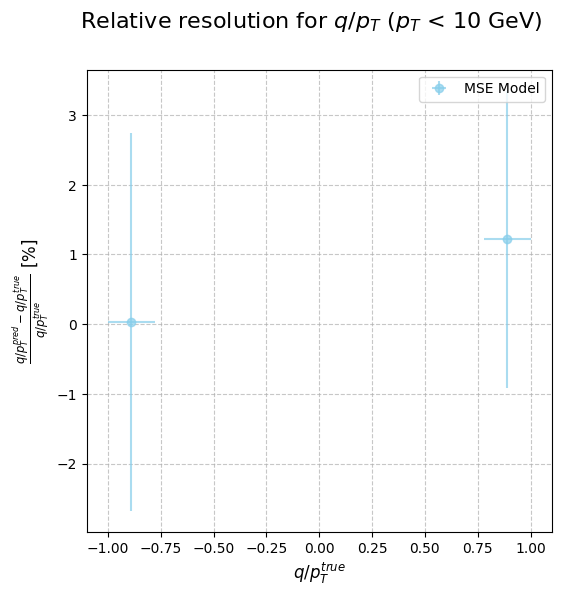

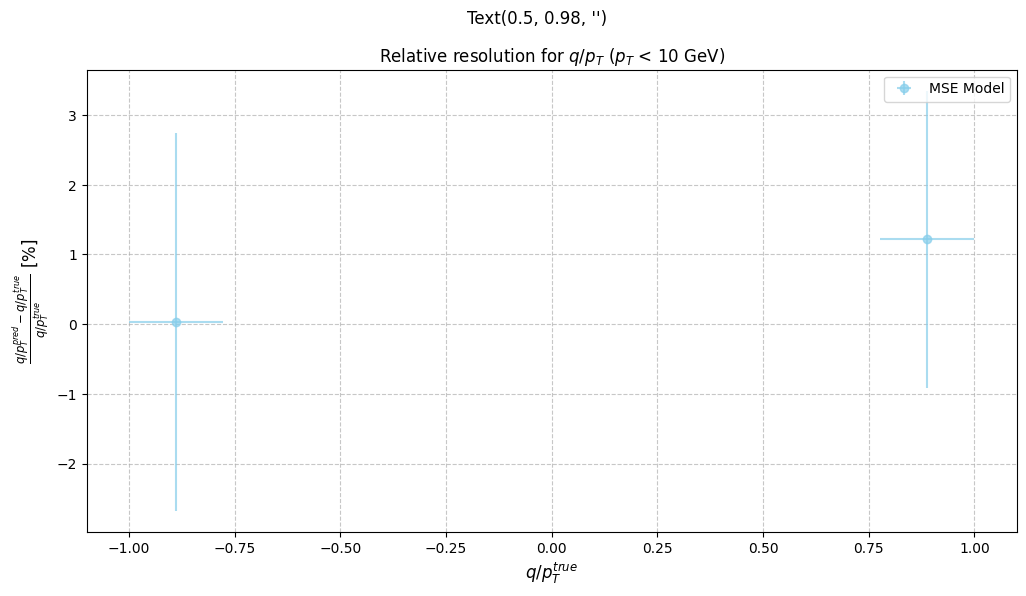

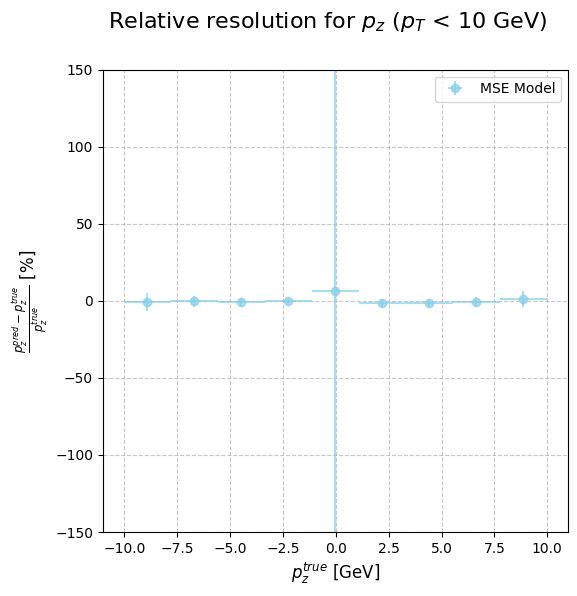

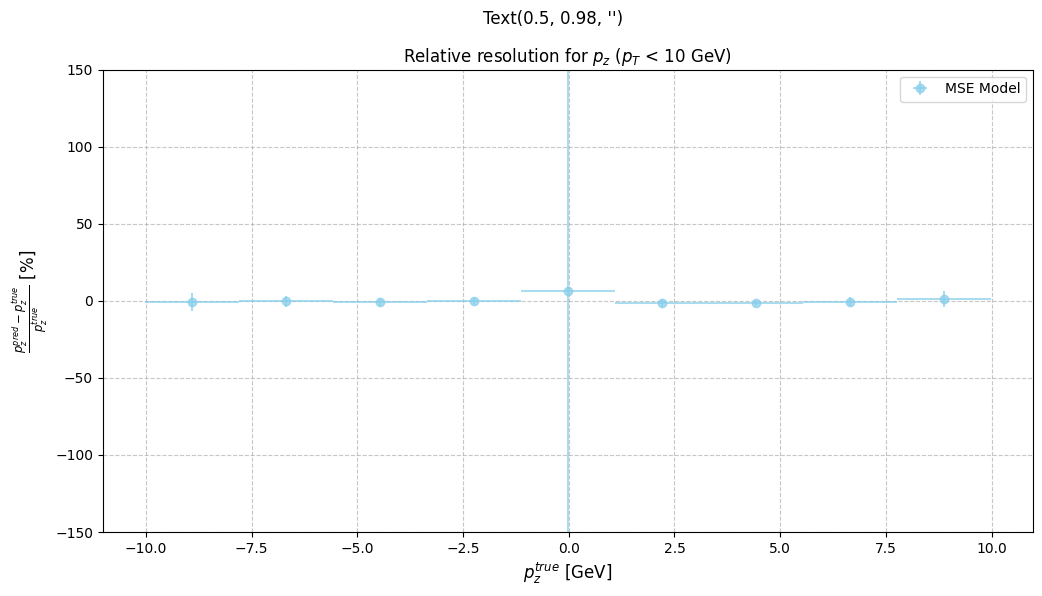

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:

Mean of empty slice.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning:

invalid value encountered in scalar divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning:

Degrees of freedom <= 0 for slice

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning:

invalid value encountered in divide

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning:

invalid value encountered in scalar divide



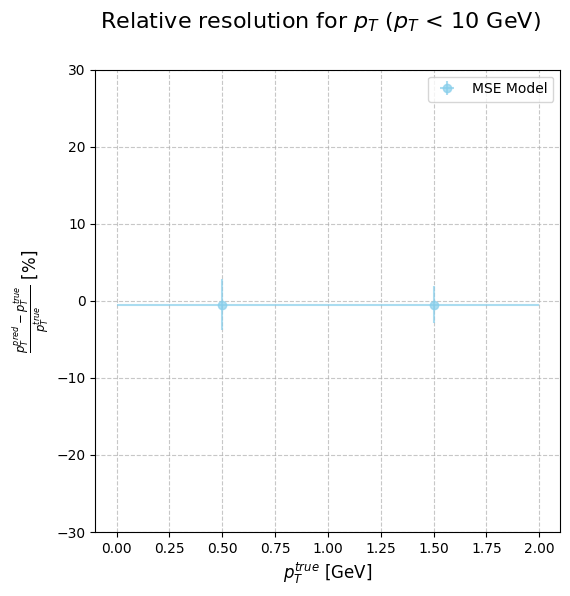

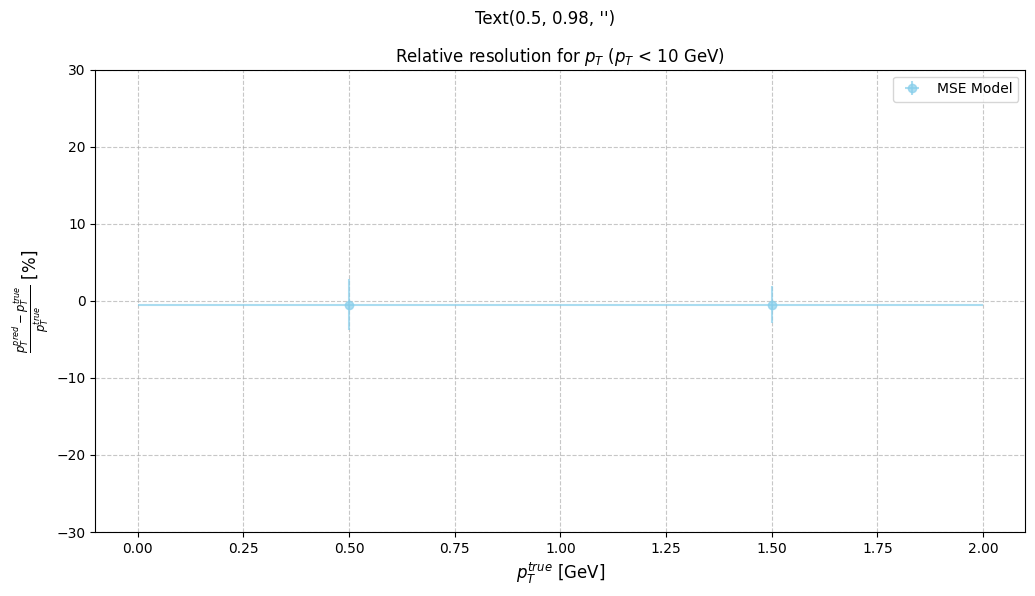

In [49]:
plot_pi_rel_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    pruning=False,
    low_pt=True,
    publication=publication,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_rel_resolutions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        pruning=False,
        low_pt=True,
        publication=publication,
    )

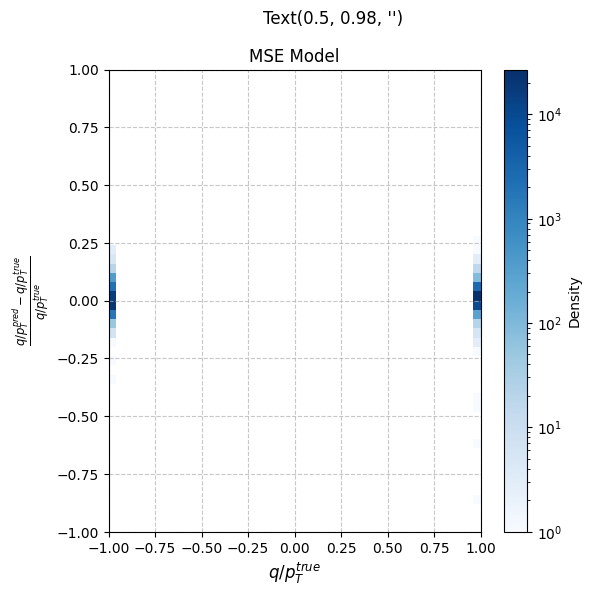

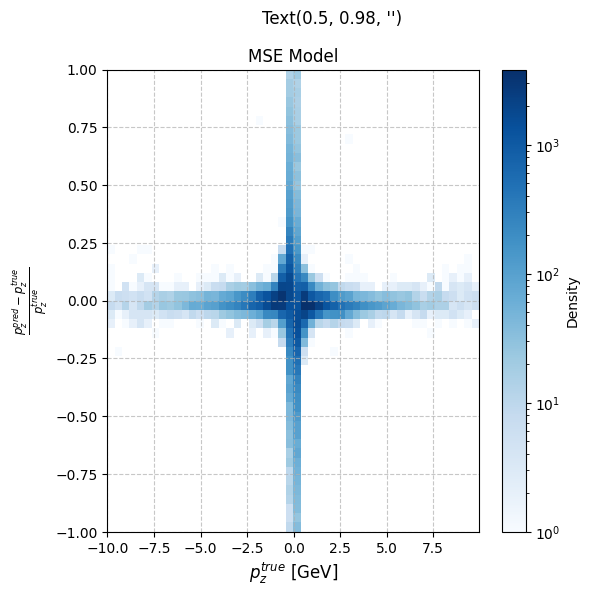

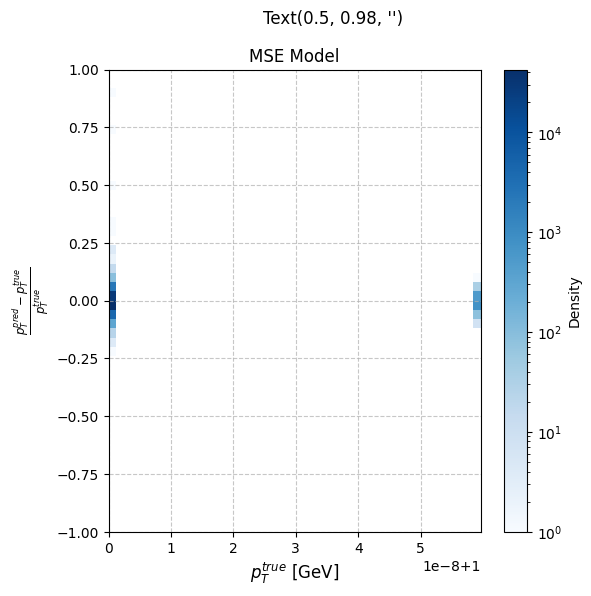

In [50]:
import numpy as np
import matplotlib.pyplot as plt

plot_2d_histogram(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    publication=publication,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_2d_histogram(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        publication=publication,
    )

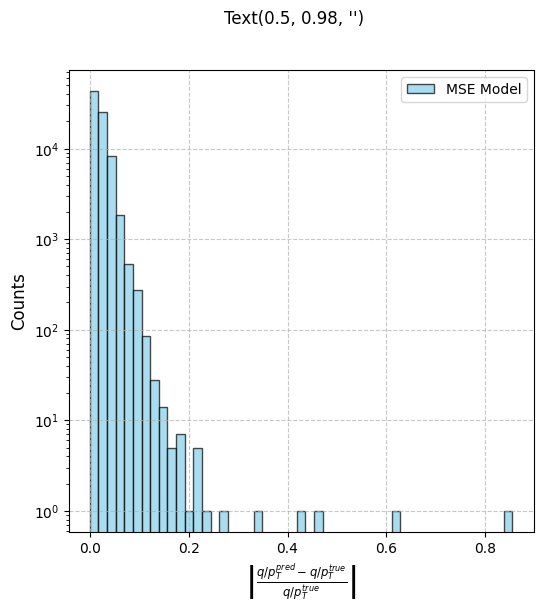

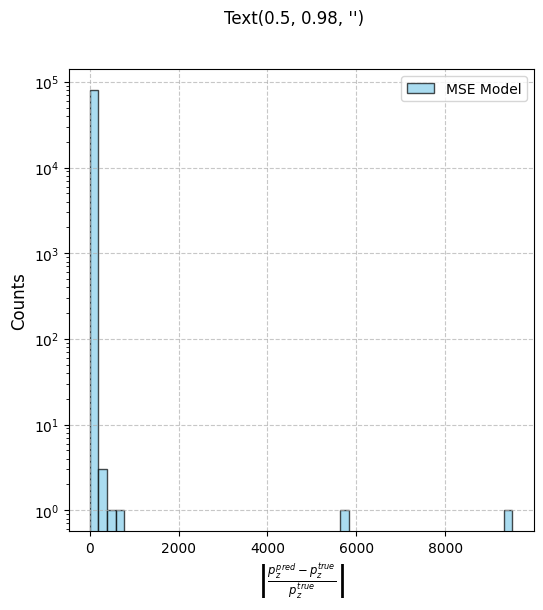

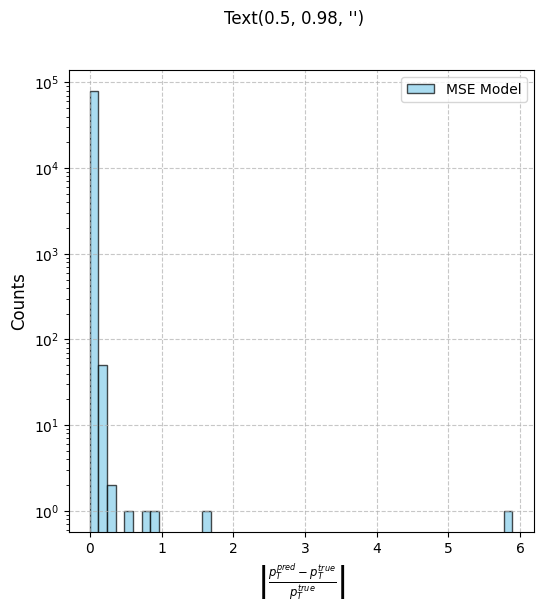

In [51]:
plot_pi_relative_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    abs=True,
    low_pt=False,
    publication=publication,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        abs=True,
        low_pt=False,
        publication=publication,
    )

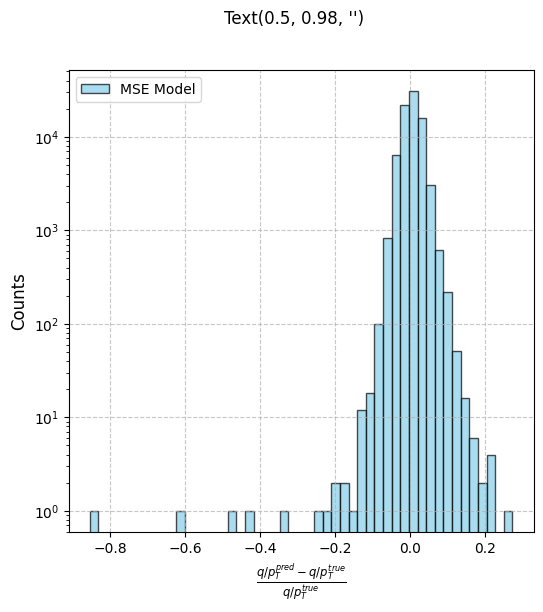

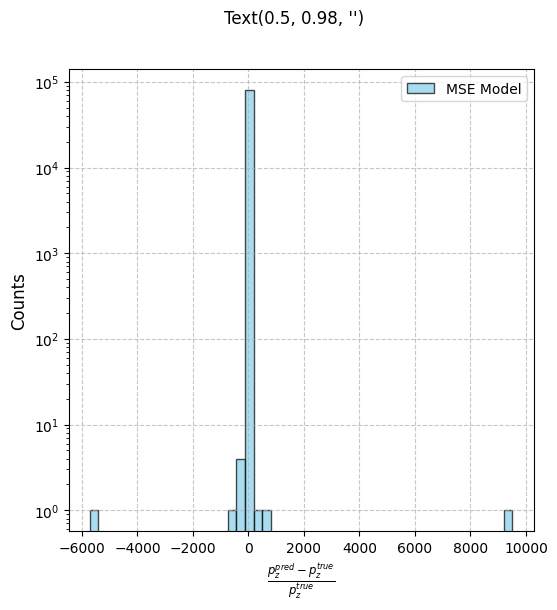

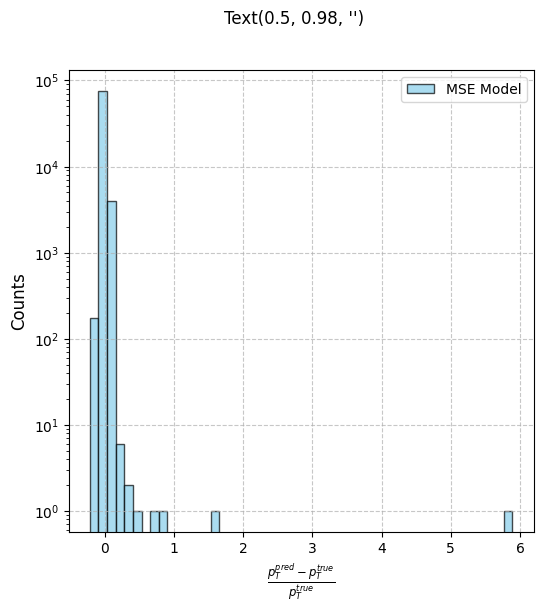

In [52]:
plot_pi_relative_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    abs=False,
    low_pt=False,
    publication=publication,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        abs=False,
        low_pt=False,
        publication=publication,
    )

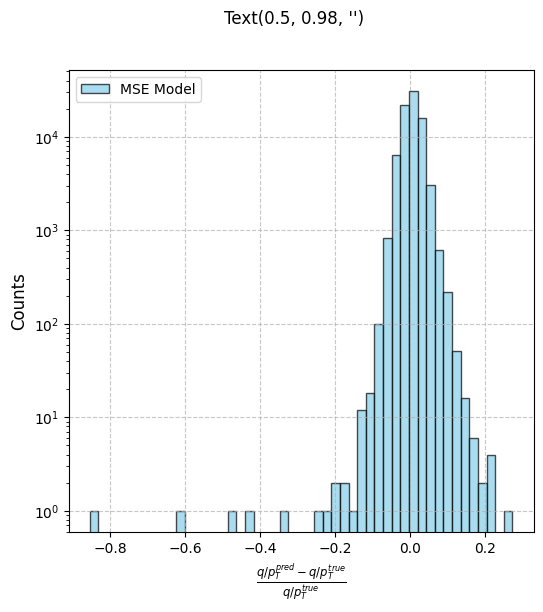

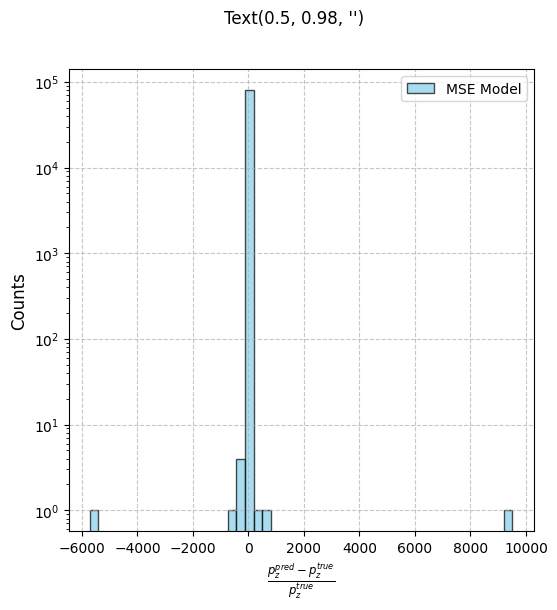

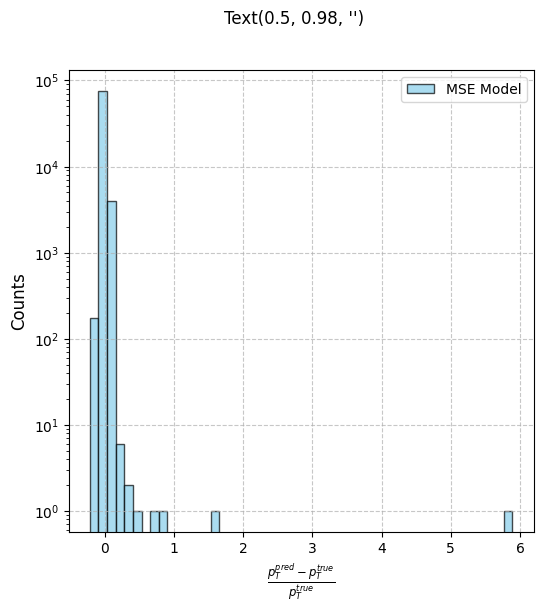

In [53]:
plot_pi_relative_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    abs=False,
    low_pt=True,
    publication=publication,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        abs=False,
        low_pt=True,
        publication=publication,
    )

MSE: 0.0064 +- 0.0246


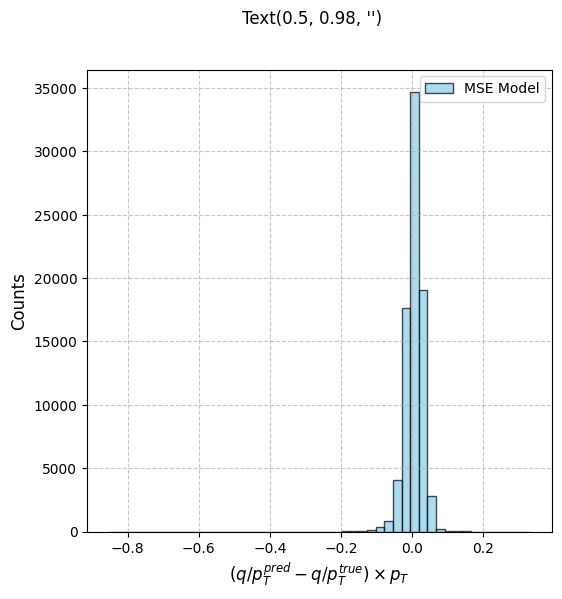

MSE: -0.0110 +- 0.0518


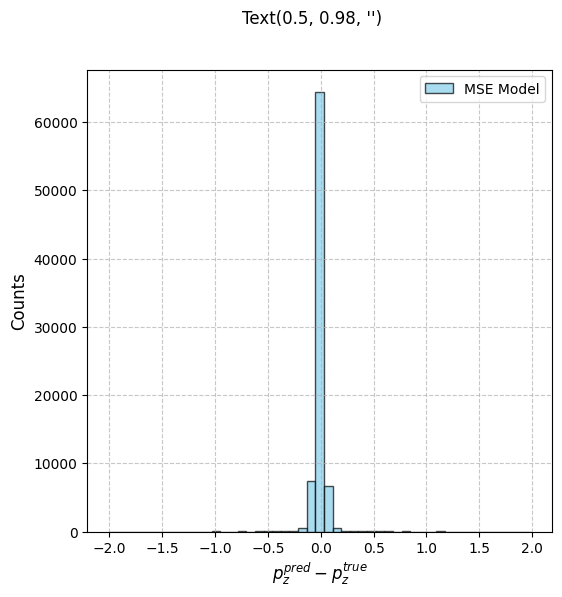

MSE: -0.0051 +- 0.0326


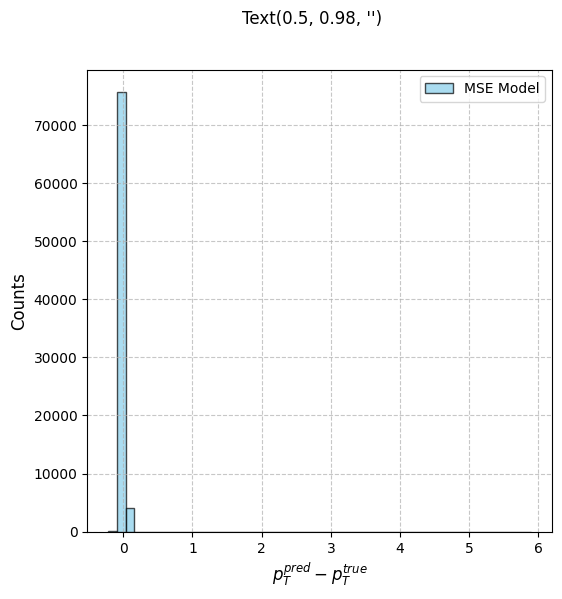

In [54]:
plot_pi_error_distributions_p(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    publication=publication,
)
if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_error_distributions_p(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        publication=publication,
    )

In [55]:
def plot_pi_relative_error_distributions_low_pt_1_2__(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]
        if var == "p_T":
            pi_true_values = var_to_pT(
                values=pi_true_values, from_var=config["output_variables"][var_index]
            )
            pi_pred_mse_list = var_to_pT(
                values=pi_pred_mse_list, from_var=config["output_variables"][var_index]
            )
            pi_pred_qloss_list = var_to_pT(
                values=pi_pred_qloss_list, from_var=config["output_variables"][var_index]
            )

        errors_mse_var = pi_pred_mse_list - pi_true_values
        errors_qloss_var = pi_pred_qloss_list - pi_true_values

        relative_errors_mse_var = errors_mse_var / pi_true_values
        relative_errors_qloss_var = errors_qloss_var / pi_true_values

        pt_true = np.array(p_true_list)[:, 0]
        pt_true = var_to_pT(values=pt_true, from_var=config["output_variables"][0])
        # Select only events with 1 GeV < p_T < 2 GeV.
        mask = pt_true < 2
        mask = mask & (pt_true > 1)
        relative_errors_mse_var = relative_errors_mse_var[mask]
        relative_errors_qloss_var = relative_errors_qloss_var[mask]

        title = f"Relative Error Distributions for ${var}$ (1 GeV < $p_T$ < 2 GeV)"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}$"
        ylabel = "Density"
        filename = (
            f"relative_error_distributions_{variable_filenames[var]}_low_pt_1_2_fit_comp.png"
        )
        filename = output_dir / filename

        # Add a gaussian with mean and std of the distribution
        from scipy.stats import norm

        mean_mse_, std_mse_ = norm.fit(relative_errors_mse_var)
        mean_qloss_, std_qloss_ = norm.fit(relative_errors_qloss_var)

        relative_errors_mse_var_pruned, _ = compute_track_resolution(
            pi_true_values[mask] / pi_true_values[mask],
            pi_pred_mse_list[mask] / pi_true_values[mask],
        )
        relative_errors_qloss_var_pruned, _ = compute_track_resolution(
            pi_true_values[mask] / pi_true_values[mask],
            pi_pred_qloss_list[mask] / pi_true_values[mask],
        )

        mean_mse, std_mse = np.mean(relative_errors_mse_var_pruned), np.std(
            relative_errors_mse_var_pruned
        )
        mean_qloss, std_qloss = np.mean(relative_errors_qloss_var_pruned), np.std(
            relative_errors_qloss_var_pruned
        )

        # Do a normal fit
        mean_mse_MLE, std_mse_MLE = norm.fit(relative_errors_mse_var_pruned, method="MLE")
        mean_qloss_MLE, std_qloss_MLE = norm.fit(relative_errors_qloss_var_pruned, method="MLE")

        mean_mse_MM, std_mse_MM = norm.fit(relative_errors_mse_var_pruned, method="MM")
        mean_qloss_MM, std_qloss_MM = norm.fit(relative_errors_qloss_var_pruned, method="MM")

        # Add a real gaussian fit
        from scipy.stats import norm
        from scipy.optimize import curve_fit

        def gaussian(x, amplitude, mean, stddev):
            # Normalized Gaussian
            amplitude = 1 / (stddev * np.sqrt(2 * np.pi))
            return amplitude * np.exp(-(((x - mean) / 4 / stddev) ** 2))

        def gaussian(x, mean, stddev):
            # Normalized Gaussian
            amplitude = 1 / (stddev * np.sqrt(2 * np.pi))
            return amplitude * np.exp(-(((x - mean) / 4 / stddev) ** 2))

        def fit_gaussian(y, x, p0=[0, 0.4]):
            # Remove extra x value
            x = x[:-1]
            # popt, _ = curve_fit(gaussian, x, y, p0=[1, 0, 1], bounds=([0, -np.inf, 0], [np.inf, np.inf, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=[1, 0, 0.1], bounds=([0, -3, 0], [np.inf, 3, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-3, 0], [3, 1]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-2, 0], [np.inf, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-1.5, 0], [1.5, 35]))
            popt, pcov = curve_fit(
                norm.pdf, x, y, p0=p0, bounds=([-np.inf, 0], [np.inf, np.inf])
            )
            perr = np.sqrt(np.diag(pcov))
            return popt, perr

        # Get the 82% quantile
        from scipy.stats import scoreatpercentile

        quantile_target = (1 - (1 / 1744278)) * 100
        # quantile_target = (1-(1 / 370.398)) * 100
        # quantile_target = (1-(1 / 3.1514872)) * 100
        q_mse = scoreatpercentile(relative_errors_mse_var, quantile_target)
        q_qloss = scoreatpercentile(relative_errors_qloss_var, quantile_target)

        print(f"{quantile_target}% quantile for MSE: {q_mse}")
        print(f"{quantile_target}% quantile for Qloss: {q_qloss}")

        # Same with lower quantile
        low_quantile_target = 100 - quantile_target
        q_low_mse = scoreatpercentile(relative_errors_mse_var, low_quantile_target)
        q_low_qloss = scoreatpercentile(relative_errors_qloss_var, low_quantile_target)

        print(f"{low_quantile_target}% quantile for MSE: {q_low_mse}")
        print(f"{low_quantile_target}% quantile for Qloss: {q_low_qloss}")

        n_sig = 5
        # q_low_qloss = (q_low_qloss-mean_qloss)*n_sig + mean_qloss
        # q_qloss = (q_qloss-mean_qloss)*n_sig + mean_qloss
        # q_low_mse = (q_low_mse-mean_mse)*n_sig + mean_mse
        # q_mse = (q_mse-mean_mse)*n_sig + mean_mse

        q_low_mse = max(q_low_mse, -n_sig * std_mse_ + mean_mse_)
        q_low_qloss = max(q_low_qloss, -n_sig * std_qloss_ + mean_qloss_)
        q_mse = min(q_mse, n_sig * std_mse_ + mean_mse_)
        q_qloss = min(q_qloss, n_sig * std_qloss_ + mean_qloss_)

        if var == "p_z":
            q_low_mse = -2
            q_low_qloss = -2
            q_mse = 2
            q_qloss = 2

        bins = 100
        mse_bins, mse_edges = np.histogram(
            relative_errors_mse_var, bins=bins, density=True, range=(q_low_mse, q_mse)
        )
        qloss_bins, qloss_edges = np.histogram(
            relative_errors_qloss_var,
            bins=bins,
            density=True,
            range=(q_low_qloss, q_qloss),
        )

        mse_fit, mse_fit_err = fit_gaussian(
            mse_bins, mse_edges, p0=[mean_mse_, std_mse_]
        )
        qloss_fit, qloss_fit_err = fit_gaussian(
            qloss_bins, qloss_edges, p0=[mean_qloss_, std_qloss_]
        )

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            relative_errors_mse_var,
            bins=mse_edges,
            alpha=0.3,
            label="MSE Model",
            color="skyblue",
            edgecolor="black",
            density=True,
        )
        # Plot the pruned version
        plt.hist(
            relative_errors_mse_var_pruned,
            bins=mse_edges,
            alpha=0.3,
            label="MSE Model (Pruned)",
            color="blue",
            edgecolor="black",
            density=True,
        )

        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_mse, std_mse)
        p_MLE = norm.pdf(x, mean_mse_MLE, std_mse_MLE)
        p_MM = norm.pdf(x, mean_mse_MM, std_mse_MM)
        p_fit = norm.pdf(x, *mse_fit)
        plt.plot(
            x,
            p,
            "r",
            linewidth=2,
            linestyle="--",
            label=f"Paper pruning (MSE) \nMean: {mean_mse:5.3f}, Std: {std_mse:5.3f}",
        )
        plt.plot(
            x,
            p_MLE,
            "g",
            linewidth=2,
            linestyle="--",
            label=f"MLE Fit Gaussian (MSE) \nMean: {mean_mse_MLE:5.3f}, Std: {std_mse_MLE:5.3f}",
        )
        plt.plot(
            x,
            p_MM,
            "c",
            linewidth=2,
            linestyle="--",
            label=f"MM Fit Gaussian (MSE) \nMean: {mean_mse_MM:5.3f}, Std: {std_mse_MM:5.3f}",
        )

        plt.plot(
            x,
            p_fit,
            "b",
            linewidth=2,
            linestyle="--",
            label=f"Curve Fit Gaussian (MSE) \nMean: {mse_fit[0]:5.3f} +/- {mse_fit_err[0]:5.3f}\nStd: {mse_fit[1]:5.3f} +/- {mse_fit_err[1]:5.3f}",
        )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        # Limit at 5 sigma
        plt.xlim(q_low_mse, q_mse)
        # plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            relative_errors_qloss_var,
            bins=qloss_edges,
            alpha=0.3,
            label="Quantile Loss Model",
            color="coral",
            edgecolor="black",
            density=True,
        )
        # Plot the pruned version
        plt.hist(
            relative_errors_qloss_var_pruned,
            bins=qloss_edges,
            alpha=0.3,
            label="Quantile Loss Model (Pruned)",
            color="red",
            edgecolor="black",
            density=True,
        )

        # Limit at 5 sigma
        plt.xlim(q_low_qloss, q_qloss)
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_qloss, std_qloss)
        p_MLE = norm.pdf(x, mean_qloss_MLE, std_qloss_MLE)
        p_MM = norm.pdf(x, mean_qloss_MM, std_qloss_MM)
        p_fit = norm.pdf(x, *qloss_fit)
        plt.plot(
            x,
            p,
            "r",
            linewidth=2,
            linestyle="--",
            label=f"Paper pruning (Qloss) \nMean: {mean_qloss:5.3f}, Std: {std_qloss:5.3f}",
        )
        plt.plot(
            x,
            p_MLE,
            "g",
            linewidth=2,
            linestyle="--",
            label=f"MLE Fit Gaussian (Qloss) \nMean: {mean_qloss_MLE:5.3f}, Std: {std_qloss_MLE:5.3f}",
        )
        plt.plot(
            x,
            p_MM,
            "c",
            linewidth=2,
            linestyle="--",
            label=f"MM Fit Gaussian (Qloss) \nMean: {mean_qloss_MM:5.3f}, Std: {std_qloss_MM:5.3f}",
        )
        plt.plot(
            x,
            p_fit,
            "b",
            linewidth=2,
            linestyle="--",
            label=f"Curve Fit Gaussian (Qloss) \nMean: {qloss_fit[0]:5.3f} +/- {qloss_fit_err[0]:5.3f}\nStd: {qloss_fit[1]:5.3f} +/- {qloss_fit_err[1]:5.3f}",
        )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        # plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, mean_mse, std_mse), neglog=True)}"
        )
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, mean_mse_, std_mse_), neglog=True)}"
        )
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, *mse_fit), neglog=True)}"
        )


# plot_pi_relative_error_distributions_low_pt_1_2__(
#     target_labels=[variable_labels[var] for var in config["output_variables"]]
# )
# if config["output_variables"][0] in ["qopT", "qpT"]:
#     plot_pi_relative_error_distributions_low_pt_1_2__(target_labels=["p_T"])

In [56]:
def plot_pi_relative_error_distributions_low_pt_1_2___(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]
        if var == "p_T":
            pi_true_values = var_to_pT(
                values=pi_true_values, from_var=config["output_variables"][var_index]
            )
            pi_pred_mse_list = var_to_pT(
                values=pi_pred_mse_list, from_var=config["output_variables"][var_index]
            )
            pi_pred_qloss_list = var_to_pT(
                values=pi_pred_qloss_list, from_var=config["output_variables"][var_index]
            )

        errors_mse_var = pi_pred_mse_list - pi_true_values
        errors_qloss_var = pi_pred_qloss_list - pi_true_values

        relative_errors_mse_var = errors_mse_var / pi_true_values
        relative_errors_qloss_var = errors_qloss_var / pi_true_values

        pt_true = np.array(p_true_list)[:, 0]
        pt_true = var_to_pT(values=pt_true, from_var=config["output_variables"][0])
        # Select only events with 1 GeV < p_T < 2 GeV.
        mask = pt_true < 2
        mask = mask & (pt_true > 1)
        relative_errors_mse_var = relative_errors_mse_var[mask]
        relative_errors_qloss_var = relative_errors_qloss_var[mask]

        title = f"Relative Error Distributions for ${var}$ (1 GeV < $p_T$ < 2 GeV)"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}$"
        ylabel = "Density"
        filename = (
            f"relative_error_distributions_{variable_filenames[var]}_low_pt_1_2_fit_comp.png"
        )
        filename = output_dir / filename

        # Add a gaussian with mean and std of the distribution
        from scipy.stats import norm

        mean_mse_, std_mse_ = norm.fit(relative_errors_mse_var)
        mean_qloss_, std_qloss_ = norm.fit(relative_errors_qloss_var)

        relative_errors_mse_var_pruned, _ = compute_track_resolution(
            pi_true_values[mask] / pi_true_values[mask],
            pi_pred_mse_list[mask] / pi_true_values[mask],
        )
        relative_errors_qloss_var_pruned, _ = compute_track_resolution(
            pi_true_values[mask] / pi_true_values[mask],
            pi_pred_qloss_list[mask] / pi_true_values[mask],
        )

        mean_mse, std_mse = np.mean(relative_errors_mse_var_pruned), np.std(
            relative_errors_mse_var_pruned
        )
        mean_qloss, std_qloss = np.mean(relative_errors_qloss_var_pruned), np.std(
            relative_errors_qloss_var_pruned
        )

        # Do a normal fit
        mean_mse_MLE, std_mse_MLE = norm.fit(relative_errors_mse_var_pruned, method="MLE")
        mean_qloss_MLE, std_qloss_MLE = norm.fit(relative_errors_qloss_var_pruned, method="MLE")

        mean_mse_MM, std_mse_MM = norm.fit(relative_errors_mse_var_pruned, method="MM")
        mean_qloss_MM, std_qloss_MM = norm.fit(relative_errors_qloss_var_pruned, method="MM")

        lower_bound_mse, upper_bound_mse, interval_center_mse = get_smallest_confidence_interval(relative_errors_mse_var)
        print(f"{lower_bound_mse = }, {upper_bound_mse = } {interval_center_mse = }")
        lower_bound_sigma_mse = lower_bound_mse - interval_center_mse
        upper_bound_sigma_mse = upper_bound_mse - interval_center_mse
        print(f"{lower_bound_sigma_mse = }, {upper_bound_sigma_mse = } {interval_center_mse = }")

        lower_bound_qloss, upper_bound_qloss, interval_center_qloss = get_smallest_confidence_interval(relative_errors_qloss_var)
        print(f"{lower_bound_qloss = }, {upper_bound_qloss = } {interval_center_qloss = }")
        lower_bound_sigma_qloss = lower_bound_qloss - interval_center_qloss
        upper_bound_sigma_qloss = upper_bound_qloss - interval_center_qloss
        print(f"{lower_bound_sigma_qloss = }, {upper_bound_sigma_qloss = } {interval_center_qloss = }")
        

        

        # Add a real gaussian fit
        from scipy.stats import norm
        from scipy.optimize import curve_fit

        def gaussian(x, amplitude, mean, stddev):
            # Normalized Gaussian
            amplitude = 1 / (stddev * np.sqrt(2 * np.pi))
            return amplitude * np.exp(-(((x - mean) / 4 / stddev) ** 2))

        def gaussian(x, mean, stddev):
            # Normalized Gaussian
            amplitude = 1 / (stddev * np.sqrt(2 * np.pi))
            return amplitude * np.exp(-(((x - mean) / 4 / stddev) ** 2))

        def fit_gaussian(y, x, p0=[0, 0.4]):
            # Remove extra x value
            x = x[:-1]
            # popt, _ = curve_fit(gaussian, x, y, p0=[1, 0, 1], bounds=([0, -np.inf, 0], [np.inf, np.inf, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=[1, 0, 0.1], bounds=([0, -3, 0], [np.inf, 3, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-3, 0], [3, 1]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-2, 0], [np.inf, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-1.5, 0], [1.5, 35]))
            popt, pcov = curve_fit(
                norm.pdf, x, y, p0=p0, bounds=([-np.inf, 0], [np.inf, np.inf])
            )
            perr = np.sqrt(np.diag(pcov))
            return popt, perr

        # Get the 82% quantile
        from scipy.stats import scoreatpercentile

        quantile_target = (1 - (1 / 1744278)) * 100
        # quantile_target = (1-(1 / 370.398)) * 100
        # quantile_target = (1-(1 / 3.1514872)) * 100
        q_mse = scoreatpercentile(relative_errors_mse_var, quantile_target)
        q_qloss = scoreatpercentile(relative_errors_qloss_var, quantile_target)

        print(f"{quantile_target}% quantile for MSE: {q_mse}")
        print(f"{quantile_target}% quantile for Qloss: {q_qloss}")

        # Same with lower quantile
        low_quantile_target = 100 - quantile_target
        q_low_mse = scoreatpercentile(relative_errors_mse_var, low_quantile_target)
        q_low_qloss = scoreatpercentile(relative_errors_qloss_var, low_quantile_target)

        print(f"{low_quantile_target}% quantile for MSE: {q_low_mse}")
        print(f"{low_quantile_target}% quantile for Qloss: {q_low_qloss}")

        n_sig = 5
        # q_low_qloss = (q_low_qloss-mean_qloss)*n_sig + mean_qloss
        # q_qloss = (q_qloss-mean_qloss)*n_sig + mean_qloss
        # q_low_mse = (q_low_mse-mean_mse)*n_sig + mean_mse
        # q_mse = (q_mse-mean_mse)*n_sig + mean_mse

        q_low_mse = max(q_low_mse, -n_sig * std_mse_ + mean_mse_)
        q_low_qloss = max(q_low_qloss, -n_sig * std_qloss_ + mean_qloss_)
        q_mse = min(q_mse, n_sig * std_mse_ + mean_mse_)
        q_qloss = min(q_qloss, n_sig * std_qloss_ + mean_qloss_)

        if var == "p_z":
            q_low_mse = -2
            q_low_qloss = -2
            q_mse = 2
            q_qloss = 2

        bins = 100
        mse_bins, mse_edges = np.histogram(
            relative_errors_mse_var, bins=bins, density=True, range=(q_low_mse, q_mse)
        )
        qloss_bins, qloss_edges = np.histogram(
            relative_errors_qloss_var,
            bins=bins,
            density=True,
            range=(q_low_qloss, q_qloss),
        )

        mse_fit, mse_fit_err = fit_gaussian(
            mse_bins, mse_edges, p0=[mean_mse_, std_mse_]
        )
        qloss_fit, qloss_fit_err = fit_gaussian(
            qloss_bins, qloss_edges, p0=[mean_qloss_, std_qloss_]
        )

        # Plot pt_true and pt_pred
        plt.figure(figsize=(6*len(models), 6))
        plt.suptitle(title, fontsize=16)

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            relative_errors_mse_var,
            bins=mse_edges,
            alpha=0.3,
            label="MSE Model",
            color="skyblue",
            edgecolor="black",
            density=True,
        )
        # Plot the pruned version
        plt.hist(
            relative_errors_mse_var_pruned,
            bins=mse_edges,
            alpha=0.3,
            label="MSE Model (Pruned)",
            color="blue",
            edgecolor="black",
            density=True,
        )

        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_mse, std_mse)
        p_MLE = norm.pdf(x, mean_mse_MLE, std_mse_MLE)
        p_MM = norm.pdf(x, mean_mse_MM, std_mse_MM)
        p_fit = norm.pdf(x, *mse_fit)
        plt.plot(
            x,
            p,
            "r",
            linewidth=2,
            linestyle="--",
            label=f"Paper pruning (MSE) \nMean: {mean_mse:5.3f}, Std: {std_mse:5.3f}",
        )
        plt.plot(
            x,
            p_MLE,
            "g",
            linewidth=2,
            linestyle="--",
            label=f"MLE Fit Gaussian (MSE) \nMean: {mean_mse_MLE:5.3f}, Std: {std_mse_MLE:5.3f}",
        )
        plt.plot(
            x,
            p_MM,
            "c",
            linewidth=2,
            linestyle="--",
            label=f"MM Fit Gaussian (MSE) \nMean: {mean_mse_MM:5.3f}, Std: {std_mse_MM:5.3f}",
        )

        plt.plot(
            x,
            p_fit,
            "b",
            linewidth=2,
            linestyle="--",
            label=f"Curve Fit Gaussian (MSE) \nMean: {mse_fit[0]:5.3f} +/- {mse_fit_err[0]:5.3f}\nStd: {mse_fit[1]:5.3f} +/- {mse_fit_err[1]:5.3f}",
        )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        # Limit at 5 sigma
        plt.xlim(q_low_mse, q_mse)
        # plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            relative_errors_qloss_var,
            bins=qloss_edges,
            alpha=0.3,
            label="Quantile Loss Model",
            color="coral",
            edgecolor="black",
            density=True,
        )
        # Plot the pruned version
        plt.hist(
            relative_errors_qloss_var_pruned,
            bins=qloss_edges,
            alpha=0.3,
            label="Quantile Loss Model (Pruned)",
            color="red",
            edgecolor="black",
            density=True,
        )

        # Limit at 5 sigma
        plt.xlim(q_low_qloss, q_qloss)
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_qloss, std_qloss)
        p_MLE = norm.pdf(x, mean_qloss_MLE, std_qloss_MLE)
        p_MM = norm.pdf(x, mean_qloss_MM, std_qloss_MM)
        p_fit = norm.pdf(x, *qloss_fit)
        plt.plot(
            x,
            p,
            "r",
            linewidth=2,
            linestyle="--",
            label=f"Paper pruning (Qloss) \nMean: {mean_qloss:5.3f}, Std: {std_qloss:5.3f}",
        )
        plt.plot(
            x,
            p_MLE,
            "g",
            linewidth=2,
            linestyle="--",
            label=f"MLE Fit Gaussian (Qloss) \nMean: {mean_qloss_MLE:5.3f}, Std: {std_qloss_MLE:5.3f}",
        )
        plt.plot(
            x,
            p_MM,
            "c",
            linewidth=2,
            linestyle="--",
            label=f"MM Fit Gaussian (Qloss) \nMean: {mean_qloss_MM:5.3f}, Std: {std_qloss_MM:5.3f}",
        )
        plt.plot(
            x,
            p_fit,
            "b",
            linewidth=2,
            linestyle="--",
            label=f"Curve Fit Gaussian (Qloss) \nMean: {qloss_fit[0]:5.3f} +/- {qloss_fit_err[0]:5.3f}\nStd: {qloss_fit[1]:5.3f} +/- {qloss_fit_err[1]:5.3f}",
        )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        # plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        # plt.savefig(filename, format="png")
        plt.show()
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, mean_mse, std_mse), neglog=True)}"
        )
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, mean_mse_, std_mse_), neglog=True)}"
        )
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, *mse_fit), neglog=True)}"
        )


# plot_pi_relative_error_distributions_low_pt_1_2___(
#     target_labels=[variable_labels[var] for var in config["output_variables"]]
# )
# if config["output_variables"][0] in ["qopT", "qpT"]:
#     plot_pi_relative_error_distributions_low_pt_1_2___(target_labels=["p_T"])

In [57]:
import ROOT
%jsroot on

In [58]:
import ROOT
import numpy as np


def plot_pi_relative_error_distributions_low_pt_1_2_(target_labels):
    # Set ROOT to batch mode so no GUI windows are opened.
    ROOT.gROOT.SetBatch(True)

    # Try to load and set ATLAS style (make sure AtlasStyle.C is in your working directory or adjust the path).
    try:
        ROOT.gROOT.LoadMacro("AtlasStyle.C")
        ROOT.SetAtlasStyle()
    except Exception as e:
        print("AtlasStyle.C not found. Proceeding with default ROOT style.")
        ROOT.gROOT.SetStyle("12ATLAS")

    # Loop over each variable (assumed that target_labels is a list of variable names).
    for var_index, var in enumerate(target_labels):
        # Get the true values for the current variable.
        pi_true_values = np.array(p_true_list)[:, var_index]
        if var == "p_T":
            # Convert the true values to pT if the variable is pT.
            pi_true_values = var_to_pT(
                values=pi_true_values, from_var=config["output_variables"][var_index]
            )

        # Get the transverse momentum values (assumed to be the first column).
        pt_true = np.array(p_true_list)[:, 0]
        # Convert the transverse momentum values to the current variable.
        pt_true = var_to_pT(values=pt_true, from_var=config["output_variables"][0])

        # Apply the pT mask: only select events with 1 < p_T < 2 GeV.
        mask = (pt_true > 1) & (pt_true < 2)

        # Loop over each model.
        for model_name, model_info in models.items():
            # Create a separate canvas for this variable and model.
            canvas = ROOT.TCanvas(
                f"canvas_{model_name}_{var}",
                f"Relative Error Distribution for {var} with {model_name} (1 < p_T < 2 GeV)",
                800,
                600,
            )

            # Compute the relative error: (prediction - true)/true.
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if var == "p_T":
                pi_pred_values = var_to_pT(
                    values=pi_pred_values, from_var=config["output_variables"][var_index]
                )
            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values
            # Apply the same pT mask.
            relative_errors = relative_errors[mask]

            # Create the histogram.
            bins = 50
            hist = ROOT.TH1F(
                f"hist_{model_name}_{var}",
                f"{model_name} Model: Relative Error Distribution for {var} (1 < p_T < 2 GeV)",
                bins,
                np.min(relative_errors),
                np.max(relative_errors),
            )
            # Fill the histogram.
            for err in relative_errors:
                hist.Fill(err)
            # Normalize the histogram if there are entries.
            if hist.Integral() > 0:
                hist.Scale(1.0 / hist.Integral())

            # Set histogram style.
            hist.SetLineColor(model_info["color"])
            hist.SetFillColorAlpha(model_info["color"], 0.3)
            hist.Draw("HIST")

            # Fit a Gaussian to the histogram.
            fit = ROOT.TF1(
                f"fit_{model_name}_{var}",
                "gaus",
                np.min(relative_errors),
                np.max(relative_errors),
            )
            hist.Fit(fit, "R")
            fit.SetLineColor(ROOT.kBlack)
            fit.Draw("SAME")

            # Retrieve the fit parameters.
            mean_fit = fit.GetParameter(1)
            sigma_fit = fit.GetParameter(2)

            # Create a legend to display the fit parameters.
            legend = ROOT.TLegend(0.60, 0.70, 0.90, 0.85)
            legend.SetBorderSize(0)
            legend.SetFillStyle(0)
            # Add the fit function as an entry with a label showing the fit parameters.
            legend.AddEntry(
                fit, f"Fit: Mean = {mean_fit:.3f}, #sigma = {sigma_fit:.3f}", "l"
            )
            legend.Draw("SAME")

            # Update the canvas and save the image.
            canvas.Modified()
            canvas.Update()
            filename = f"relative_error_distribution_{model_name}_{variable_filenames[var]}_low_pt_1_2.png"
            canvas.SaveAs(filename)


# Call the function to generate and save the plots.
# plot_pi_relative_error_distributions_low_pt_1_2_(target_labels=[variable_labels[var] for var in config['output_variables']])

99.9999% quantile for MSE: 0.10870070194749235
0.00010000000000331966% quantile for MSE: -0.09849987364458121
Pruned fit for MSE: (0.005960737461856555, 0.023869891238343825)
MSE fit: mean_fit = 0.004805219562715244 +/- mean_fit_err = 0.0006114824186159459 sigma_fit = 0.022012970521361124 +/- sigma_fit_err = 0.0004936964201346528


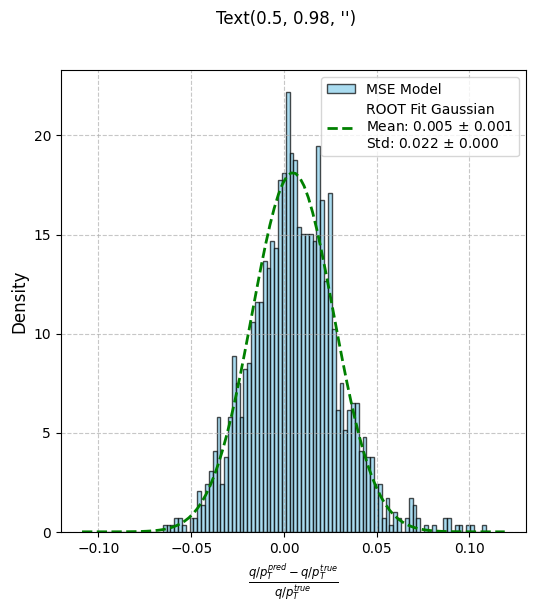

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning:

overflow encountered in reduce



Likelihood Curve Fit MSE: inf
Likelihood ROOT Fit MSE: inf
99.9999% quantile for MSE: 10.068512890315157
0.00010000000000331966% quantile for MSE: -40.76371974550774
Pruned fit for MSE: (-0.0058360922702079335, 0.08296543182062242)
MSE fit: mean_fit = -0.0028526512885823697 +/- mean_fit_err = 0.0015994052206957355 sigma_fit = 0.04594080642932779 +/- sigma_fit_err = 0.002769223365469347


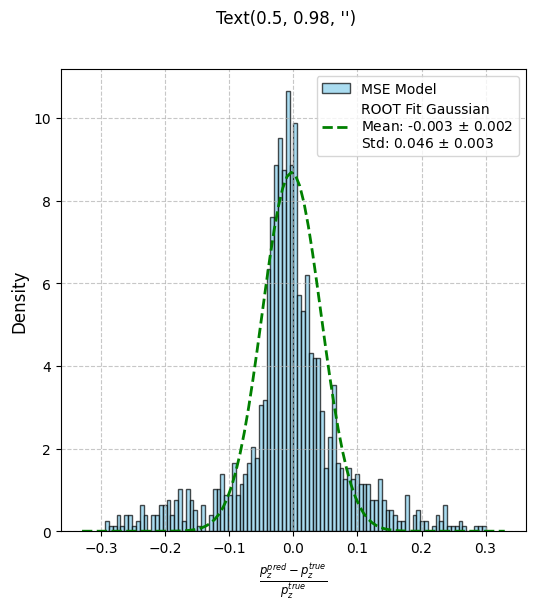

Likelihood Curve Fit MSE: 0.0
Likelihood ROOT Fit MSE: 0.0
99.9999% quantile for MSE: 0.10926440526820577
0.00010000000000331966% quantile for MSE: -0.09804332026384513
Pruned fit for MSE: (-0.005368834217109128, 0.023473709821061586)
MSE fit: mean_fit = -0.004599226699290772 +/- mean_fit_err = 0.0006159908357156648 sigma_fit = 0.022072889810112788 +/- sigma_fit_err = 0.0005023619222820821


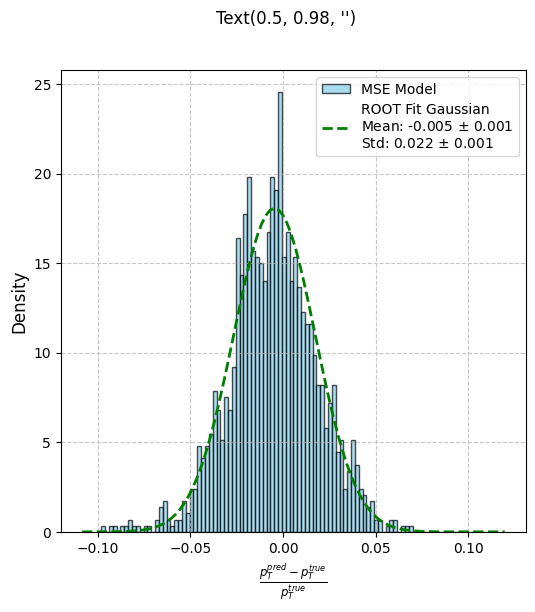

Likelihood Curve Fit MSE: inf
Likelihood ROOT Fit MSE: inf
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      72.8638
NDf                       =           69
Edm                       =  5.15021e-06
NCalls                    =           61
Constant                  =    0.0356999   +/-   0.0012474   
Mean                      =   0.00480522   +/-   0.000611482 
Sigma                     =     0.022013   +/-   0.000493696  	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      310.819
NDf                       =           90
Edm                       =  1.22368e-07
NCalls                    =          100
Constant                  =    0.0398213   +/-   0.00269874  
Mean                      =  -0.00285265   +/-   0.00159941  
Sigma                     =    0.0459408   +/-   0.00276922   	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning:

overflow encountered in reduce

Info in <TCanvas::MakeDefCanvas>:  created default TCanvas with name c1


In [59]:
plot_pi_relative_error_distributions_low_pt_1_2(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    publication=publication,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions_low_pt_1_2(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        publication=publication,
    )

99.9999% quantile for MSE: 0.10153895328896961
0.00010000000000331966% quantile for MSE: -0.06396078425853147
Pruned fit for MSE: (0.004314379525670554, 0.023215395080895342)
MSE fit: mean_fit = 0.0045949506196638614 +/- mean_fit_err = 0.0010332533868123027 sigma_fit = 0.021294565135272923 +/- sigma_fit_err = 0.0010289598006354914


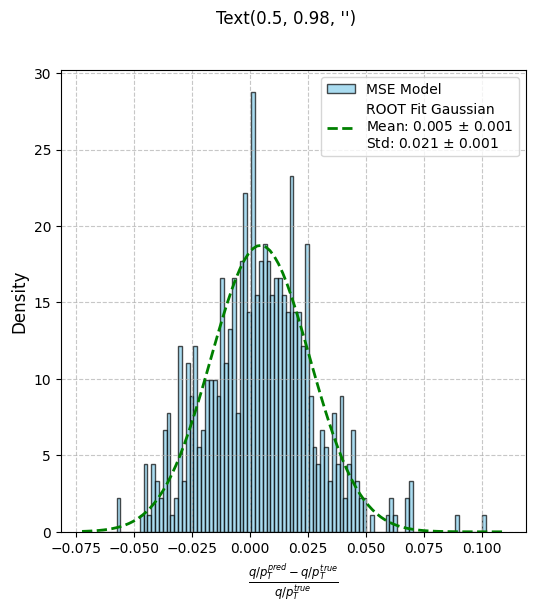

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning:

overflow encountered in reduce



Likelihood Curve Fit MSE: inf
Likelihood ROOT Fit MSE: inf
99.9999% quantile for MSE: 6.366303249941726
0.00010000000000331966% quantile for MSE: -11.278871995052196
Pruned fit for MSE: (-0.03968859375954973, 0.09254601262949105)
MSE fit: mean_fit = -0.02662257852059923 +/- mean_fit_err = 0.003918438180049985 sigma_fit = 0.0641773644920039 +/- sigma_fit_err = 0.005205400684925553


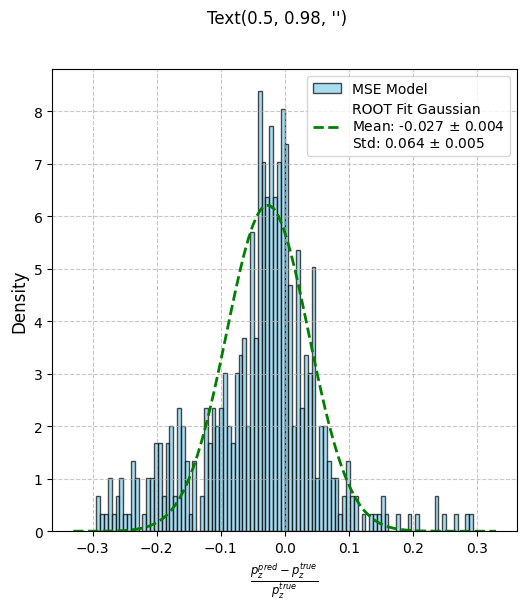

Likelihood Curve Fit MSE: 0.0
Likelihood ROOT Fit MSE: 0.0
99.9999% quantile for MSE: 0.06833133870246273
0.00010000000000331966% quantile for MSE: -0.09217917524675888
Pruned fit for MSE: (-0.00376596732639012, 0.022937425870006217)
MSE fit: mean_fit = -0.004195539069398312 +/- mean_fit_err = 0.001009110876443733 sigma_fit = 0.02075349733932364 +/- sigma_fit_err = 0.001004066525084401


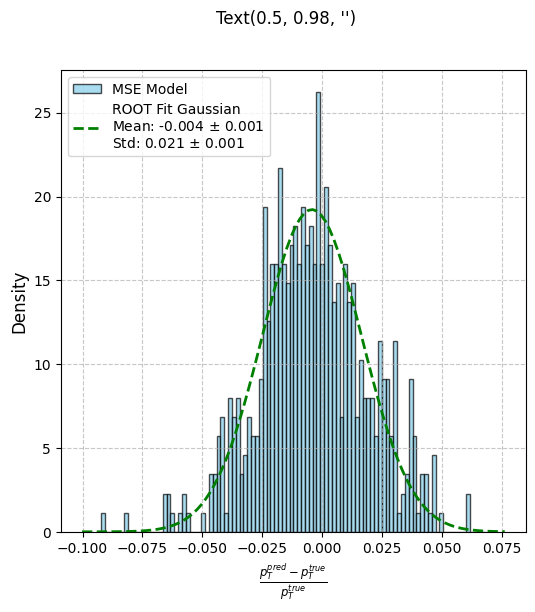

Likelihood Curve Fit MSE: inf
Likelihood ROOT Fit MSE: inf
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      72.6092
NDf                       =           64
Edm                       =  8.30452e-07
NCalls                    =           69
Constant                  =    0.0272864   +/-   0.00172712  
Mean                      =   0.00459495   +/-   0.00103325  
Sigma                     =    0.0212946   +/-   0.00102896   	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      133.319
NDf                       =           77
Edm                       =  3.41632e-08
NCalls                    =           88
Constant                  =    0.0277238   +/-   0.00257783  
Mean                      =   -0.0266226   +/-   0.00391844  
Sigma                     =    0.0641774   +/-   0.0052054    	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning:

overflow encountered in reduce

Warning in <TROOT::Append>: Replacing existing TH1: hist_MSE_p_z (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hist_MSE_p_T (Potential memory leak).


In [60]:
plot_pi_relative_error_distributions_low_pt_1_2(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    eta_range=(0, 1.0),
    publication=publication,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions_low_pt_1_2(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        eta_range=(0, 1.0),
        publication=publication,
    )

99.9999% quantile for MSE: 0.09567859524241608
0.00010000000000331966% quantile for MSE: -0.04620324590225493
Pruned fit for MSE: (0.007947363915496415, 0.01918358646621351)
MSE fit: mean_fit = 0.008677527359595833 +/- mean_fit_err = 0.003207004260552897 sigma_fit = 0.025208277458174052 +/- sigma_fit_err = 0.0042808253561969056


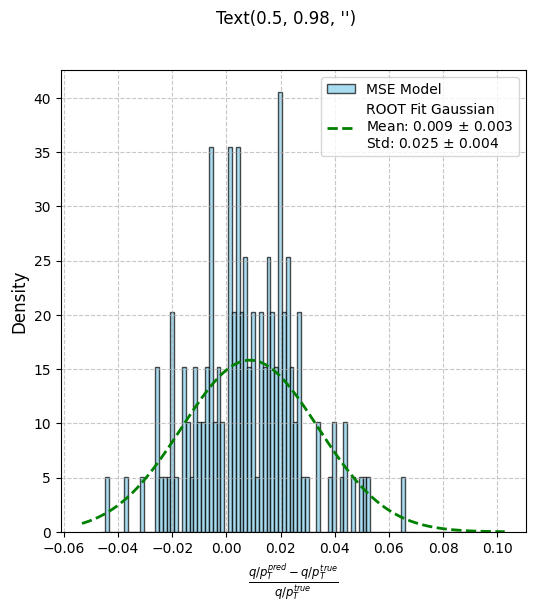

Likelihood Curve Fit MSE: 4.572568503589005e+148
Likelihood ROOT Fit MSE: 9.758035573740336e+147
99.9999% quantile for MSE: 0.05919040958566517
0.00010000000000331966% quantile for MSE: -0.08031433500788826
Pruned fit for MSE: (-0.01677486409062679, 0.02350762478847075)
MSE fit: mean_fit = -0.021779267919112673 +/- mean_fit_err = 0.006442890315072084 sigma_fit = 0.038771404287491595 +/- sigma_fit_err = 0.009985439737908027


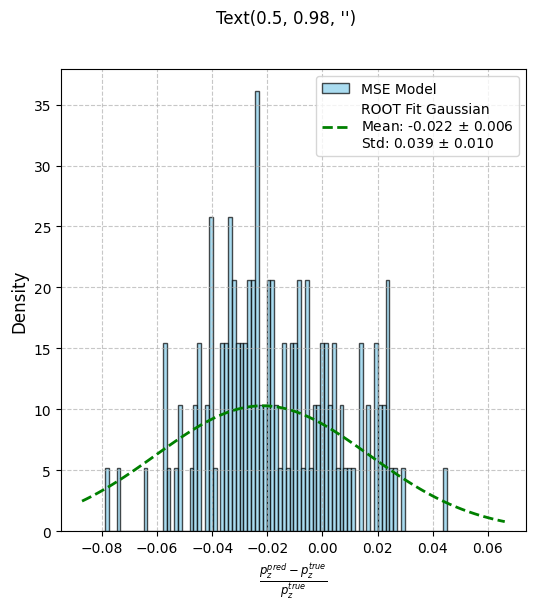

Likelihood Curve Fit MSE: 1.1918776304557479e+139
Likelihood ROOT Fit MSE: 5.0972968177366384e+129
99.9999% quantile for MSE: 0.04844139613300066
0.00010000000000331966% quantile for MSE: -0.08732349726264153
Pruned fit for MSE: (-0.007525714730125101, 0.01886934474955415)
MSE fit: mean_fit = -0.0056425859141496365 +/- mean_fit_err = 0.003031537036154503 sigma_fit = 0.023668062894900133 +/- sigma_fit_err = 0.004219947922647297


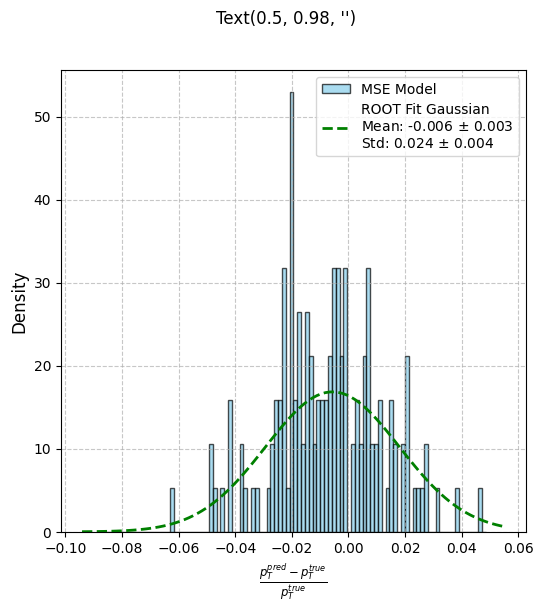

Likelihood Curve Fit MSE: 1.76618802953668e+150
Likelihood ROOT Fit MSE: 7.501266696360472e+149
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      31.6101
NDf                       =           48
Edm                       =  4.02822e-07
NCalls                    =           86
Constant                  =    0.0222198   +/-   0.00305505  
Mean                      =   0.00867753   +/-   0.003207    
Sigma                     =    0.0252083   +/-   0.00428083   	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      30.8065
NDf                       =           53
Edm                       =  3.38949e-10
NCalls                    =          104
Constant                  =    0.0167198   +/-   0.00225064  
Mean                      =   -0.0217793   +/-   0.00644289  
Sigma                     =    0.0387714   +/-   0.00998544   	 (limited)
**************************************

Warning in <TROOT::Append>: Replacing existing TH1: hist_MSE_p_z (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hist_MSE_p_T (Potential memory leak).


In [61]:
plot_pi_relative_error_distributions_low_pt_1_2(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    eta_range=(1.0, 2.0),
    publication=publication,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions_low_pt_1_2(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        eta_range=(1.0, 2.0),
        publication=publication,
    )

99.9999% quantile for MSE: 0.05018170522461565
0.00010000000000331966% quantile for MSE: -0.09854815799720033
Pruned fit for MSE: (-0.011048656615534818, 0.02399163895381443)
MSE fit: mean_fit = -0.031004437994281007 +/- mean_fit_err = 0.19957018929581646 sigma_fit = 0.11227897045206928 +/- sigma_fit_err = 0.1438366725519002


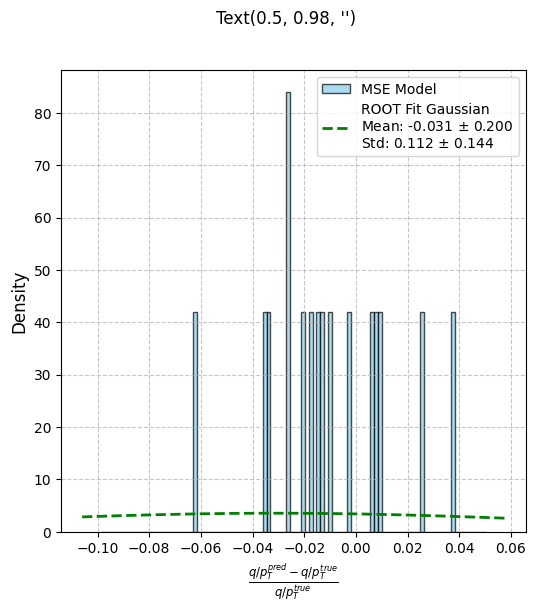

Likelihood Curve Fit MSE: 23416718063098.7
Likelihood ROOT Fit MSE: 2821661821.7399397
99.9999% quantile for MSE: 0.11650467564048723
0.00010000000000331966% quantile for MSE: -0.05440902100631087
Pruned fit for MSE: (-0.005627162960850751, 0.02491566866236112)
MSE fit: mean_fit = 0.008796009694505473 +/- mean_fit_err = 0.13981580909192984 sigma_fit = 0.10360916987313788 +/- sigma_fit_err = 0.16460794420254812


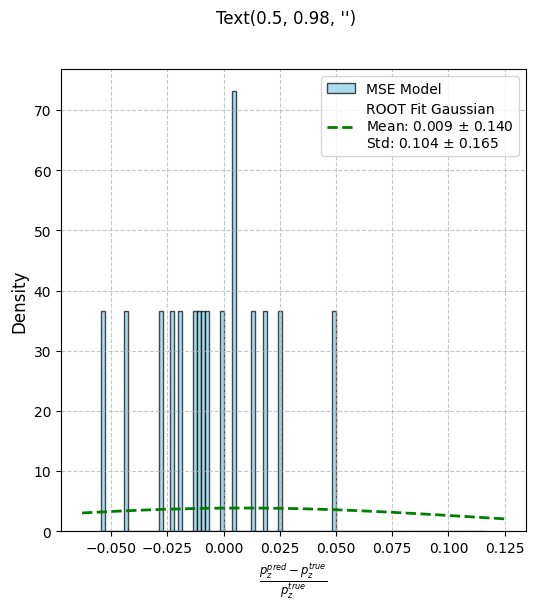

Likelihood Curve Fit MSE: 57976096845.23498
Likelihood ROOT Fit MSE: 9025681180.44656
99.9999% quantile for MSE: 0.10932162980363634
0.00010000000000331966% quantile for MSE: -0.047783828538976836
Pruned fit for MSE: (0.011767359160678805, 0.0245510248779435)
MSE fit: mean_fit = 0.024832597930445795 +/- mean_fit_err = 0.06690167469032349 sigma_fit = 0.07276668756731722 +/- sigma_fit_err = 0.14265842344237722


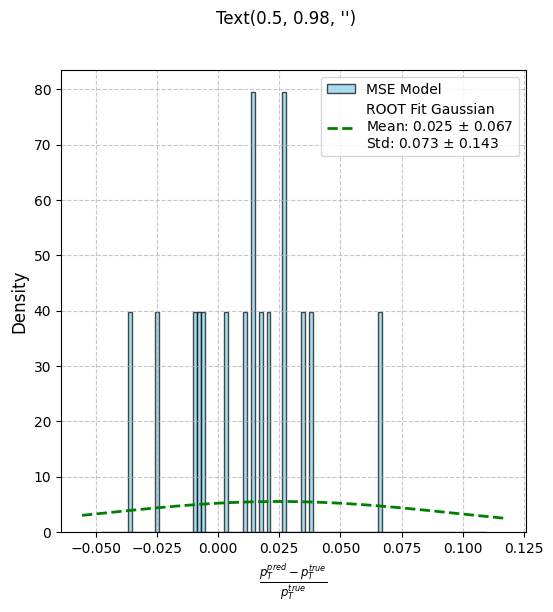

Likelihood Curve Fit MSE: 4739187171623.378
Likelihood ROOT Fit MSE: 1927893823985.9607
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =     0.466108
NDf                       =           11
Edm                       =  1.22836e-05
NCalls                    =          142
Constant                  =    0.0668574   +/-   0.0241004   
Mean                      =   -0.0310044   +/-   0.19957     
Sigma                     =     0.112279   +/-   0.143837     	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =     0.465704
NDf                       =           11
Edm                       =  2.31277e-06
NCalls                    =          114
Constant                  =    0.0668949   +/-   0.0242686   
Mean                      =   0.00879601   +/-   0.139816    
Sigma                     =     0.103609   +/-   0.164608     	 (limited)
****************************************
Minim

Warning in <TROOT::Append>: Replacing existing TH1: hist_MSE_p_z (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hist_MSE_p_T (Potential memory leak).


In [62]:
plot_pi_relative_error_distributions_low_pt_1_2(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    p_true_list=p_true_list,
    models=models,
    config=config,
    title_suffix=title_suffix,
    output_dir=output_dir,
    variable_filenames=variable_filenames,
    eta_range=(2.0, 3.0),
    publication=publication,
)

if config["output_variables"][0] in ["qopT", "qpT"]:
    plot_pi_relative_error_distributions_low_pt_1_2(
        target_labels=["p_T"],
        p_true_list=p_true_list,
        models=models,
        config=config,
        title_suffix=title_suffix,
        output_dir=output_dir,
        variable_filenames=variable_filenames,
        eta_range=(2.0, 3.0),
        publication=publication,
    )

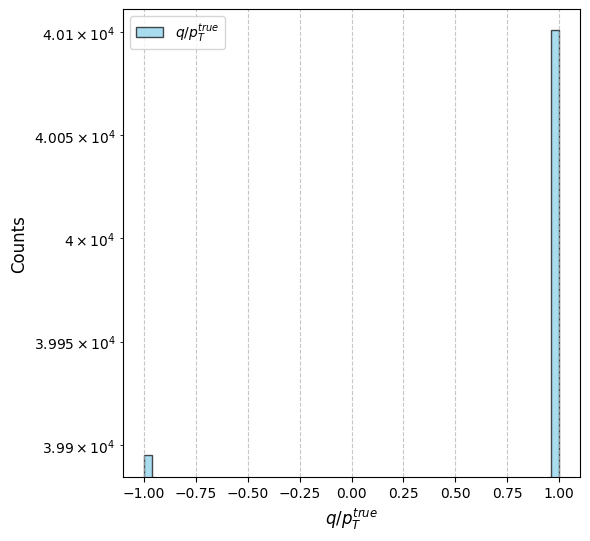

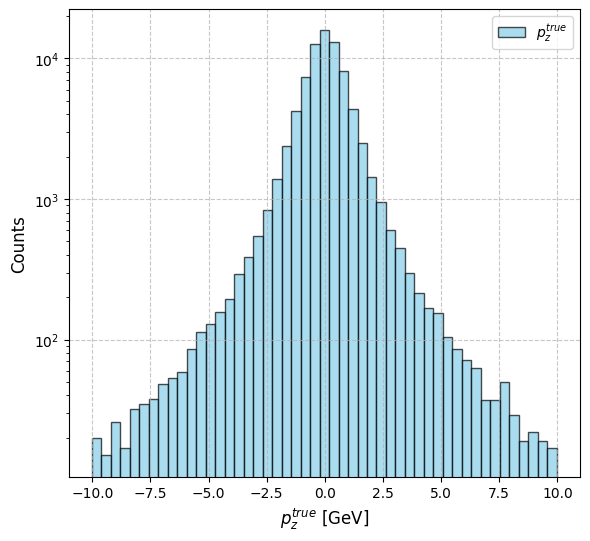

In [63]:
def plot_alone_pi(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        title = f"${var}^{{true}}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        filename = f"{variable_filenames[var]}_true.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(6, 6))

        bins = np.linspace(
            min(pi_true_values),
            max(pi_true_values),
            50,
        )

        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        # plt.title(title)
        plt.legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_alone_pi(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)

In [64]:
def plot_pi(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        title = f"${var}^{{true}}$ and ${var}^{{pred}}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"${var}$" + (" [GeV]" if var.startswith("p") else "")
        filename = (
            f"{variable_filenames[var]}_true_and_{variable_filenames[var]}_pred.png"
        )
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(6*len(models), 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            min(min(pi_true_values), min(pi_pred_mse_list), min(pi_pred_qloss_list)),
            max(
                max(pi_true_values),
                max(pi_pred_mse_list),
                max(pi_pred_qloss_list),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_mse_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_qloss_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi(target_labels=[variable_labels[var] for var in config["output_variables"]])

NameError: name 'p_pred_mse_list' is not defined

In [ ]:
def plot_pi_cdf(target_labels):
    """Plot CDF of p_T and p_z"""
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        title = f"CDF of ${var}^{{true}}$ and ${var}^{{pred}}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"CDF of ${var}$"
        filename = (
            f"{variable_filenames[var]}_true_and_{variable_filenames[var]}_pred_cdf.png"
        )
        filename = output_dir / filename

        # Import necessary CDF function
        from scipy.stats import norm

        pi_true_values_cdf = np.sort(pi_true_values)
        pi_pred_mse_list_cdf = np.sort(pi_pred_mse_list)
        pi_pred_qloss_list_cdf = np.sort(pi_pred_qloss_list)

        pi_true_values_cdf_ = np.linspace(0, 1, len(pi_true_values_cdf))
        pi_pred_mse_list_cdf_ = np.linspace(0, 1, len(pi_pred_mse_list_cdf))
        pi_pred_qloss_list_cdf_ = np.linspace(0, 1, len(pi_pred_qloss_list_cdf))

        pi_true_values_cdf = norm.ppf(pi_true_values_cdf_)
        pi_pred_mse_list_cdf = norm.ppf(pi_pred_mse_list_cdf_)
        pi_pred_qloss_list_cdf = norm.ppf(pi_pred_qloss_list_cdf_)

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            min(min(pi_true_values), min(pi_pred_mse_list), min(pi_pred_qloss_list)),
            max(
                max(pi_true_values),
                max(pi_pred_mse_list),
                max(pi_pred_qloss_list),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_mse_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_qloss_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


# plot_pi_cdf(target_labels=[variable_labels[var] for var in config['output_variables']])

In [ ]:
def plot_log10_pi(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        title = f"$log10({var}^{{true}})$ and $log10({var}^{{pred}})$"
        title += title_suffix

        xlabel = f"$log10({var})$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        filename = f"log10_{variable_filenames[var]}_true_and_log10_{variable_filenames[var]}_pred.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            0,
            max(
                max(np.log10(pi_true_values)),
                max(np.log10(pi_pred_mse_list)),
                max(np.log10(pi_pred_qloss_list)),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            np.log10(pi_true_values),
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            np.log10(pi_pred_mse_list),
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            np.log10(pi_true_values),
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            np.log10(pi_pred_qloss_list),
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_log10_pi(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)

NameError: name 'p_true_list' is not defined

In [ ]:
import torch.nn.functional as F
from sklearn.utils import resample
from scipy.stats import bootstrap


def evaluate_models():
    # Initialize lists to store the MAE values
    m_transf_mae_pt = []
    m_transf_mae_pz = []
    q_transf_mae_pt = []
    q_transf_mae_pz = []

    pt_conf_mae_list = []
    batch_limit = 10
    epochs = 1
    for epoch in tqdm(range(epochs)):
        with torch.no_grad():
            for i, (input, mask, target) in enumerate(tqdm(tl)):
                if i >= batch_limit:
                    break
                # Transformer MSE
                pred1 = transf_mse_model(input, mask=mask)
                pt_mae1 = F.l1_loss(pred1[:, 0], target[:, 0])
                pz_mae1 = F.l1_loss(pred1[:, 1], target[:, 1])

                m_transf_mae_pt.append(pt_mae1.item())
                m_transf_mae_pz.append(pz_mae1.item())

                # Transformer Qloss
                pred2 = qloss_transf_tt_model(input, mask=mask)
                pt_mae2 = F.l1_loss(pred2[:, 0], target[:, 0])
                pz_mae2 = F.l1_loss(pred2[:, 1], target[:, 1])

                q_transf_mae_pt.append(pt_mae2.item())
                q_transf_mae_pz.append(pz_mae2.item())

                # conformal fitt squares
                # pt_conf_mae = conformal_mae(input, target)
                # pt_conf_mae_list.append(pt_conf_mae.item())

    # Convert lists to numpy arrays
    m_transf_mae_pt = np.array(m_transf_mae_pt)
    q_transf_mae_pt = np.array(q_transf_mae_pt)
    m_transf_mae_pz = np.array(m_transf_mae_pz)
    q_transf_mae_pz = np.array(q_transf_mae_pz)
    # pt_conf_mae_list = np.array(pt_conf_mae_list)

    def calculate_ci(data, confidence=0.95, n_resamples=1000):
        res = bootstrap(
            (data,),
            np.mean,
            confidence_level=confidence,
            n_resamples=n_resamples,
            method="percentile",
            random_state=42,
        )
        mean = np.mean(data)
        ci_lower = res.confidence_interval.low
        ci_upper = res.confidence_interval.high
        delta = (ci_upper - mean) / 2
        return mean, delta

    # confidence intervals
    transf_mse_pt_mean, transf_mse_pt_delta = calculate_ci(m_transf_mae_pt)
    transf_q_pt_mean, transf_q_pt_delta = calculate_ci(q_transf_mae_pt)
    transf_mse_pz_mean, transf_mse_pz_delta = calculate_ci(m_transf_mae_pz)
    transf_q_pz_mean, transf_q_pz_delta = calculate_ci(q_transf_mae_pz)
    # pt_conf_mean, pt_conf_delta = calculate_ci(pt_conf_mae_list)

    print(
        f"Transformer MSE PT MAE: {transf_mse_pt_mean:.4f} ± {transf_mse_pt_delta:.4f}"
    )
    print(f"Transformer Qloss PT MAE: {transf_q_pt_mean:.4f} ± {transf_q_pt_delta:.4f}")
    print(
        f"Transformer MSE PZ MAE: {transf_mse_pz_mean:.4f} ± {transf_mse_pz_delta:.4f}"
    )
    print(f"Transformer Qloss PZ MAE: {transf_q_pz_mean:.4f} ± {transf_q_pz_delta:.4f}")
    # print(f"Conformal MAE: {pt_conf_mean:.4f} ± {pt_conf_delta:.4f}")

    # Save the results to a file
    results = {}
    results["p_T"] = {
        "mse": (transf_mse_pt_mean, transf_mse_pt_delta),
        "qloss": (transf_q_pt_mean, transf_q_pt_delta),
    }
    results["p_z"] = {
        "mse": (transf_mse_pz_mean, transf_mse_pz_delta),
        "qloss": (transf_q_pz_mean, transf_q_pz_delta),
    }
    # results["conformal"] = (pt_conf_mean, pt_conf_delta)

    with open(output_dir / "mae_results.json", "w") as f:
        json.dump(results, f)


evaluate_models()

  0%|          | 0/1 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Transformer MSE PT MAE: 0.4409 ± 0.1944
Transformer Qloss PT MAE: 0.1949 ± 0.0778
Transformer MSE PZ MAE: 1.3537 ± 0.5189
Transformer Qloss PZ MAE: 0.7749 ± 0.2834

Transformer MSE PT MAE: 0.5884 ± 0.2166
Transformer Qloss PT MAE: 0.1474 ± 0.0739
Transformer MSE PZ MAE: 1.3716 ± 0.3525
Transformer Qloss PZ MAE: 0.6085 ± 0.1636

Transformer MSE PT MAE: 0.0869 ± 0.0125

Transformer Qloss PT MAE: 0.0959 ± 0.0147

Transformer MSE PZ MAE: 0.0543 ± 0.0083

Transformer Qloss PZ MAE: 0.0512 ± 0.0085

In [ ]:
from tbparse import SummaryReader


def plot_tensorboard(log_dir: Path, model_name: str):
    log_name = log_dir.name + "_" + model_name

    reader = SummaryReader(log_dir, extra_columns={"dir_name"}, pivot=False)
    # reader = SummaryReader(log_dir)
    df = reader.scalars
    print(df)

    df["unique_tag"] = df["dir_name"] + "/" + df["tag"]

    # Get the unique tags
    unique_tags = df["tag"].unique()

    print(unique_tags)

    # Extract values for each tag
    unique_tags_dfs = {}
    for tag in unique_tags:
        unique_tags_dfs[tag] = df[df["tag"] == tag].reset_index(drop=True)

        print(unique_tags_dfs[tag])

    for tag in unique_tags:
        # if not "loss" in unique_tags_dfs[tag]
        plt.figure()
        for dir_name in unique_tags_dfs[tag]["dir_name"].unique():
            dir_name_sel = unique_tags_dfs[tag]["dir_name"] == dir_name

            dir_df = unique_tags_dfs[tag][dir_name_sel]
            # Group by step and take the mean and std
            dir_df = dir_df.groupby("step").agg({"value": ["mean", "std"]})
            # dir_df.columns = dir_df.columns.droplevel(0)
            dir_df.reset_index(inplace=True)
            plt.errorbar(
                x=dir_df["step"],
                y=dir_df["value"]["mean"],
                label=dir_name,
                alpha=0.7,
                yerr=dir_df["value"]["std"],
            )
        # sns.lineplot(data=unique_tags_dfs[tag], x="step", y="value")
        # plt.title(tag)
        plt.xlabel("Step")
        plt.ylabel(tag.capitalize())
        plt.legend()
        plt.grid(True)
        title = f"{model_name} {tag}"
        title += title_suffix
        plt.title(title)
        plt.savefig(output_dir / (tag + "_" + log_name + ".png"), format="png")

    tag = "loss"
    plt.figure()
    for dir_name in unique_tags_dfs[tag]["dir_name"].unique():
        dir_name_sel = unique_tags_dfs[tag]["dir_name"] == dir_name

        dir_df = unique_tags_dfs[tag][dir_name_sel]
        # Group by step and take the mean and std
        dir_df = dir_df.groupby("step").agg({"value": ["mean", "std"]})
        # dir_df.columns = dir_df.columns.droplevel(0)
        dir_df.reset_index(inplace=True)
        plt.errorbar(
            x=dir_df["step"],
            y=dir_df["value"]["mean"],
            label=dir_name,
            alpha=0.7,
            yerr=dir_df["value"]["std"],
        )
    # sns.lineplot(data=unique_tags_dfs[tag], x="step", y="value")
    # plt.title(tag)
    plt.xlabel("Step")
    plt.ylabel(tag.capitalize())
    plt.yscale("log")
    plt.legend()
    plt.grid(True)
    title = f"{model_name} {tag}"
    title += title_suffix
    plt.title(title)
    plt.savefig(output_dir / ("loss_log_" + log_name + ".png"), format="png")
    plt.show()

    tag = "loss"
    plt.figure()
    for dir_name in unique_tags_dfs[tag]["dir_name"].unique():
        dir_name_sel = unique_tags_dfs[tag]["dir_name"] == dir_name

        dir_df = unique_tags_dfs[tag][dir_name_sel]
        # Group by step and take the mean and std
        dir_df = dir_df.groupby("step").agg({"value": ["mean", "std"]})
        # dir_df.columns = dir_df.columns.droplevel(0)
        dir_df.reset_index(inplace=True)
        plt.errorbar(
            x=dir_df["step"],
            y=dir_df["value"]["mean"],
            label=dir_name,
            alpha=0.7,
            yerr=dir_df["value"]["std"],
        )
    # sns.lineplot(data=unique_tags_dfs[tag], x="step", y="value")
    # plt.title(tag)
    plt.xlabel("Step")
    plt.ylabel(tag.capitalize())
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)
    title = f"{model_name} {tag}"
    title += title_suffix
    plt.title(title)
    plt.savefig(output_dir / ("loss_log_log_" + log_name + ".png"), format="png")
    plt.show()

2025-03-03 11:52:27.286139: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-03 11:52:27.313836: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


         step       tag     value  dir_name
0           0  lr-AdamW  0.000000          
1           1  lr-AdamW  0.000005          
2           2  lr-AdamW  0.000010          
3           3  lr-AdamW  0.000015          
4           4  lr-AdamW  0.000020          
...       ...       ...       ...       ...
130697  61500      loss  0.006106  loss_val
130698  61500      loss  0.002739  loss_val
130699  61500      loss  0.003647  loss_val
130700  61500      loss  0.002778  loss_val
130701  61500      loss  0.002521  loss_val

[130702 rows x 4 columns]
['lr-AdamW' 'loss']
        step       tag         value dir_name unique_tag
0          0  lr-AdamW  0.000000e+00           /lr-AdamW
1          1  lr-AdamW  5.000000e-06           /lr-AdamW
2          2  lr-AdamW  1.000000e-05           /lr-AdamW
3          3  lr-AdamW  1.500000e-05           /lr-AdamW
4          4  lr-AdamW  2.000000e-05           /lr-AdamW
...      ...       ...           ...      ...        ...
61495  61495  lr-AdamW  8.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  mi

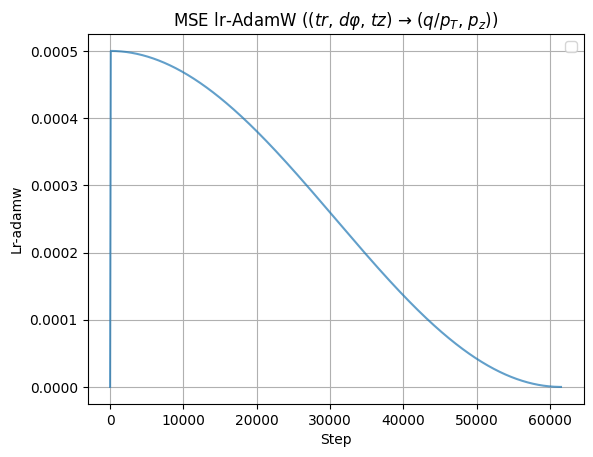

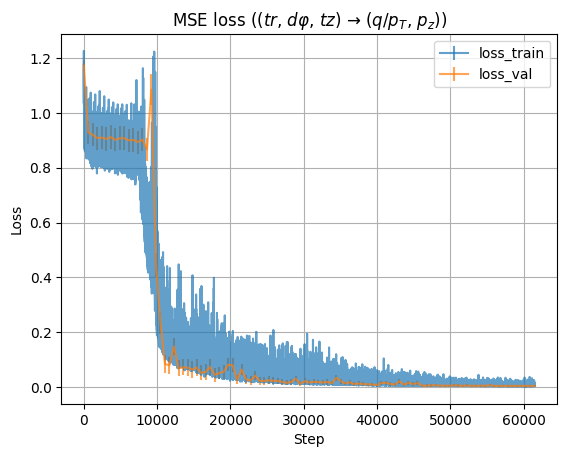

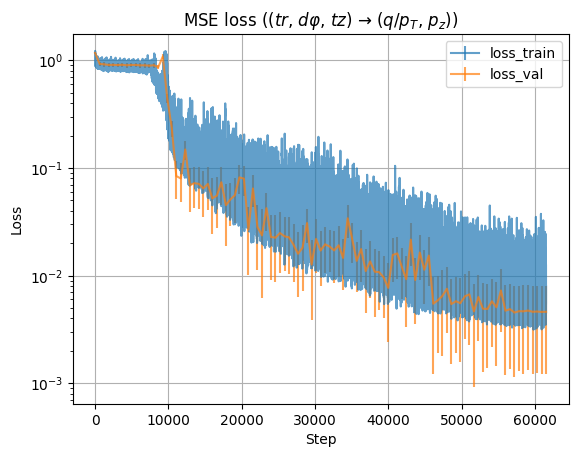

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


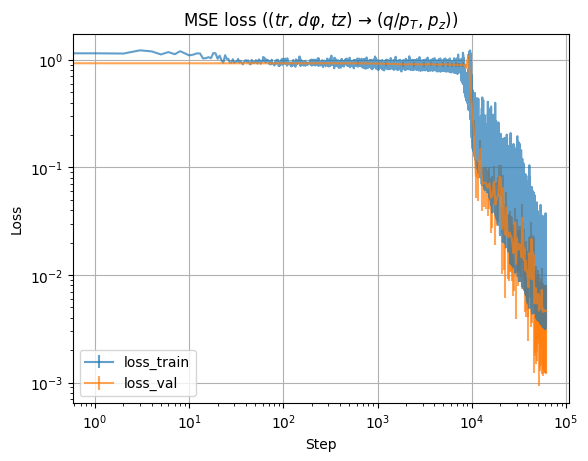

         step       tag     value  dir_name
0           0  lr-AdamW  0.000000          
1           1  lr-AdamW  0.000005          
2           2  lr-AdamW  0.000010          
3           3  lr-AdamW  0.000015          
4           4  lr-AdamW  0.000020          
...       ...       ...       ...       ...
130697  61500      loss  0.020743  loss_val
130698  61500      loss  0.018409  loss_val
130699  61500      loss  0.019451  loss_val
130700  61500      loss  0.018525  loss_val
130701  61500      loss  0.018288  loss_val

[130702 rows x 4 columns]
['lr-AdamW' 'loss']
        step       tag         value dir_name unique_tag
0          0  lr-AdamW  0.000000e+00           /lr-AdamW
1          1  lr-AdamW  5.000000e-06           /lr-AdamW
2          2  lr-AdamW  1.000000e-05           /lr-AdamW
3          3  lr-AdamW  1.500000e-05           /lr-AdamW
4          4  lr-AdamW  2.000000e-05           /lr-AdamW
...      ...       ...           ...      ...        ...
61495  61495  lr-AdamW  8.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  mi

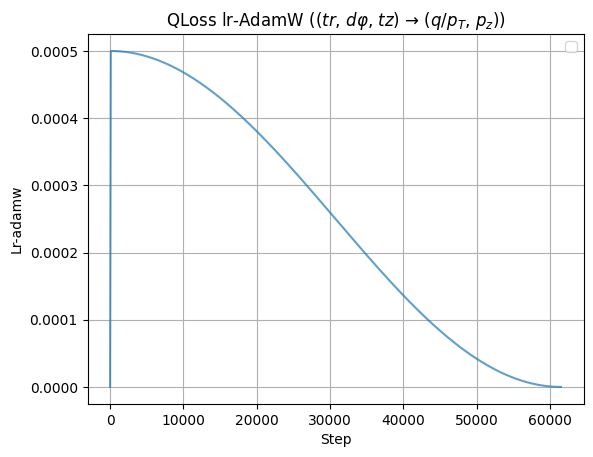

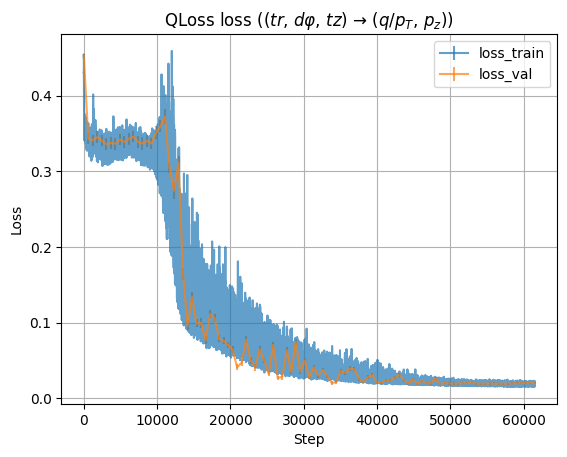

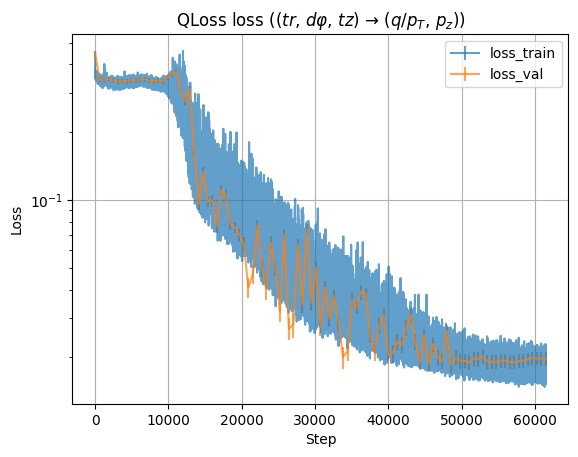

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


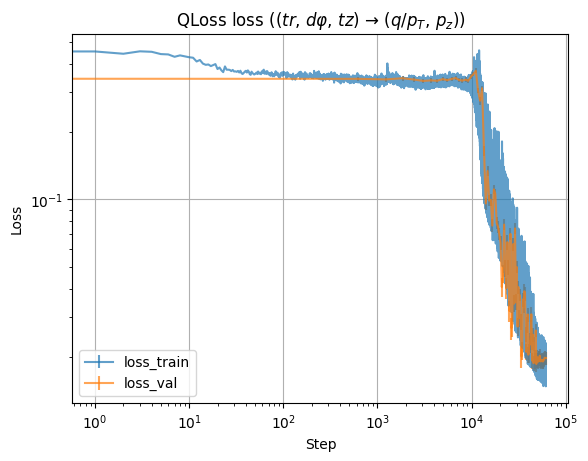

         step       tag     value  dir_name
0           0  lr-AdamW  0.000000          
1           1  lr-AdamW  0.000005          
2           2  lr-AdamW  0.000010          
3           3  lr-AdamW  0.000015          
4           4  lr-AdamW  0.000020          
...       ...       ...       ...       ...
130697  61500      loss  0.007121  loss_val
130698  61500      loss  0.004108  loss_val
130699  61500      loss  0.004909  loss_val
130700  61500      loss  0.003833  loss_val
130701  61500      loss  0.003579  loss_val

[130702 rows x 4 columns]
['lr-AdamW' 'loss']
        step       tag         value dir_name unique_tag
0          0  lr-AdamW  0.000000e+00           /lr-AdamW
1          1  lr-AdamW  5.000000e-06           /lr-AdamW
2          2  lr-AdamW  1.000000e-05           /lr-AdamW
3          3  lr-AdamW  1.500000e-05           /lr-AdamW
4          4  lr-AdamW  2.000000e-05           /lr-AdamW
...      ...       ...           ...      ...        ...
61495  61495  lr-AdamW  8.

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  mi

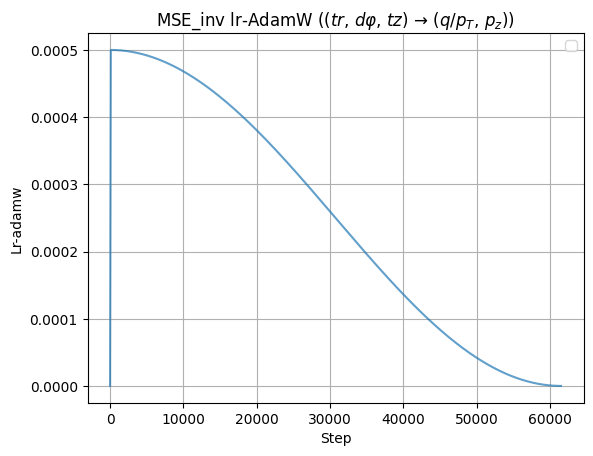

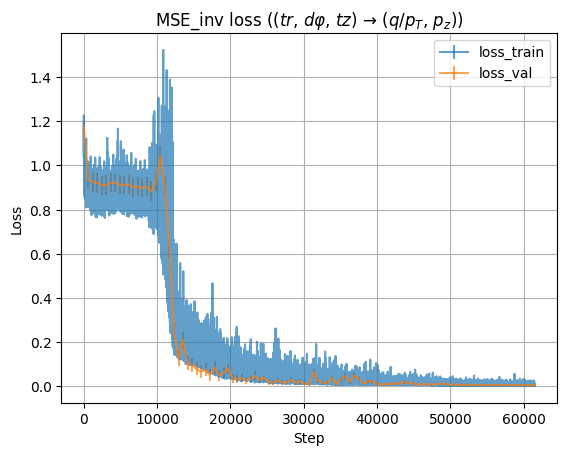

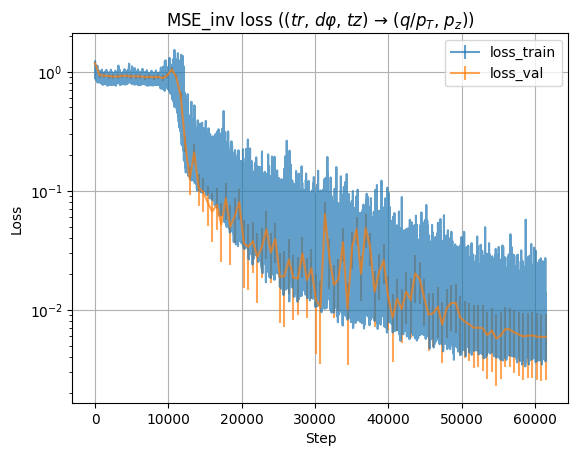

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


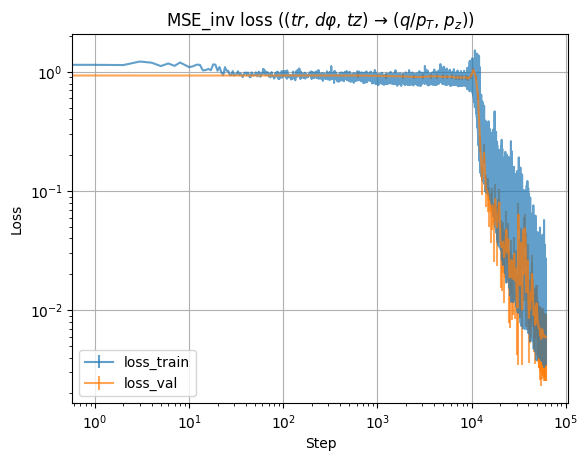

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

for model_name in models_dir:
    log_dir = models_dir[model_name]
    plot_tensorboard(log_dir, model_name=model_name)

In [ ]:
batch_limit = 10
epochs = 1
attention_sum_mse = []
for epoch in tqdm(range(epochs)):
    with torch.no_grad():
        for i, (input, _, target) in enumerate(tqdm(tl)):
            if i >= batch_limit:
                break
            # Transformer MSE
            # Output shape: (n_layers, batch_size, n_heads, seq_len, seq_len)
            pred1 = transf_mse_model.get_attention_maps(input)
            # print(pred1.shape)
            # print(pred1)
            print(pred1[0].shape)
            # pt_mae1 = F.l1_loss(pred1[:, 0], target[:, 0])
            # pz_mae1 = F.l1_loss(pred1[:, 1], target[:, 1])

            # m_transf_mae_pt.append(pt_mae1.item())
            # m_transf_mae_pz.append(pz_mae1.item())

            # Add the attention maps to the attention_sum
            if len(attention_sum_mse) == 0:
                # Initialize the attention_sum to zeros with shape torch.Size([32, 4, 18, 18])
                # attention_sum_mse = [torch.zeros']

                attention_sum_mse = [torch.zeros_like(att) for att in pred1]
            for j, att in enumerate(pred1):
                attention_sum_mse[j] += att

            # Transformer Qloss
            pred2 = qloss_transf_tt_model.get_attention_maps(input)
            # print(pred2.shape)
            # print(pred2)
            # pt_mae2 = F.l1_loss(pred2[:, 0], target[:, 0])
            # pz_mae2 = F.l1_loss(pred2[:, 1], target[:, 1])

            # q_transf_mae_pt.append(pt_mae2.item())
            # q_transf_mae_pz.append(pz_mae2.item())

            # conformal fitt squares
            # pt_conf_mae = conformal_mae(input, target)
            # pt_conf_mae_list.append(pt_conf_mae.item())

In [ ]:
# Plot the attention maps
plt.figure(figsize=(12, 6))
plt.suptitle("Attention Maps", fontsize=16)

pred1 = attention_sum_mse

# MSE Model
for layer in range(len(pred1)):
    for i in range(pred1[0].shape[1]):
        plt.subplot(len(pred1), pred1[0].shape[1], layer * pred1[0].shape[1] + i + 1)
        # Plot the head with matplotlib
        # Do a mean over the batch size
        mean_attention = pred1[layer].mean(dim=0)[i].numpy()
        print(pred1[layer].mean(dim=0).shape)
        plt.imshow(mean_attention, cmap="viridis", origin="lower")
        # Add the colorbar
        plt.colorbar()
        plt.title(f"Layer {layer}, Head {i}")
plt.title("MSE Model")

# # Qloss
# plt.subplot(1, 2, 2)
# # Plot the first
# plt.imshow(pred2[0][0, 0].numpy(), cmap="viridis", origin="lower")
# plt.title("Quantile Loss Model")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [20]:
all_inputs = []
all_targets = []
all_input_masks = []
# batch_limit = 2400
batch_limit = 7000
# batch_limit = None
# batch_limit = 6730
for i, (input, masks, target) in enumerate(tqdm(tl)):
    # Reshape the input and target to shape (n_features, batch_size, seq_len)
    input = input.permute(2, 0, 1)
    target = target.permute(1, 0)

    all_inputs.append(input)
    all_targets.append(target)
    all_input_masks.append(masks)
    if batch_limit is not None and i >= batch_limit:
        break

0it [00:00, ?it/s]

In [21]:
# print(all_inputs[0][0])

In [22]:
# Concatenate all the inputs and targets
all_inputs = torch.cat(all_inputs, dim=2)
all_targets = torch.cat(all_targets, dim=1)
all_input_masks = torch.cat(all_input_masks, dim=1)


# Reshape the inputs to shape (n_features, batch_size * seq_len)
all_inputs = all_inputs.view(all_inputs.shape[0], -1)

# Reshape the masks to shape (batch_size * seq_len)
all_input_masks = all_input_masks.view(-1)

print(all_inputs.shape)
print(all_targets.shape)
print(all_input_masks.shape)

torch.Size([3, 3878976])
torch.Size([2, 224032])
torch.Size([3878976])


In [23]:
# # Print input and mask side by side
# for i in range(all_inputs.shape[1]):
#     print(all_inputs[:, i], all_input_masks[i])
#     if i == 100:
#         break

In [24]:
# Keep input only where mask is True
all_inputs = all_inputs[:, all_input_masks]
print(all_inputs.shape)

torch.Size([3, 3117673])


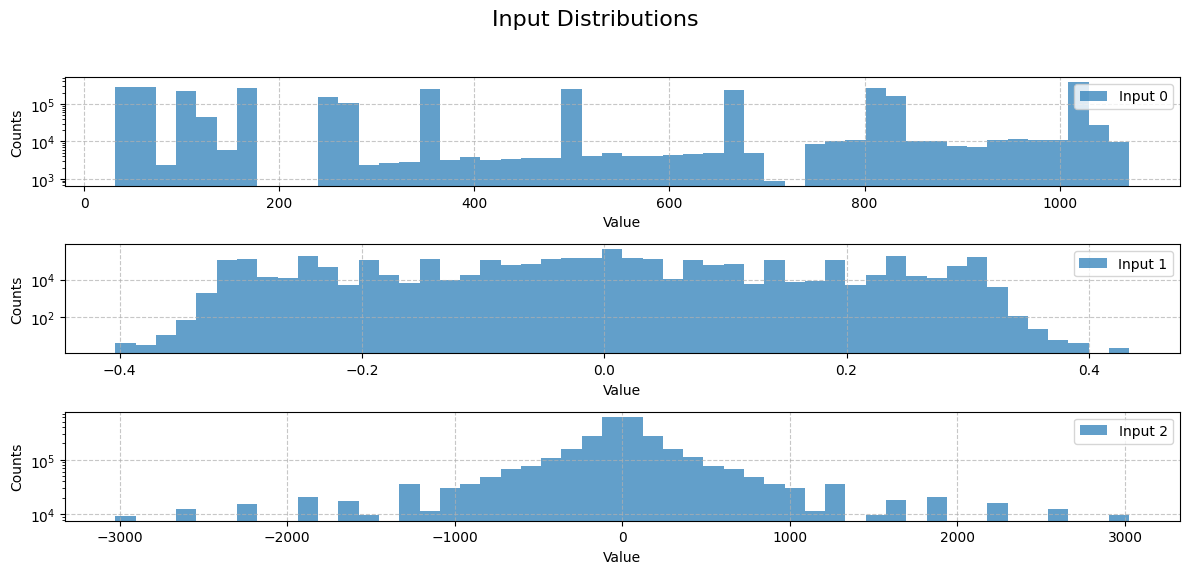

In [25]:
# Plot the distribution of the inputs
plt.figure(figsize=(12, 6))
plt.suptitle("Input Distributions", fontsize=16)

# Plot the inputs
for i in range(all_inputs.shape[0]):
    plt.subplot(all_inputs.shape[0], 1, i + 1)
    plt.hist(all_inputs[i].numpy().flatten(), bins=50, alpha=0.7, label=f"Input {i}")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "input_distributions.png", format="png")
plt.show()

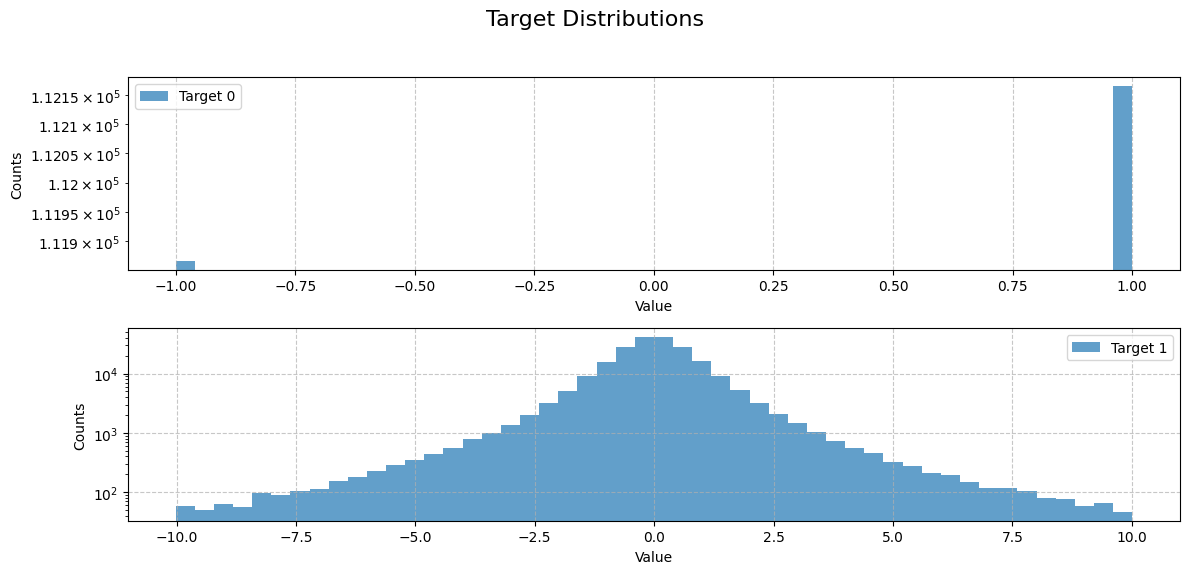

In [26]:
# Plot the distribution of the targets
plt.figure(figsize=(12, 6))
plt.suptitle("Target Distributions", fontsize=16)

# Plot the targets
for i in range(all_targets.shape[0]):
    plt.subplot(all_targets.shape[0], 1, i + 1)
    plt.hist(all_targets[i].numpy().flatten(), bins=50, alpha=0.7, label=f"Target {i}")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "target_distributions.png", format="png")
plt.show()

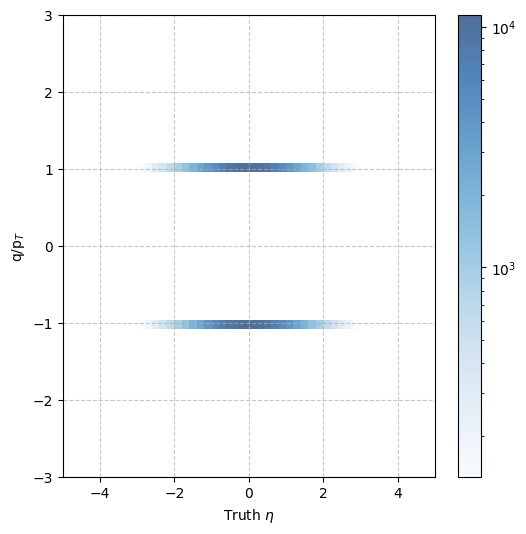

In [27]:
from matplotlib import colors

rho = np.sqrt(all_inputs[0].numpy()**2 + all_inputs[2].numpy()**2)
eta = np.arctanh(all_inputs[2].numpy() / rho)
p = np.sqrt((1/all_targets[0].numpy())**2 + all_targets[1].numpy()**2)
peta = np.arctanh(all_targets[1].numpy() / p)
plt.figure(figsize=(6, 6))
plt.hist2d(
    peta,
    all_targets[0].numpy(),
    bins=50,
    range=[[-5, 5], [-3, 3]],
    cmap="Blues",
    # cmin=0,
    # cmax=100,
    alpha=0.7,
    norm=colors.LogNorm(),
    label=f"Input {i}",
    density=False,
)
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"q/p$_T$")
# plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.title("Input Distributions")
plt.colorbar()
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(
    output_dir / "input_distributions_peta_qopT.png", format="png", bbox_inches="tight"
)
plt.show()

In [28]:
# Loop over each model
# var = "p_T"
pi_true_values = all_targets[0].numpy()
model_data = {}
for model_name, model_info in models.items():
    # Compute the relative error: (prediction - true)/true
    pi_pred_values = np.array(model_info["data_list"])[:, 0]
    # if var == "p_T":
    #     pi_pred_values = var_to_pT(
    #         values=pi_pred_values,
    #         from_var=config["output_variables"][var_index],
    #     )
    pi_pred_values = pi_pred_values[:len(pi_true_values)]
    errors = pi_pred_values - pi_true_values
    relative_errors = errors / pi_true_values
    # Apply the same pT mask
    # relative_errors = relative_errors[mask]

    # Convert to percentage
    relative_errors = relative_errors * 100

    model_data[model_name] = relative_errors

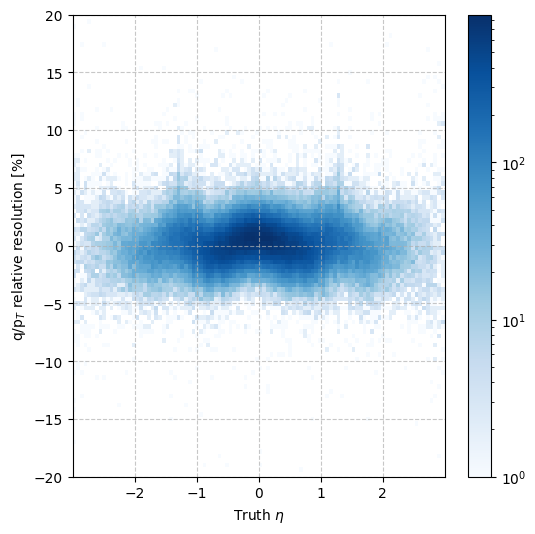

Results/ActsODD/rdphiz_n_hits_7_qopT_pz_POC_Acts_muons_eta_3_trained_ODD_full_e_128_h_2


In [29]:
from matplotlib import colors

plt.figure(figsize=(6, 6))
plt.hist2d(
    peta,
    model_data["MSE"],
    bins=100,
    # range=[[-5, 5], [-3, 3]],
    range=[None, [-20, 20]],
    # range=[None, [-50, 80]],
    cmap="Blues",
    # cmin=0,
    # cmax=100,
    norm=colors.LogNorm(),
    # alpha=0.7,
    label=f"Input {i}",
    density=False,
)
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"q/p$_T$ relative resolution [%]")
# plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.title("Input Distributions")
plt.colorbar()
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(
    output_dir / "input_distributions_2d_relative_error.png", format="png", bbox_inches="tight",
)
plt.show()
print(output_dir)

In [30]:
pi_true_values = all_targets[0].numpy()
model_data = {}
for model_name, model_info in models.items():
    # Compute the relative error: (prediction - true)/true
    pi_pred_values = np.array(model_info["data_list"])[:, 0]
    # if var == "p_T":
    #     pi_pred_values = var_to_pT(
    #         values=pi_pred_values,
    #         from_var=config["output_variables"][var_index],
    #     )
    pi_pred_values = pi_pred_values[:len(pi_true_values)]
    errors = pi_pred_values - pi_true_values
    relative_errors = errors / pi_true_values

    model_data[model_name] = pi_pred_values

In [31]:
# Make bins in peta
# bins = np.arange(-5, 5, 0.1)
bins = np.arange(-3, 3, 0.1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_means = []
bin_stds = []
bin_means_err = []
bin_stds_err = []
bin_counts = []
bin_edges = []
bin_pi_true_values = []

model_data_bins = {}
for model_name, model_info in models.items():
    model_data_bins[model_name] = []
# Loop over each bin
for i in range(len(bins) - 1):
    # Get the indices of the points in this bin
    bin_indices = np.where((peta >= bins[i]) & (peta < bins[i + 1]))[0]
    # Get the values in this bin
    pi_pred_values_bin = model_data["MSE"][bin_indices]
    pi_true_values_bin = pi_true_values[bin_indices]
    bin_values, removed_outliers_bin = (
                        compute_track_resolution(
                            pi_true_values_bin,
                            pi_pred_values_bin,
                        )
                    )
    # bin_values = pi_pred_values_bin - pi_true_values_bin
    # Compute the mean and std of the values in this bin
    n_bins = 100
    n, model_bins = np.histogram(
        bin_values, bins=n_bins, density=True#, range=fit_range
    )
    # Fit a Gaussian to the histogram.
    from scipy.stats import norm
    from scipy.optimize import curve_fit
    if not all(np.isnan(val) for val in n):
        param_model, cov_model = curve_fit(
            norm.pdf,
            model_bins[:-1],
            n,
            p0=[np.mean(bin_values), np.std(bin_values)],
            bounds=([-np.inf, 0], [np.inf, np.inf]),
        )
        perr_model = np.sqrt(np.diag(cov_model))
        model_mean, model_std = param_model
        model_mean_err, model_std_err = perr_model
    else:
        model_mean = np.nan
        model_std = np.nan
        model_mean_err = np.nan
        model_std_err = np.nan
    
    # bin_mean = np.mean(bin_values)
    # bin_std = np.std(bin_values)
    bin_mean = model_mean
    bin_std = model_std
    bin_mean_err = model_mean_err
    bin_std_err = model_std_err
    # Append to the lists
    bin_means.append(bin_mean)
    bin_stds.append(bin_std)
    bin_means_err.append(bin_mean_err)
    bin_stds_err.append(bin_std_err)
    bin_counts.append(len(bin_indices))
    bin_edges.append((bins[i], bins[i + 1]))
    bin_pi_true_values.append(np.mean(np.abs(1/pi_true_values_bin)))
    # Append the bin data to the model data
    model_data_bins["MSE"].append((bin_mean, bin_std, len(bin_indices), bin_pi_true_values[-1], bin_mean_err, bin_std_err))

# Convert to numpy arrays
bin_means = np.array(bin_means)
bin_stds = np.array(bin_stds)
bin_means_err = np.array(bin_means_err)
bin_stds_err = np.array(bin_stds_err)
bin_counts = np.array(bin_counts)
bin_edges = np.array(bin_edges)
bin_pi_true_values = np.array(bin_pi_true_values)

for model_name, model_info in models.items():
    # Get the data for this model
    model_data = model_data_bins[model_name]
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]

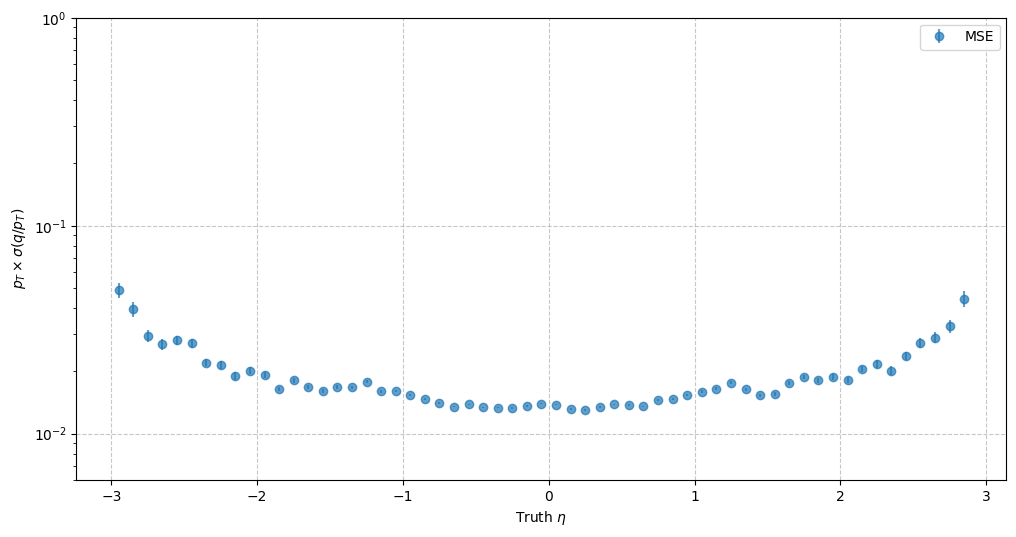

In [32]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name, model_info in models.items():
    # Get the data for this model
    model_data = model_data_bins[model_name]
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
plt.ylim(6e-3, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta.png", format="png", bbox_inches="tight"
)
plt.show()

In [19]:
from src.datasets.datamodules import parse_particle_id
from copy import deepcopy
all_events_tracks_list = []
all_events_processed = []
dataset_wrapper.test_dataset.truth_tracks = False
for i in range(len(dataset_wrapper.test_dataset.available_events)):
    event = dataset_wrapper.test_dataset.available_events[i]
    # print(f"Loading event {event}")
    event_files = dataset_wrapper.test_dataset._load_event(event)
    processed_event = dataset_wrapper.test_dataset._preprocessor(event_files=deepcopy(event_files))
    # print(f"{list(processed_event) = }")
    hits, tracks, particles = event_files
    tracks["particle_id"] = tracks["particleId"].apply(parse_particle_id)
    del tracks["particleId"]
    # print(f"{tracks = }")
    # print(f"{particles = }")
    # Count the number of hits per particle
    hit_particle_counts = hits.groupby("particle_id").size().to_frame(name="n_hits")
    # Add index as a column
    hit_particle_counts = hit_particle_counts.reset_index()
    # Merge the hit counts with the particles dataframe
    particles = particles.merge(hit_particle_counts, on="particle_id", how="left")
    # Add "_truth" suffix to the columns of the particles dataframe
    particles = particles.rename(columns=lambda x: f"{x}_truth" if x not in ["particle_id", "particle_type", "process"] else x)
    # print(f"{particles.columns = }")
    # Match the tracks with the particles
    tracks = tracks.merge(particles, on="particle_id", how="left", suffixes=("", "_truth"))
    processed_event = list(processed_event)
    print(f"{len(processed_event) = }")
    print(f"{len(tracks) = }")
    print(tracks["particle_type"].unique())
    print(min(tracks["n_hits_truth"].unique()))
    tracks["pT_truth"] = np.sqrt(tracks["px_truth"]**2 + tracks["py_truth"]**2)
    print(min(tracks["pT_truth"]))


    # Compare the number of tracks with the size of the processed event
    # print(f"{len(tracks) = }")
    # print(f"{len(processed_event) = }")
    # print(tracks["n_hits_truth"].unique())
    # print(f"{tracks = }")
    # print(f"{tracks.columns = }")
    # Add the event to the list
    all_events_tracks_list.append(tracks)
    all_events_processed.append(processed_event)
    # break

# Concatenate all the events
all_events_tracks = pd.concat(all_events_tracks_list, ignore_index=True)

[12:53:48] Warning: 2084 particles do not have corresponding hits.                               ]8;id=381160;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=514314;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#721\721]8;;\

           Particle ids: [   4503599660924928    4503599694479360    9007199271518208 ...        ]8;id=625285;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=691485;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#725\725]8;;\
            4499096027810234368 4503599627387273216 4503599627404050432]                                           

Number of groups: 1916
len(processed_event) = 1916
len(tracks) = 1916
[ 13 -13]
9.0
0.9999999609909501


[12:53:51] Warning: 2093 particles do not have corresponding hits.                               ]8;id=878100;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=543487;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#721\721]8;;\

           Particle ids: [   4503599644147712    4503599677702144    4503599694479360 ...        ]8;id=489379;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=181221;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#725\725]8;;\
            4503599627387273216 4503599627420827648 4503599627437604864]                                           

...

           Particle ids: [   4503599644147712    4503599660924928    9007199271518208 ...        ]8;id=126285;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=978500;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#725\725]8;;\
            4494592428166086656 4499096027793457152 4499096027810234368]                                           

Number of groups: 1912
Skipping track with 6 hits
Skipping track with 6 hits
len(processed_event) = 1910
len(tracks) = 1912
[ 13 -13]
9.0
0.999999959708364


[12:57:32] Warning: 2099 particles do not have corresponding hits.                               ]8;id=828367;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=740390;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#721\721]8;;\

           Particle ids: [   4503599644147712    4503599660924928    4503599677702144 ...        ]8;id=845242;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=878834;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#725\725]8;;\
            4499096027759902720 4499096027776679936 4499096027810234368]                                           

Number of groups: 1901
len(processed_event) = 1901
len(tracks) = 1901
[-13  13]
9.0
0.9999999608439102


In [34]:
all_events_tracks["pT_truth"] = np.sqrt(all_events_tracks["px_truth"]**2 + all_events_tracks["py_truth"]**2)
all_events_tracks["eta_truth"] = np.arctanh(all_events_tracks["pz_truth"] / all_events_tracks["pT_truth"])

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [35]:
pi_true_values = 1/all_events_tracks["pT_truth"]
tracks_error = 1/all_events_tracks["pT"] - pi_true_values
pi_pred_values = 1/all_events_tracks["pT"]

In [36]:
# Make bins in peta
# bins = np.arange(-5, 5, 0.1)
bins = np.arange(-3, 3, 0.1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_means = []
bin_stds = []
bin_means_err = []
bin_stds_err = []
bin_counts = []
bin_edges = []
bin_pi_true_values = []

model_data_bins["ACTS_Tracks"] = []
# Loop over each bin
for i in range(len(bins) - 1):
    # Get the indices of the points in this bin
    bin_indices = np.where((all_events_tracks["eta_truth"] >= bins[i]) & (all_events_tracks["eta_truth"] < bins[i + 1]))[0]
    # Get the values in this bin
    pi_pred_values_bin = pi_pred_values[bin_indices]
    pi_true_values_bin = pi_true_values[bin_indices]
    bin_values, removed_outliers_bin = (
                        compute_track_resolution(
                            pi_true_values_bin,
                            pi_pred_values_bin,
                        )
                    )
    # bin_values = pi_pred_values_bin - pi_true_values_bin
    # Compute the mean and std of the values in this bin
    n_bins = 20
    n, model_bins = np.histogram(
        bin_values, bins=n_bins, density=True#, range=fit_range
    )
    # Fit a Gaussian to the histogram.
    from scipy.stats import norm
    from scipy.optimize import curve_fit
    if not all(np.isnan(val) for val in n):
        param_model, cov_model = curve_fit(
            norm.pdf,
            model_bins[:-1],
            n,
            p0=[np.mean(bin_values), np.std(bin_values)],
            bounds=([-np.inf, 0], [np.inf, np.inf]),
        )
        perr_model = np.sqrt(np.diag(cov_model))
        model_mean, model_std = param_model
        model_mean_err, model_std_err = perr_model
    else:
        model_mean = np.nan
        model_std = np.nan
        model_mean_err = np.nan
        model_std_err = np.nan
    
    # bin_mean = np.mean(bin_values)
    # bin_std = np.std(bin_values)
    bin_mean = model_mean
    bin_std = model_std
    bin_mean_err = model_mean_err
    bin_std_err = model_std_err
    # Append to the lists
    bin_means.append(bin_mean)
    bin_stds.append(bin_std)
    bin_means_err.append(bin_mean_err)
    bin_stds_err.append(bin_std_err)
    bin_counts.append(len(bin_indices))
    bin_edges.append((bins[i], bins[i + 1]))
    bin_pi_true_values.append(np.mean(np.abs(1/pi_true_values_bin)))
    # Append the bin data to the model data
    model_data_bins["ACTS_Tracks"].append((bin_mean, bin_std, len(bin_indices), bin_pi_true_values[-1], bin_mean_err, bin_std_err))

# Convert to numpy arrays
bin_means = np.array(bin_means)
bin_stds = np.array(bin_stds)
bin_means_err = np.array(bin_means_err)
bin_stds_err = np.array(bin_stds_err)
bin_counts = np.array(bin_counts)
bin_edges = np.array(bin_edges)
bin_pi_true_values = np.array(bin_pi_true_values)

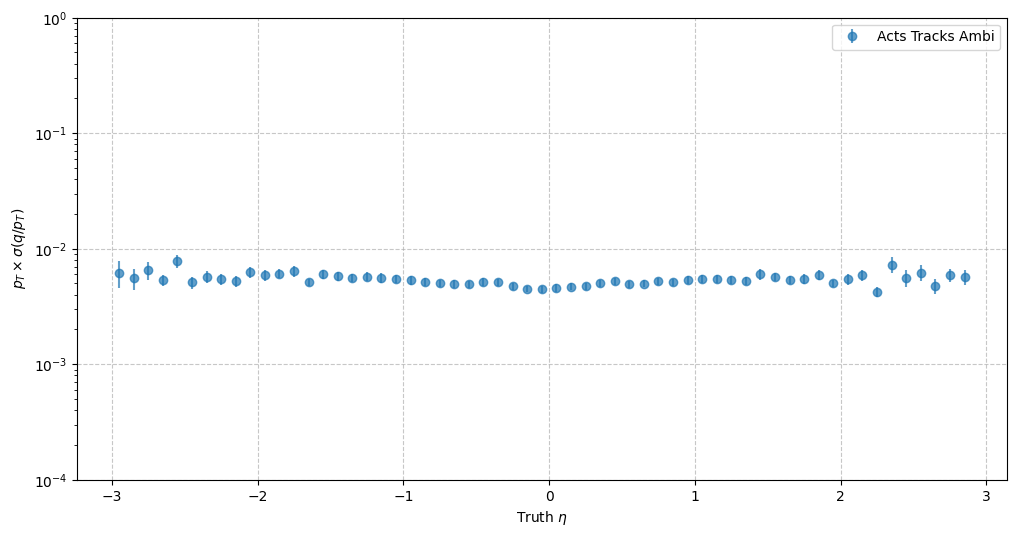

In [37]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name, model_info in models.items():
    # Get the data
    # data = model_data[model_name]
    # Plot the data
    # plt.errorbar(
    #     bin_centers,
    #     bin_means,
    #     yerr=bin_stds,
    #     label=model_name,
    #     alpha=0.7,
    #     fmt="o",
    # )
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label="Acts Tracks Ambi",
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
plt.ylim(1e-4, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta_tracks_ambi.png", format="png", bbox_inches="tight"
)
plt.show()

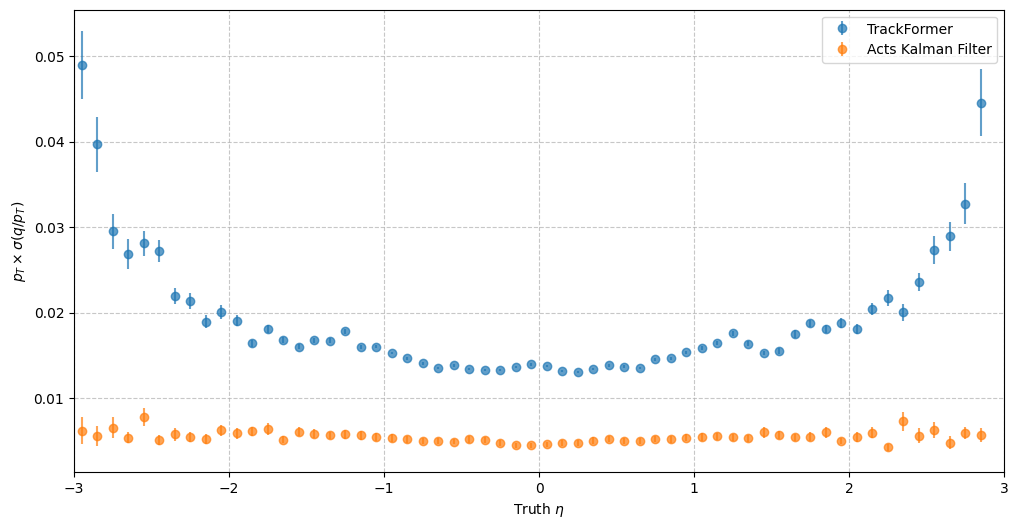

In [38]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name, model_data in model_data_bins.items():
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]

    if model_name == "MSE":
        model_name = "TrackFormer"
    if model_name == "ACTS_Tracks":
        model_name = "Acts Kalman Filter"
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(1e-4, 1)
# plt.ylim(1e-4, 5e-2)
plt.xlim(-3, 3)
# plt.xlim(-1, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta_comparison_no_log.png", format="png", bbox_inches="tight"
)
plt.show()

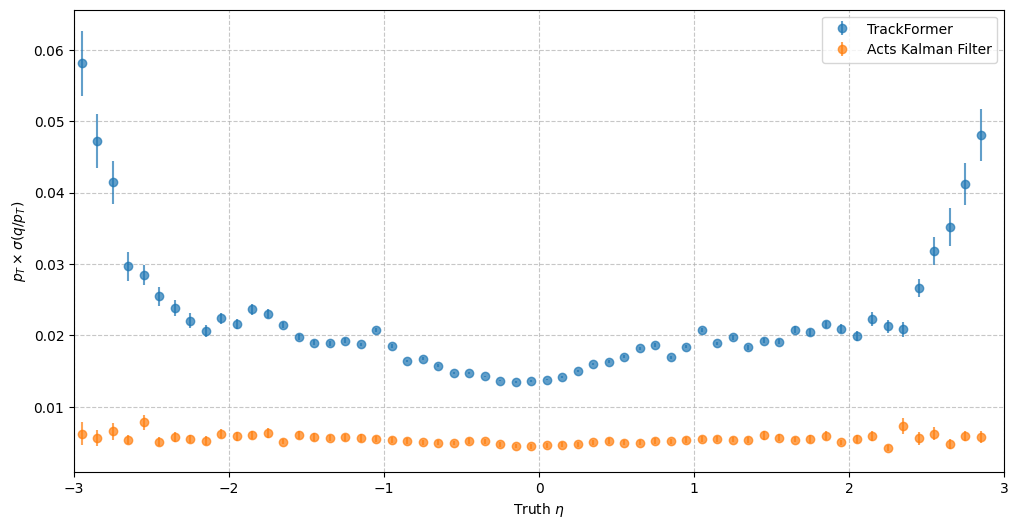

In [ ]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name, model_data in model_data_bins.items():
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]

    if model_name == "MSE":
        model_name = "TrackFormer"
    if model_name == "ACTS_Tracks":
        model_name = "Acts Kalman Filter"
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(1e-4, 1)
# plt.ylim(1e-4, 5e-2)
plt.xlim(-3, 3)
# plt.xlim(-1, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta_comparison_no_log.png", format="png", bbox_inches="tight"
)
plt.show()

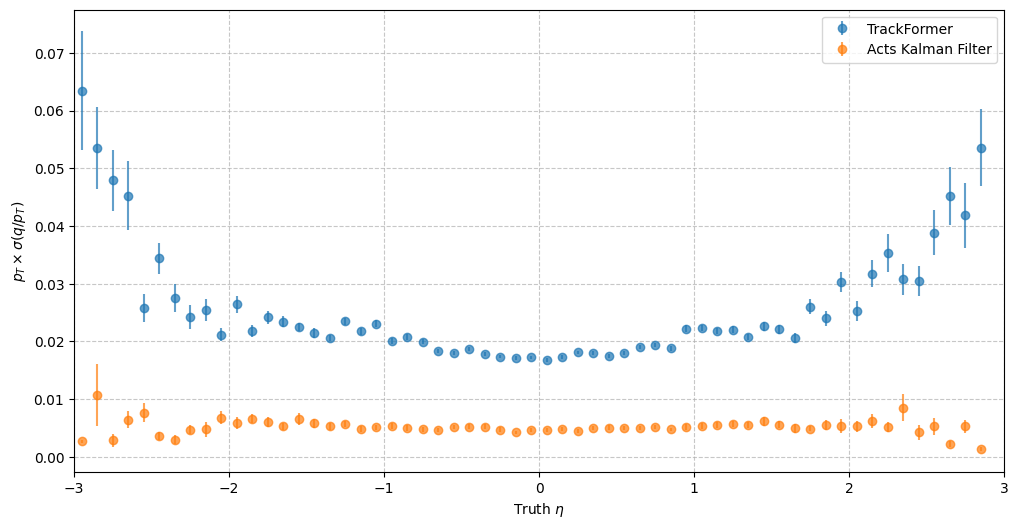

In [ ]:
# Make the plot
plt.figure(figsize=(12, 6))
# plt.suptitle("Relative Error vs peta", fontsize=16)
# Plot the data
for model_name, model_data in model_data_bins.items():
    # Convert to numpy arrays
    model_data = np.array(model_data)
    # Get the means and stds
    bin_means = model_data[:, 0]
    bin_stds = model_data[:, 1]
    bin_counts = model_data[:, 2]
    bin_pi_true_values = model_data[:, 3]
    bin_means_err = model_data[:, 4]
    bin_stds_err = model_data[:, 5]

    if model_name == "MSE":
        model_name = "TrackFormer"
    if model_name == "ACTS_Tracks":
        model_name = "Acts Kalman Filter"
    
    plt.errorbar(
        bin_centers,
        bin_stds*bin_pi_true_values,
        # bin_means,
        yerr=bin_stds_err*bin_pi_true_values,
        label=model_name,
        alpha=0.7,
        fmt="o",
    )

plt.legend()
# plt.title("Relative Error vs peta")
# plt.yscale("log")
plt.xscale("linear")
plt.xlabel(r"Truth $\eta$")
plt.ylabel(r"$p_T \times \sigma(q/p_T)$")
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim(1e-4, 1)
# plt.ylim(1e-4, 5e-2)
plt.xlim(-3, 3)
# plt.xlim(-1, 1)
plt.savefig(
    output_dir / "relative_error_vs_peta_comparison_no_log.png", format="png", bbox_inches="tight"
)
plt.show()

In [51]:
# Full dataset test: 17 min 09 s (23 804 batches)
# Full dataset eta 4 test: 52 min 34 s (85 627 batches)
# Full dataset eta 3 test: > 30 min 34 s (> 21 000 batches)
p_true_list = []
n_hits_list = []
input_list = []

bad_tracks_q = []
bad_tracks_mse = []
bad_tracks_mse_pT = []
bad_tracks_mse_pT_sign = []
worst_tracks_mse_pT = []

abs_relative_error_model_max = {model: 0 for model in models}
abs_relative_error_model_max_pT = {model: 0 for model in models}

for model in models:
    models[model]["data_list"] = []

with torch.no_grad():
    for processed_event, tracks in zip(all_events_processed, all_events_tracks_list):
        for i, (input, mask, target) in enumerate(tqdm(processed_event)):
            # if dataset_name == "Acts_muons" and i > 7000:
            #     break

            # Transformers
            p_true = target
            p_true_list.extend(p_true.tolist())
            # n_hits_list.extend(mask.sum(dim=1).tolist())
            input_list.extend(input.tolist())

            for model in models:
                ml_model = models[model]["model"]
                # Resize input to match the model's expected input shape
                if input.dim() == 2:
                    input = input.unsqueeze(0)
                if mask.dim() == 1:
                    mask = mask.unsqueeze(0)
                p_pred_model = ml_model(input, mask=mask)
                models[model]["data_list"].extend(p_pred_model.tolist())

                # error_model = p_pred_model - p_true
                # relative_error_model = error_model / p_true
                # abs_relative_error_model = np.abs(relative_error_model)

                # print(ml_model.metric(p_pred_model, p_true))

                # if model != "MSE":
                #     continue

                # if (abs_relative_error_model > 10).any():
                #     mask_ = (abs_relative_error_model > 10).any(axis=1)
                #     selected = input[mask_][0]

                #     relative_error_values = relative_error_model[mask_].tolist()
                #     p_values = p_true[mask_].tolist()
                #     bad_tracks_mse.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

                # # Do only for pT
                # # if config["output_variables"][0] != "pT":
                # #     continue

                # abs_relative_error_model_max[model] = max(abs_relative_error_model[:, 0].max(), abs_relative_error_model_max[model])

                # if abs_relative_error_model[:, 0].max() == abs_relative_error_model_max[model]:
                #     mask_ = abs_relative_error_model[:, 0] == abs_relative_error_model_max[model]
                #     selected = input[mask_][0]

                #     relative_error_values = relative_error_model[mask_].tolist()
                #     p_values = p_true[mask_].tolist()
                #     worst_tracks_mse_pT.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

                # if abs_relative_error_model[:, 0].max() > 1:
                #     mask_ = abs_relative_error_model[:, 0] > 1
                #     selected = input[mask_][0]

                #     relative_error_values = relative_error_model[mask_].tolist()
                #     p_values = p_true[mask_].tolist()
                #     bad_tracks_mse_pT.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))

                # if (np.sign(p_pred_model[:, 0]) != np.sign(p_true[:, 0])).any():
                #     mask_ = np.sign(p_pred_model[:, 0]) != np.sign(p_true[:, 0])
                #     selected = input[mask_][0]

                #     relative_error_values = relative_error_model[mask_].tolist()
                #     p_values = p_true[mask_].tolist()
                #     bad_tracks_mse_pT_sign.extend(((error, p), selected) for error, p in zip(relative_error_values, p_values))
        print(f"Processed event with {i+1} inputs and {len(tracks)} tracks.")
        print(tracks.columns)
        print(tracks)
        # print(f"Processed event with {len(processed_event)} inputs and {len(tracks)} tracks.")

0it [00:00, ?it/s]

Processed event with 1319 inputs and 1916 tracks.
Index(['track_id', 'seed_id', 'nStates', 'nMajorityHits', 'nMeasurements',
       'nOutliers', 'nHoles', 'nSharedHits', 'chi2', 'ndf', 'chi2/ndf', 'pT',
       'eta', 'phi', 'truthMatchProbability', 'good/duplicate/fake', 'Hits_ID',
       'particle_id', 'particle_type', 'process', 'vx_truth', 'vy_truth',
       'vz_truth', 'vt_truth', 'px_truth', 'py_truth', 'pz_truth', 'm_truth',
       'q_truth', 'n_hits_truth'],
      dtype='object')
      track_id  seed_id  nStates  nMajorityHits  nMeasurements  nOutliers  \
0         1915    40683       29             17             17          0   
1         1914    40658       26             14             14          0   
2         1913    40649       25             13             13          0   
3         1912    40644       24             12             12          0   
4         1911    40640       28             14             14          0   
...        ...      ...      ...            ..

0it [00:00, ?it/s]

Processed event with 1319 inputs and 1907 tracks.
Index(['track_id', 'seed_id', 'nStates', 'nMajorityHits', 'nMeasurements',
       'nOutliers', 'nHoles', 'nSharedHits', 'chi2', 'ndf', 'chi2/ndf', 'pT',
       'eta', 'phi', 'truthMatchProbability', 'good/duplicate/fake', 'Hits_ID',
       'particle_id', 'particle_type', 'process', 'vx_truth', 'vy_truth',
       'vz_truth', 'vt_truth', 'px_truth', 'py_truth', 'pz_truth', 'm_truth',
       'q_truth', 'n_hits_truth'],
      dtype='object')
      track_id  seed_id  nStates  nMajorityHits  nMeasurements  nOutliers  \
0         1906    41478       26             13             14          0   
1         1905    41321       28             16             16          0   
2         1904    41184       26             14             14          0   
3         1903    41175       27             14             14          0   
4         1902    41162       25             13             13          0   
...        ...      ...      ...            ..

0it [00:00, ?it/s]

...

Processed event with 1893 inputs and 1895 tracks.
Index(['track_id', 'seed_id', 'nStates', 'nMajorityHits', 'nMeasurements',
       'nOutliers', 'nHoles', 'nSharedHits', 'chi2', 'ndf', 'chi2/ndf', 'pT',
       'eta', 'phi', 'truthMatchProbability', 'good/duplicate/fake', 'Hits_ID',
       'particle_id', 'particle_type', 'process', 'vx_truth', 'vy_truth',
       'vz_truth', 'vt_truth', 'px_truth', 'py_truth', 'pz_truth', 'm_truth',
       'q_truth', 'n_hits_truth'],
      dtype='object')
      track_id  seed_id  nStates  nMajorityHits  nMeasurements  nOutliers  \
0         1894    41552       24             13             13          0   
1         1893    41542       25             14             14          0   
2         1892    41456       28             15             15          0   
3         1891    41325       27             15             15          0   
4         1890    41301       26             14             14          0   
...        ...      ...      ...            ..

0it [00:00, ?it/s]

[12:29:55] Warning: 2115 particles do not have corresponding hits.                               ]8;id=305199;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=916362;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#721\721]8;;\

           Particle ids: [   4503599660924928    4503599677702144    9007199271518208 ...        ]8;id=11673;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py\datamodules.py]8;;\:]8;id=190876;file:///home/couthures/Bureau/TrackParameters/TrackFormer/src/datasets/datamodules.py#725\725]8;;\
            4485585228928122880 4494592428149309440 4503599627387273216]                                           

KeyboardInterrupt: 

(152025,)
(224032,)


ValueError: x and y must be the same size

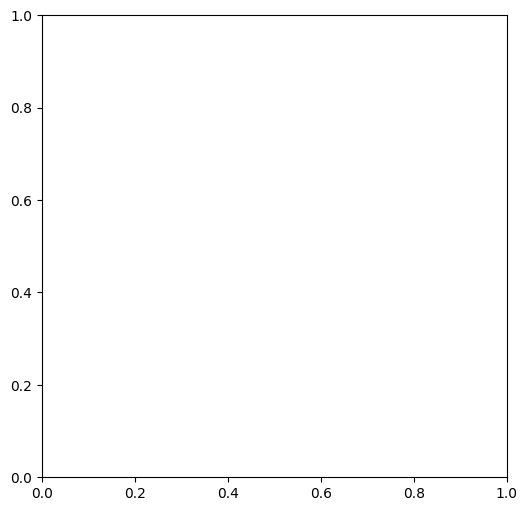

In [40]:
# Scatter plot of q/pT model vs q/pT algorithm
plt.figure(figsize=(6, 6))
# Acts Kalman Filter error
tracks_error = 1/all_events_tracks["pT"] - 1/all_events_tracks["pT_truth"]
# Model error
pi_true_values = all_targets[0].numpy()
model_data = {}
for model_name, model_info in models.items():
    # Compute the relative error: (prediction - true)/true
    pi_pred_values = np.array(model_info["data_list"])[:, 0]
    # if var == "p_T":
    #     pi_pred_values = var_to_pT(
    #         values=pi_pred_values,
    #         from_var=config["output_variables"][var_index],
    #     )
    pi_pred_values = pi_pred_values[:len(pi_true_values)]
    errors = pi_pred_values - pi_true_values
    relative_errors = errors / pi_true_values

    model_data[model_name] = pi_pred_values
tracks_error_model = model_data["MSE"] - pi_true_values
print(tracks_error.shape)
print(tracks_error_model.shape)
plt.scatter(
    tracks_error,
    tracks_error_model,
    # alpha=0.5,
)
plt.xlabel("Acts Kalman Filter Error (q/pT)")
plt.ylabel("TrackFormer Error (q/pT)")
plt.title("Acts Kalman Filter vs TrackFormer Error (q/pT)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xscale("linear")
plt.yscale("linear")
# plt.xlim(-0.1, 0.1)
# plt.ylim(-0.1, 0.1)
# plt.savefig("acts_vs_trackformer_error.png")
plt.show()